In [1]:
import pandas as pd
from tqdm import tqdm
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import cast
import matplotlib.ticker as ticker
from collections import Counter

import mlflow
from mlflow.entities import Trace, Span, SpanType
from loguru import logger

mlflow.set_tracking_uri("http://100.113.186.28:5000")
mlflow.set_experiment("vds-agent-validation")


<Experiment: artifact_location='mlflow-artifacts:/6', creation_time=1775830300571, experiment_id='6', last_update_time=1775830300571, lifecycle_stage='active', name='vds-agent-validation', tags={'mlflow.latestOnlineScoring.trace.checkpoint': '{"timestamp_ms": '
                                                '1776505179594, "trace_id": '
                                                'null}'}, workspace='default'>

# Prepare traces, and data for plotting

In [2]:
traces = cast(list, mlflow.search_traces(
        locations=['6'],
        filter_string="trace.text LIKE '%I want%'",
        return_type='list'
))
print(f"Loaded {len(traces)} traces")

Loaded 70 traces


In [3]:
len(traces)

70

In [7]:
model2cost = {
    'qwen/qwen3.6-plus': {
        'input_cost': {"<=256000": 0.325, ">256000": 1.30},
        "output_cost": {"<=256000": 1.95, ">256000": 3.90}
    },
    "z-ai/glm-5.1": {
        "input_cost": 0.95,
        "output_cost": 3.15
    },
    "qwen/qwen3.5-flash-02-23": {
        "input_cost": 0.065,
        "output_cost": 0.26
    },
    "google/gemini-3.1-flash-lite-preview": {
        "input_cost": 0.25,
        "output_cost": 1.50
    },
    "qwen/qwen3.5-27b": {
        "input_cost": 0.195,
        "output_cost": 1.56
    },
    "qwen/qwen3.5-plus-02-15": {
        'input_cost': {"<=256000": 0.26, ">256000": 1.56},
        "output_cost": {"<=256000": 0.325, ">256000": 1.95}
    }
}

def get_cost(model_key, input_tokens, output_tokens):
    """Calculates cost based on model pricing rules (per 1M tokens)."""
    if model_key not in model2cost:
        return 0.0
    pricing = model2cost[model_key]
    if isinstance(pricing['input_cost'], dict):
        tier = "<=256000" if input_tokens <= 256000 else ">256000"
        i_rate = pricing['input_cost'][tier]
        o_rate = pricing['output_cost'][tier] #type:ignore
    else:
        i_rate = pricing['input_cost']
        o_rate = pricing['output_cost']
    return (input_tokens * i_rate / 1_000_000) + (output_tokens * o_rate / 1_000_000)

In [8]:
# all span types
span_types = set()
for trace in traces:
    for span in trace.data.spans:
        span_types.add(span.span_type)

print(span_types)

{'LLM', 'AGENT', 'TOOL'}


In [9]:
span_agent_records = []

for trace in traces:
    for span in trace.data.spans:
        if span.span_type == SpanType.AGENT:
            span_data = {
                "trace_id": span.trace_id,
                "span_id": span.span_id,
                "status": span.status.status_code.value,
                "latency_sec": (span.end_time_ns - span.start_time_ns) / 1e9,
                "model_name": span.attributes['graph.node.name'],   
            }
            span_agent_records.append(span_data)


In [10]:
# setup dataframe
span_llm_records = []


for trace in traces:
    trace_id = trace.info.trace_id 
    for span in trace.data.spans:
        if span.span_type == SpanType.LLM or 'llm' in span.name.lower():
            attrs = span.attributes or {}
            usage = attrs.get('mlflow.chat.tokenUsage', {})
            model_key = attrs['mlflow.llm.model']
            if 'input_tokens' not in usage or 'output_tokens' not in usage:
                continue
            
            input_tokens = usage['input_tokens']
            output_tokens = usage['output_tokens']
            
            span_llm_records.append({
                'trace_id': trace_id,
                'model_id': attrs.get('mlflow.llm.model', ''),
                'input_tokens': input_tokens,
                'output_tokens': output_tokens,
                'cost': get_cost(model_key, input_tokens, output_tokens)
            })

    

In [11]:
from tqdm import tqdm

span_tool_records = []
span_worker_agent_records = []

for trace in tqdm(traces, desc="Extracting tool calls"):
    trace_id = trace.info.trace_id
    
    for span in trace.data.spans:
        if span.span_type != SpanType.TOOL:
            continue
            
        attrs = span.attributes or {}
        tool_name = attrs.get('tool.name')
        
        if tool_name in ['get_member_information', 'get_available_worker_tools', 'get_available_models']:
            continue
            

        if tool_name != 'spawn_and_run_worker':
            tool_record = {
                'trace_id': trace_id,
                'tool_trace_id': attrs.get('mlflow.traceRequestId'),
                'tool_name': tool_name,
                'status': span.status.status_code.value if span.status else "UNKNOWN",
                'latency_ms': (span.end_time_ns - span.start_time_ns) / 1e6, 
                'input': attrs.get('tool.parameters'),
            }
            span_tool_records.append(tool_record)

        if tool_name == 'spawn_and_run_worker':
            tool_args = attrs.get('tool.parameters', {})
            
            worker_agent_name = tool_args.get('agent_name', 'unknown_worker')
            worker_agent_model = tool_args.get('model_name', 'unknown_model')
            worker_tools_list = tool_args.get('tool_names', [])
            
            if isinstance(worker_tools_list, str):
                worker_tools_list = [worker_tools_list]
                
            for worker_tool in worker_tools_list:
                worker_record = {
                    'parent_trace_id': trace_id,
                    'tool_trace_id': attrs.get('mlflow.traceRequestId'),
                    'worker_agent_name': worker_agent_name,
                    'worker_model': worker_agent_model,
                    'tool_assigned_to_worker': worker_tool
                }
                span_worker_agent_records.append(worker_record)

Extracting tool calls: 100%|██████████| 70/70 [00:00<00:00, 664.98it/s]


In [12]:
assessments_data = []
for trace in tqdm(traces, desc="Fetching assessments"):
    trace_id = trace.info.trace_id
    try:
        assessments = trace.search_assessments(all=True)
        if assessments:
            for assessment in assessments:
                feedback_value = assessment.feedback.value if assessment.feedback else None
                assessments_data.append({
                    'trace_id': trace_id,
                    'assessment_name': assessment.name,
                    'assessment_id': assessment.assessment_id,
                    'feedback_value': feedback_value,
                })
    except Exception as e:
        pass

Fetching assessments: 100%|██████████| 70/70 [00:00<00:00, 253980.35it/s]


In [13]:
df_llm = pd.DataFrame(span_llm_records)
df_agent = pd.DataFrame(span_agent_records)
df_tool = pd.DataFrame(span_tool_records)
df_worker_tool = pd.DataFrame(span_worker_agent_records)
df_assessments = pd.DataFrame(assessments_data)

In [14]:
df_llm.head()

,trace_id,model_id,input_tokens,output_tokens,cost
0,tr-2b35f46018dd98383e97c207cea057a2,qwen/qwen3.6-plus,1685,225,0.000986
1,tr-2b35f46018dd98383e97c207cea057a2,qwen/qwen3.6-plus,1809,386,0.001341
2,tr-2b35f46018dd98383e97c207cea057a2,z-ai/glm-5.1,1779,87,0.001964
3,tr-2b35f46018dd98383e97c207cea057a2,z-ai/glm-5.1,3078,23,0.002997
4,tr-2b35f46018dd98383e97c207cea057a2,z-ai/glm-5.1,3812,907,0.006478


In [15]:
df_agent.head()

,trace_id,span_id,status,latency_sec,model_name
0,tr-2b35f46018dd98383e97c207cea057a2,3d74734432ead5c6,OK,641.973963,VideoDeepSearch
1,tr-2b35f46018dd98383e97c207cea057a2,f637e9872e18501e,OK,583.251590,Orchestrator
2,tr-2b35f46018dd98383e97c207cea057a2,63aa4b46c47d2c18,OK,94.785165,video_discovery_worker
3,tr-2b35f46018dd98383e97c207cea057a2,906342c6e5ff00ab,OK,172.198774,visual_indicators_worker
4,tr-2b35f46018dd98383e97c207cea057a2,516f62ce37e553dd,OK,119.268810,audio_alerts_worker


In [16]:
df_tool

,trace_id,tool_trace_id,tool_name,status,latency_ms,input
0,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,delegate_task_to_member,OK,583252.293149,"{'member_id': 'orchestrator', 'task': 'Search ..."
1,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,triple_hybrid_search,OK,257.828131,{'query': 'Milton tornadoes Florida special re...
2,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,search_bm25,OK,36.695384,"{'query': 'Milton tornadoes Florida', 'top_k':..."
3,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,search_entities_semantic,OK,58.528472,{'query': 'Hurricane Milton Florida tornadoes'...
4,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,get_segments_from_event_query_mmbert,OK,44.462151,{'event_query': 'tornadoes in Florida ahead of...
...,...,...,...,...,...,...
2178,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,OK,1490.527303,"{'video_id': '69d1fa20846a50051062bee1', 'segm..."
2179,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,OK,1558.965981,"{'video_id': '69d215d4d7ce9f0cd06950d9', 'segm..."
2180,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,OK,1040.204481,"{'video_id': '69d20b75846a50051062beea', 'segm..."
2181,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,OK,1280.612473,"{'video_id': '69d20b75846a50051062beea', 'segm..."


In [17]:
df_worker_tool

,parent_trace_id,tool_trace_id,worker_agent_name,worker_model,tool_assigned_to_worker
0,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,video_discovery_worker,qwen/qwen3.6-plus,kg.triple_hybrid_search
1,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,video_discovery_worker,qwen/qwen3.6-plus,kg.search_bm25
2,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,video_discovery_worker,qwen/qwen3.6-plus,kg.search_entities_semantic
3,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,video_discovery_worker,qwen/qwen3.6-plus,kg.search_events
4,tr-2b35f46018dd98383e97c207cea057a2,tr-2b35f46018dd98383e97c207cea057a2,video_discovery_worker,qwen/qwen3.6-plus,search.get_segments_from_event_query_mmbert
...,...,...,...,...,...
1182,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,deep_dive_safety_grip_worker,qwen/qwen3.6-plus,kg.search_micro_events
1183,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,deep_dive_safety_grip_worker,qwen/qwen3.6-plus,search.get_audio_from_query_hybrid
1184,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,deep_dive_safety_grip_worker,qwen/qwen3.6-plus,search.get_audio_from_query_dense
1185,tr-8fafb04c98bd4e967d79ff101ace7c43,tr-8fafb04c98bd4e967d79ff101ace7c43,deep_dive_safety_grip_worker,qwen/qwen3.6-plus,utility.get_related_asr_from_segment


In [18]:
df_assessments

,trace_id,assessment_name,assessment_id,feedback_value
0,tr-2b35f46018dd98383e97c207cea057a2,expected_response,a-306746525f034e379e1f5a666da231fc,None
1,tr-2b35f46018dd98383e97c207cea057a2,HumanJudgement,a-7ab095d5421d4b46a71c1c50bd45adfe,0.9
2,tr-2b35f46018dd98383e97c207cea057a2,VideoRecall,a-d568fe440793480da05d6cc20b16211b,0.33
3,tr-2b35f46018dd98383e97c207cea057a2,expected_response,a-fb89e0a10c934d99b1084e6c6c8fd5c0,None
4,tr-2b35f46018dd98383e97c207cea057a2,AnswerCorrectnessPoint,a-3e857746c1c34d85821704dd4c83a2cb,1.0
...,...,...,...,...
347,tr-8fafb04c98bd4e967d79ff101ace7c43,HumanJudgement,a-4fe5f398dc184deea9b25a0b428424ee,0.82
348,tr-8fafb04c98bd4e967d79ff101ace7c43,VideoRecall,a-d245a9bbd4ec488dacbdb3f6bb47dc46,1.0
349,tr-8fafb04c98bd4e967d79ff101ace7c43,AnswerCorrectnessPoint,a-847e6d7ad0de42e18d69d0ce42a76dfc,0.6
350,tr-8fafb04c98bd4e967d79ff101ace7c43,Tool Call Correctness,a-16afe3cd28434f388e8b8dc5ee2b03ba,yes


# Analysis

In [19]:
df_llm.describe()

,input_tokens,output_tokens,cost
count,2907.000000,2907.000000,2907.000000
mean,25069.501548,583.019264,0.009497
std,18936.636567,1232.645235,0.009260
min,1065.000000,6.000000,0.000171
25%,9337.500000,103.000000,0.002934
50%,22754.000000,153.000000,0.007344
75%,36193.500000,376.500000,0.012437
max,127438.000000,12579.000000,0.086075


/tmp/ipykernel_3115219/3274399760.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


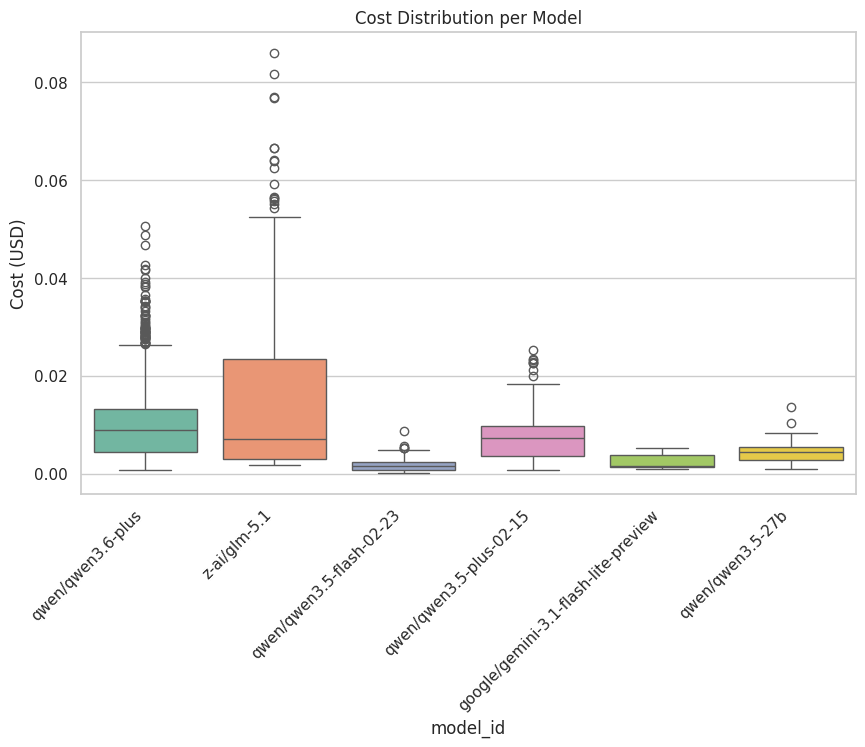

In [20]:
# cost distribution per model
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_llm,
    x='model_id',
    y='cost',
    palette="Set2"
)
plt.xticks(rotation=45, ha='right')  
plt.title('Cost Distribution per Model')
plt.ylabel('Cost (USD)')
plt.show()

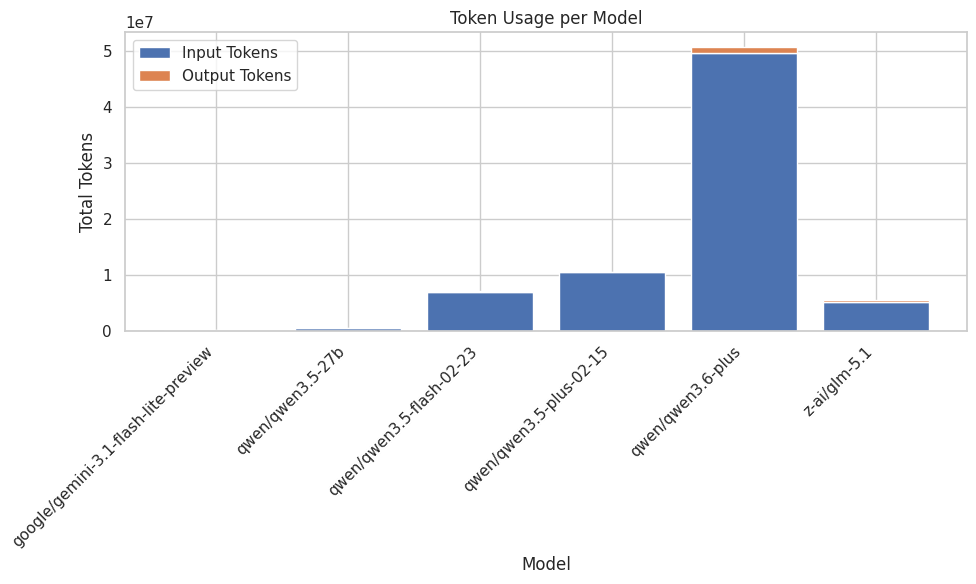

In [21]:
# token usage per model 
df_llm_agg = df_llm.groupby('model_id')[['input_tokens', 'output_tokens']].sum().reset_index()
plt.figure(figsize=(10, 6))

plt.bar(df_llm_agg['model_id'], df_llm_agg['input_tokens'], label='Input Tokens')
plt.bar(
    df_llm_agg['model_id'],
    df_llm_agg['output_tokens'],
    bottom=df_llm_agg['input_tokens'], 
    label='Output Tokens'
)

plt.title('Token Usage per Model')
plt.xlabel('Model')
plt.ylabel('Total Tokens')
plt.xticks(rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

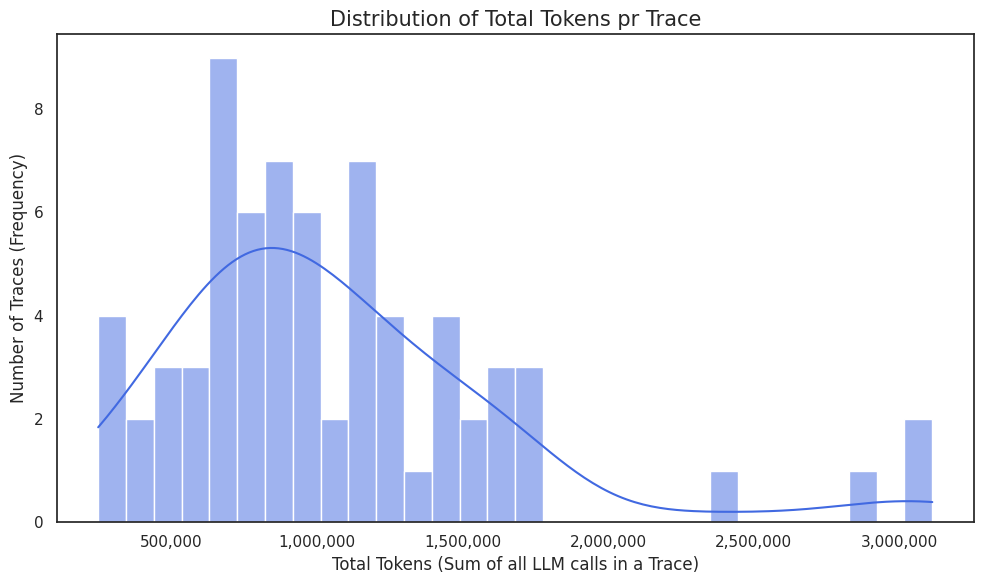

In [22]:
# token distribution per trace

trace_token_stats = df_llm.groupby('trace_id').agg({
    'input_tokens': 'sum',
    'output_tokens': 'sum'
}).reset_index()
trace_token_stats['total_tokens']  = trace_token_stats['input_tokens'] + trace_token_stats['output_tokens']
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))
sns.histplot(
    trace_token_stats['total_tokens'], 
    kde=True, 
    color='royalblue', 
    bins=30,
    edgecolor='white'
)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.title('Distribution of Total Tokens pr Trace', fontsize=15)
plt.xlabel('Total Tokens (Sum of all LLM calls in a Trace)', fontsize=12)
plt.ylabel('Number of Traces (Frequency)', fontsize=12)

plt.tight_layout()
plt.show()

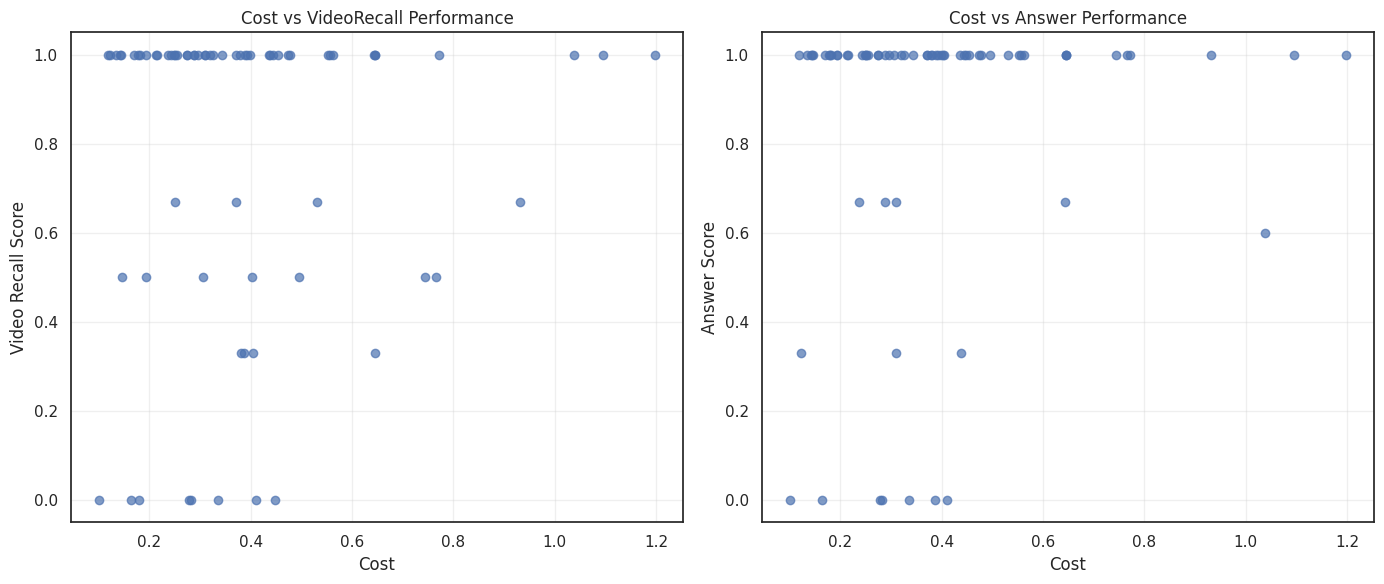

In [23]:
# cost vs performance scatter

trace_cost = df_llm.groupby('trace_id')['cost'].sum().reset_index()

video_recall_score = df_assessments[df_assessments['assessment_name'] == 'VideoRecall']
answer_score = df_assessments[df_assessments['assessment_name'] == 'AnswerCorrectnessPoint']

cost_vs_video_recall_score = trace_cost.merge(video_recall_score, left_on='trace_id', right_on='trace_id')
cost_vs_answer_score = trace_cost.merge(answer_score, left_on='trace_id', right_on='trace_id')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cost vs Video Recall
axes[0].scatter(
    cost_vs_video_recall_score['cost'],
    cost_vs_video_recall_score['feedback_value'],
    alpha=0.7
)
axes[0].set_xlabel('Cost')
axes[0].set_ylabel('Video Recall Score')
axes[0].set_title('Cost vs VideoRecall Performance')
axes[0].grid(True, alpha=0.3)

# Plot 2: Cost vs Answer Score
axes[1].scatter(
    cost_vs_answer_score['cost'],
    cost_vs_answer_score['feedback_value'],
    alpha=0.7
)
axes[1].set_xlabel('Cost')
axes[1].set_ylabel('Answer Score')
axes[1].set_title('Cost vs Answer Performance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 

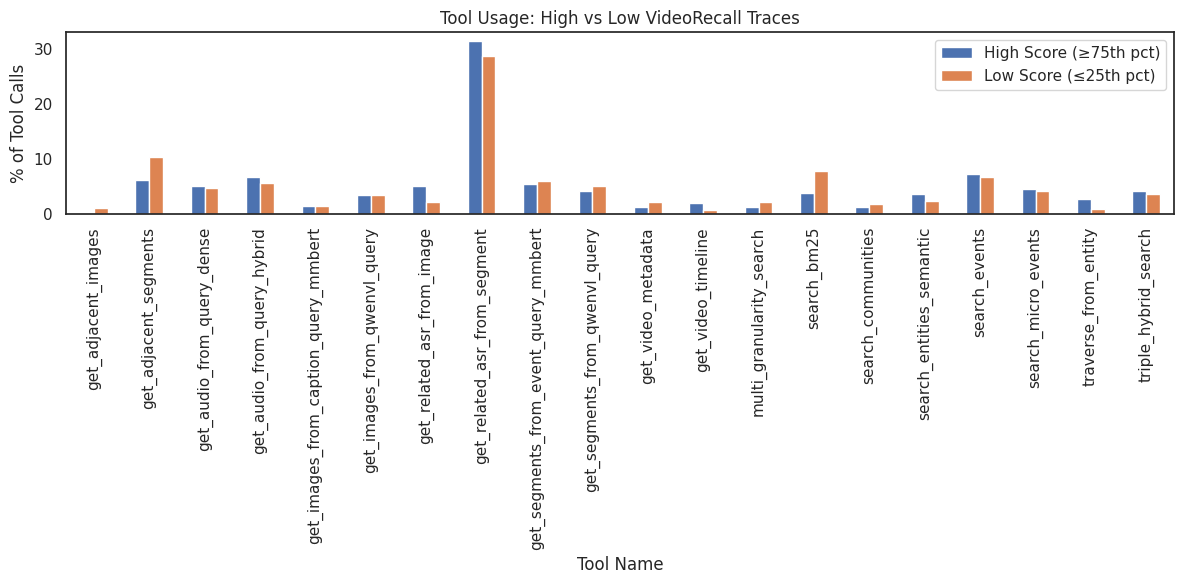

In [24]:
high_recall_scores = video_recall_score[video_recall_score['feedback_value'] >= video_recall_score['feedback_value'].quantile(0.75)]['trace_id']
low_recall_scores = video_recall_score[video_recall_score['feedback_value'] <= video_recall_score['feedback_value'].quantile(0.25)]['trace_id']

eliminate_tool_name = [
    'delegate_task_to_member',
    'save_session_context'
]

high_tool_names = df_tool[df_tool['trace_id'].isin(high_recall_scores) & ~df_tool['tool_name'].isin(eliminate_tool_name)]['tool_name'].value_counts()
low_tool_names = df_tool[df_tool['trace_id'].isin(low_recall_scores) & ~df_tool['tool_name'].isin(eliminate_tool_name)]['tool_name'].value_counts()
high_pct = high_tool_names / high_tool_names.sum() * 100                                                                                                                              
low_pct = low_tool_names / low_tool_names.sum() * 100     

tool_comparison = pd.DataFrame({
    'High Recall': high_pct,
    'Low Recall': low_pct
}).fillna(0)

tool_comparison.plot(kind='bar', figsize=(12, 6))                                                                                                                                     
plt.title('Tool Usage: High vs Low VideoRecall Traces')                                                                                                                               
plt.ylabel('% of Tool Calls')                                                                                                                                                         
plt.xlabel('Tool Name')                                                                                                                                                               
plt.legend(['High Score (≥75th pct)', 'Low Score (≤25th pct)'])                                                                                                                       
plt.tight_layout()                                                                                                                                                                    
plt.show() 

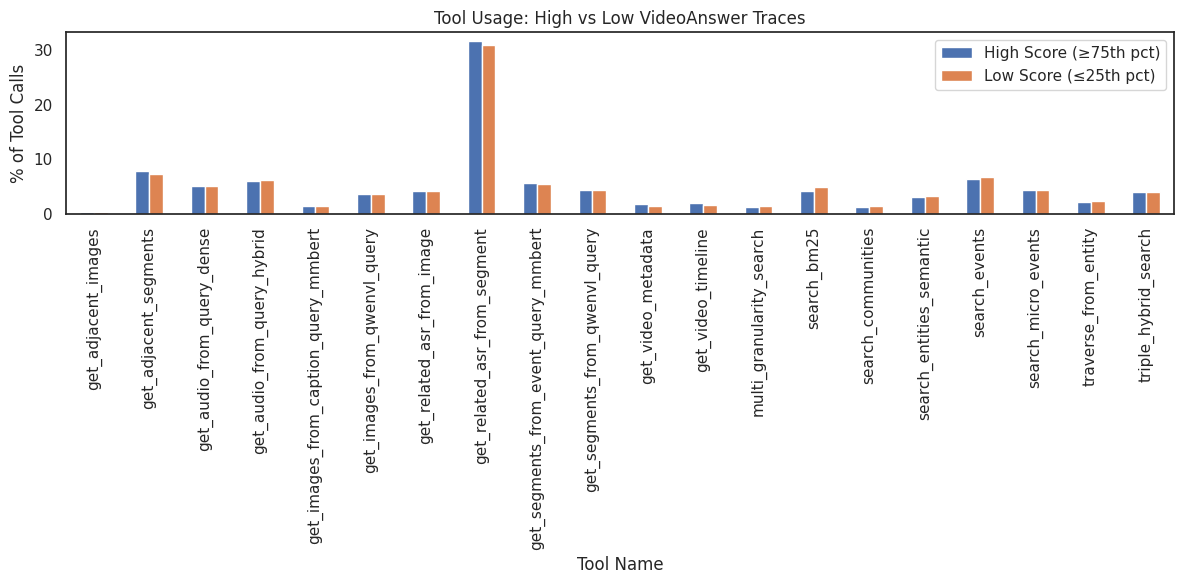

In [25]:
high_answer_scores = answer_score[answer_score['feedback_value'] >= answer_score['feedback_value'].quantile(0.75)]['trace_id']
low_answer_scores = answer_score[answer_score['feedback_value'] <= answer_score['feedback_value'].quantile(0.25)]['trace_id']

eliminate_tool_name = [
    'delegate_task_to_member',
    'save_session_context'
]

high_tool_names = df_tool[df_tool['trace_id'].isin(high_answer_scores) & ~df_tool['tool_name'].isin(eliminate_tool_name)]['tool_name'].value_counts()
low_tool_names = df_tool[df_tool['trace_id'].isin(low_answer_scores) & ~df_tool['tool_name'].isin(eliminate_tool_name)]['tool_name'].value_counts()
high_pct = high_tool_names / high_tool_names.sum() * 100                                                                                                                              
low_pct = low_tool_names / low_tool_names.sum() * 100     

tool_comparison = pd.DataFrame({
    'High Answer': high_pct,
    'Low Answer': low_pct
}).fillna(0)

tool_comparison.plot(kind='bar', figsize=(12, 6))                                                                                                                                     
plt.title('Tool Usage: High vs Low VideoAnswer Traces')                                                                                                                               
plt.ylabel('% of Tool Calls')                                                                                                                                                         
plt.xlabel('Tool Name')                                                                                                                                                               
plt.legend(['High Score (≥75th pct)', 'Low Score (≤25th pct)'])                                                                                                                       
plt.tight_layout()                                                                                                                                                                    
plt.show() 

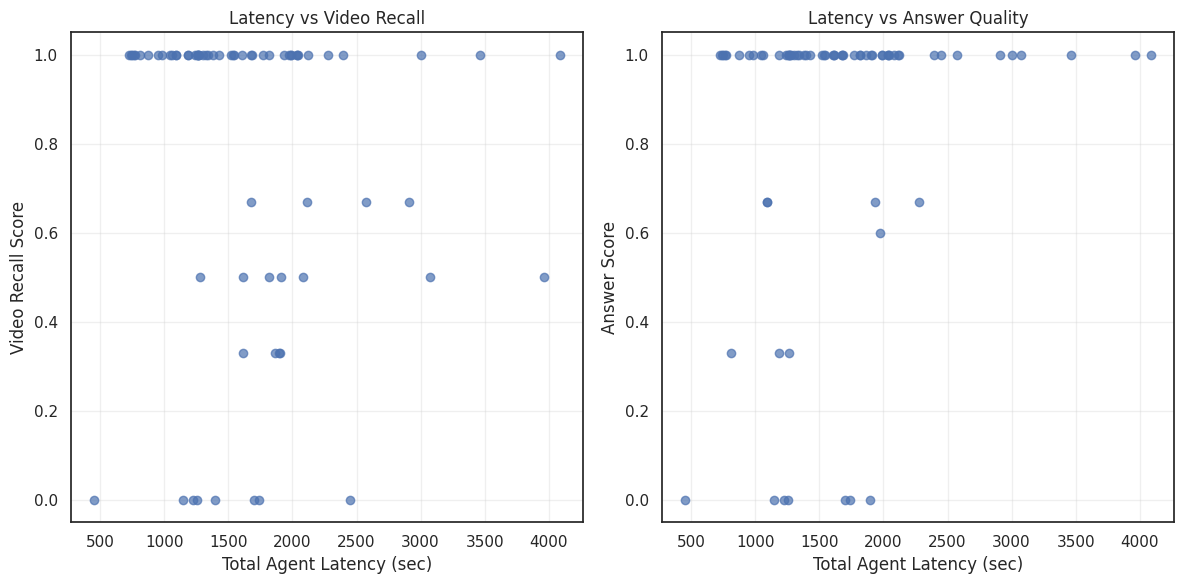

In [26]:
agent_latency = df_agent.groupby('trace_id')['latency_sec'].sum().reset_index()
recall_latency_score = agent_latency.merge(video_recall_score, on='trace_id')
answer_latency_score = agent_latency.merge(answer_score, on='trace_id')

fig, axes = plt.subplots(1,2, figsize=(12, 6))

axes[0].scatter(
    recall_latency_score['latency_sec'],
    recall_latency_score['feedback_value'],
    alpha=0.7
)
axes[0].set_xlabel('Total Agent Latency (sec)')
axes[0].set_ylabel('Video Recall Score')
axes[0].set_title('Latency vs Video Recall')
axes[0].grid(True, alpha=0.3)

# Plot 2: Latency vs Answer Score
axes[1].scatter(
    answer_latency_score['latency_sec'],
    answer_latency_score['feedback_value'],
    alpha=0.7
)
axes[1].set_xlabel('Total Agent Latency (sec)')
axes[1].set_ylabel('Answer Score')
axes[1].set_title('Latency vs Answer Quality')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
unique_worker_name = df_worker_tool['worker_agent_name'].unique()

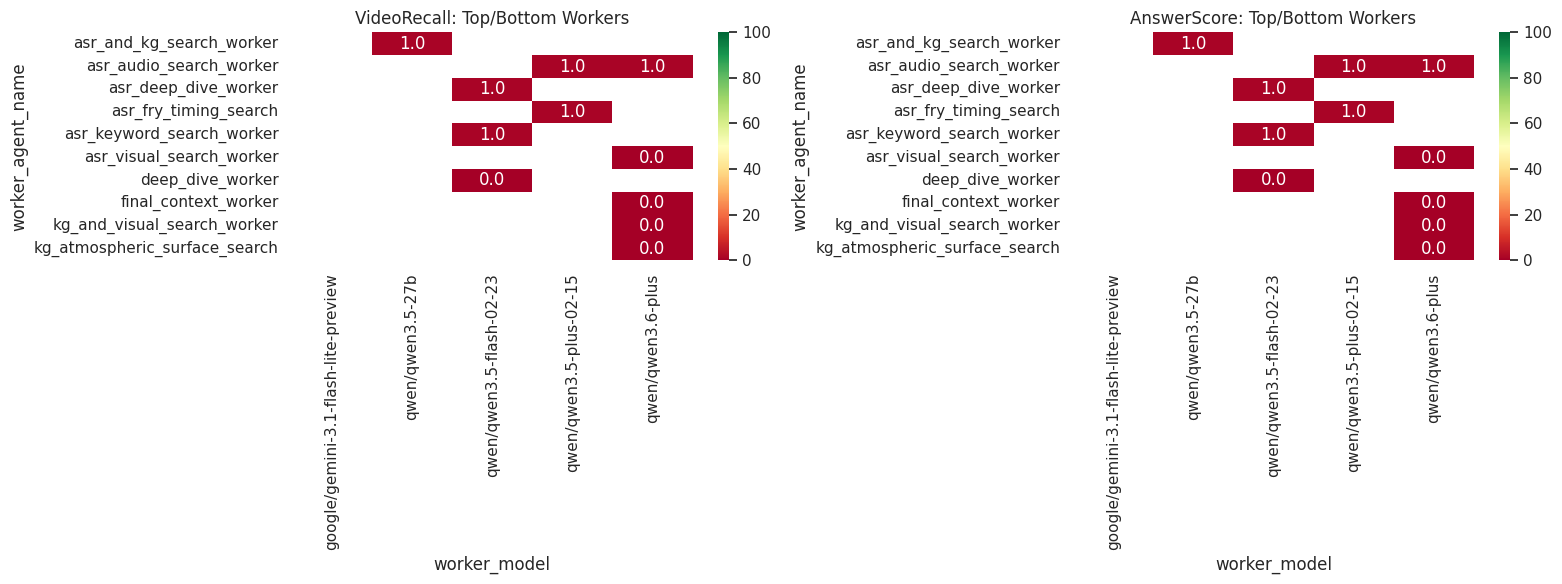

In [28]:

video_recall = df_assessments[df_assessments['assessment_name'] == 'VideoRecall']
answer_correctness = df_assessments[df_assessments['assessment_name'] == 'AnswerCorrectnessPoint']


recall_worker_performance = df_worker_tool.merge(video_recall, left_on='parent_trace_id', right_on='trace_id', how='left')
answer_score_performance = df_worker_tool.merge(answer_correctness, left_on='parent_trace_id', right_on='trace_id', how='left')

recall_worker_performance['feedback_value'] = pd.to_numeric(
    recall_worker_performance['feedback_value'], errors='coerce'
)

answer_score_performance['feedback_value'] = pd.to_numeric(
    answer_score_performance['feedback_value'], errors='coerce'
)

worker_avg_recall = recall_worker_performance.groupby('worker_agent_name')['feedback_value'].mean()
answer_avg_recall = answer_score_performance.groupby('worker_agent_name')['feedback_value'].mean()

recall_pivot_agent_model = recall_worker_performance.pivot_table(
    index='worker_agent_name',
    columns='worker_model',
    values='feedback_value'
) 
answer_pivot_agent_model = answer_score_performance.pivot_table(
    index='worker_agent_name',
    columns='worker_model',
    values='feedback_value'
)

top_recall = worker_avg_recall.nlargest(5).index                                                                                                                                       
bottom_recall = worker_avg_recall.nsmallest(5).index  

selected = list(top_recall) + list(bottom_recall)
recall_filtered = recall_pivot_agent_model.loc[selected]                                                                                                                              
answer_filtered = answer_pivot_agent_model.loc[selected]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))                                                                                                                                       
                                                                                                                                                                                    
sns.heatmap(recall_filtered, annot=True, cmap='RdYlGn', fmt='.1f', ax=axes[0], vmin=0, vmax=100)                                                                                      
axes[0].set_title('VideoRecall: Top/Bottom Workers')                                                                                                                                  
                                                                                                                                                                                    
sns.heatmap(answer_filtered, annot=True, cmap='RdYlGn', fmt='.1f', ax=axes[1], vmin=0, vmax=100)                                                                                      
axes[1].set_title('AnswerScore: Top/Bottom Workers')                                                                                                                                  
                                                                                                                                                                                    
plt.tight_layout()
plt.show()



/tmp/ipykernel_3115219/1058836568.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


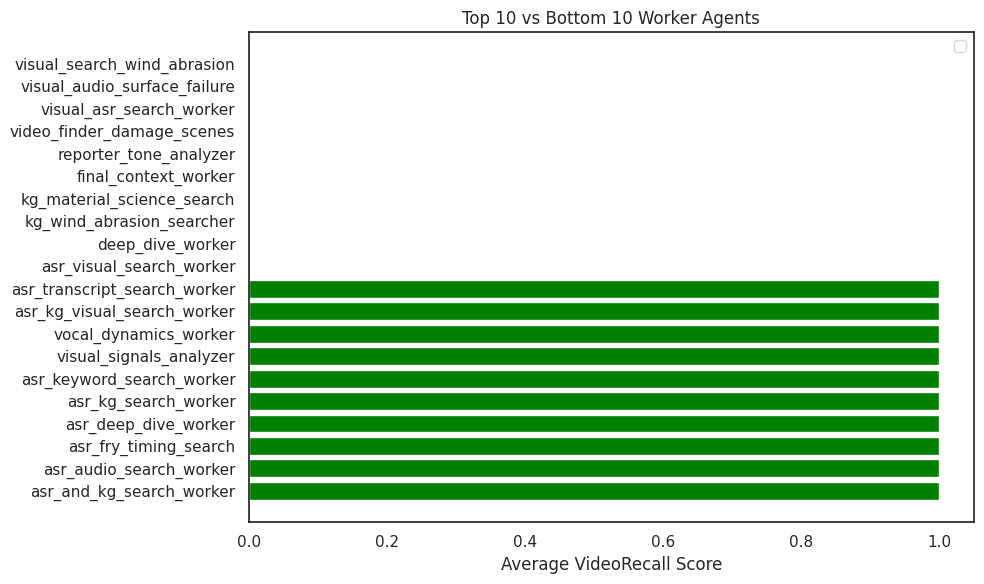

In [29]:
worker_avg_recall_sorted = worker_avg_recall.sort_values(ascending=False)

top_5 = worker_avg_recall_sorted.head(10)                                                                                                                                              
bottom_5 = worker_avg_recall_sorted.tail(10)                                                                                                                                           
                                                                                                                                                                                    
comparison_df = pd.DataFrame({                                                                                                                                                        
    'Worker': list(top_5.index) + list(bottom_5.index),                                                                                                                               
    'Score': list(top_5.values) + list(bottom_5.values),                                                                                                                              
    'Performance': ['Top'] * 10 + ['Bottom'] * 10
})                                                                                                                                                                                    
                                                                                                                                                                                    
plt.figure(figsize=(10, 6))                                                                                                                                                           
colors = ['green' if p == 'Top' else 'red' for p in comparison_df['Performance']]                                                                                                     
plt.barh(comparison_df['Worker'], comparison_df['Score'], color=colors)                                                                                                               
plt.xlabel('Average VideoRecall Score')                                                                                                                                               
plt.title('Top 10 vs Bottom 10 Worker Agents')                                                                                                                                          
plt.legend()                                                                                                                                                                          
plt.tight_layout()                                                                                                                                                                    
plt.show()  

In [30]:
high_answer_scores = answer_score[answer_score['feedback_value'] >= answer_score['feedback_value'].quantile(0.75)]['trace_id']
low_answer_scores = answer_score[answer_score['feedback_value'] <= answer_score['feedback_value'].quantile(0.25)]['trace_id']

tools_in_high = df_worker_tool[df_worker_tool['parent_trace_id'].isin(high_answer_scores)]['tool_assigned_to_worker']
tools_in_low = df_worker_tool[df_worker_tool['parent_trace_id'].isin(low_answer_scores)]['tool_assigned_to_worker']

high_tool_freq = tools_in_high.value_counts(normalize=True) * 100                                                                                                                     
low_tool_freq = tools_in_low.value_counts(normalize=True) * 100   
tool_quality_freq = pd.DataFrame({                                                                                                                                                    
      'High Score (%)': high_tool_freq,                                                                                                                                                 
      'Low Score (%)': low_tool_freq                                                                                                                                                    
  }).fillna(0)  
tool_quality_freq['quality_ratio'] = tool_quality_freq['High Score (%)'] / tool_quality_freq['Low Score (%)'].replace(0, 0.01)   
tool_quality_freq.sort_values('quality_ratio', ascending=False)

,High Score (%),Low Score (%),quality_ratio
tool_assigned_to_worker,,,
video.get_video_metadata,1.806589,1.600674,1.128643
utility.get_adjacent_images,0.743889,0.673968,1.103746
utility.get_adjacent_segments,7.013815,6.402696,1.095447
video.get_video_timeline,1.381509,1.263690,1.093234
kg.search_micro_events,7.438895,6.992418,1.063852
utility.get_related_asr_from_segment,12.008502,11.710194,1.025474
search.get_images_from_caption_query_mmbert,3.081828,3.032856,1.016147
kg.triple_hybrid_search,6.588735,6.571188,1.002670
search.get_segments_from_event_query_mmbert,7.757705,7.750632,1.000913


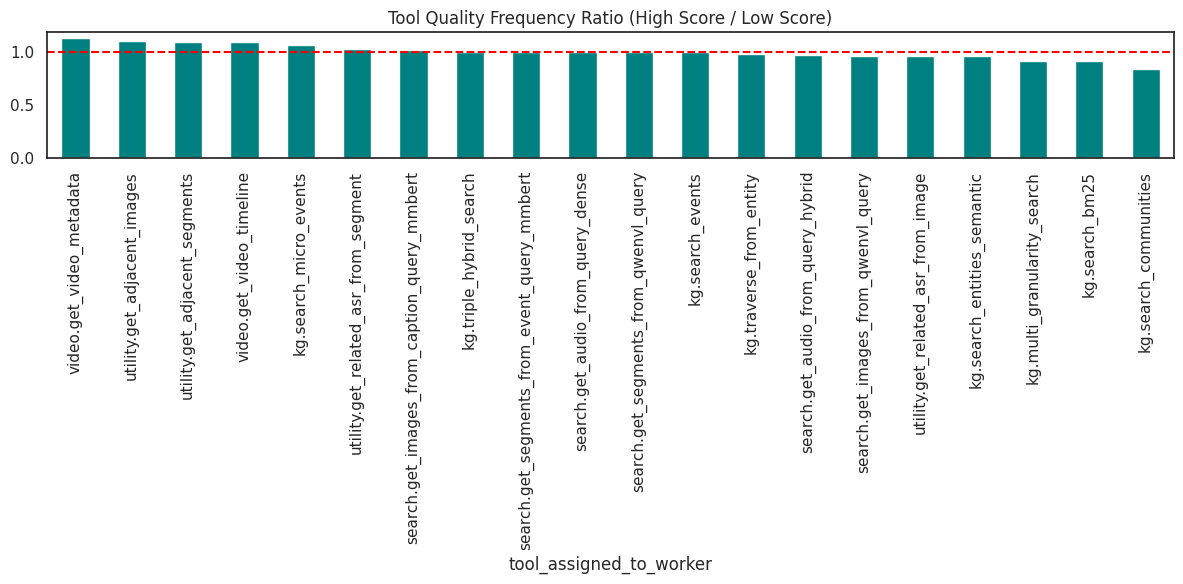

In [31]:
plt.figure(figsize=(12, 6))                                                                                                                                                           
tool_quality_freq.sort_values('quality_ratio', ascending=False)['quality_ratio'].plot(kind='bar', color='teal')                                                                       
plt.title('Tool Quality Frequency Ratio (High Score / Low Score)')                                                                                                                    
plt.axhline(1, color='red', linestyle='--')                                                                                                                                           
plt.tight_layout()                                                                                                                                                                    
plt.show()  

In [32]:
from itertools import combinations

trace_tool_set = df_worker_tool.groupby('parent_trace_id')['tool_assigned_to_worker'].apply(set)
high_answer_score_trace_ids = high_answer_scores.tolist()
pair_counts = {}
for trace_id in high_answer_score_trace_ids:
    tools = trace_tool_set.get(trace_id, set())
    for pair in combinations(sorted(tools), 5):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

In [33]:
top_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:10]                                                                                                        
print("Most common tool pairs in high-score traces:")                                                                                                                                 
for pair, count in top_pairs:                                                                                                                                                         
    print(f"  {pair}: {count} times")   

Most common tool pairs in high-score traces:
  ('kg.search_events', 'kg.triple_hybrid_search', 'search.get_audio_from_query_dense', 'search.get_audio_from_query_hybrid', 'utility.get_related_asr_from_segment'): 46 times
  ('kg.search_events', 'kg.triple_hybrid_search', 'search.get_audio_from_query_dense', 'search.get_segments_from_event_query_mmbert', 'utility.get_related_asr_from_segment'): 46 times
  ('kg.search_events', 'kg.triple_hybrid_search', 'search.get_audio_from_query_hybrid', 'search.get_segments_from_event_query_mmbert', 'utility.get_related_asr_from_segment'): 46 times
  ('kg.search_events', 'kg.triple_hybrid_search', 'search.get_audio_from_query_dense', 'search.get_audio_from_query_hybrid', 'search.get_segments_from_event_query_mmbert'): 45 times
  ('kg.search_events', 'search.get_audio_from_query_dense', 'search.get_audio_from_query_hybrid', 'search.get_segments_from_event_query_mmbert', 'utility.get_related_asr_from_segment'): 45 times
  ('kg.triple_hybrid_search', 'sea

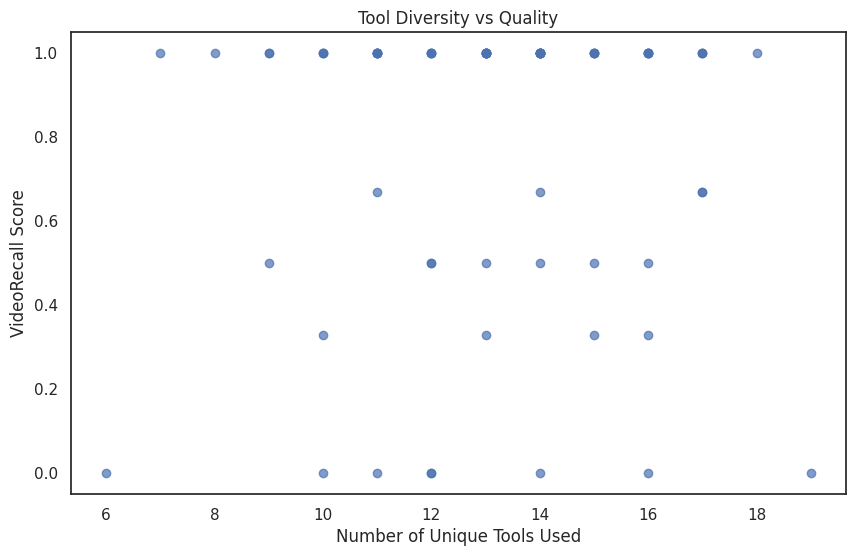

In [34]:
trace_tool_count = df_worker_tool.groupby('parent_trace_id')['tool_assigned_to_worker'].nunique()
trace_tool_count_score = pd.DataFrame({
    'trace_id': trace_tool_count.index,
    'tool_count': trace_tool_count.values
}).merge(video_recall_score, on='trace_id')
plt.figure(figsize=(10, 6))                                                                                                                                                           
plt.scatter(trace_tool_count_score['tool_count'], trace_tool_count_score['feedback_value'], alpha=0.7)                                                                                
plt.xlabel('Number of Unique Tools Used')                                                                                                                                             
plt.ylabel('VideoRecall Score')                                                                                                                                                       
plt.title('Tool Diversity vs Quality')                                                                                                                                                
plt.show() 

Text(0.5, 1.0, 'Score by Model Combination Used')

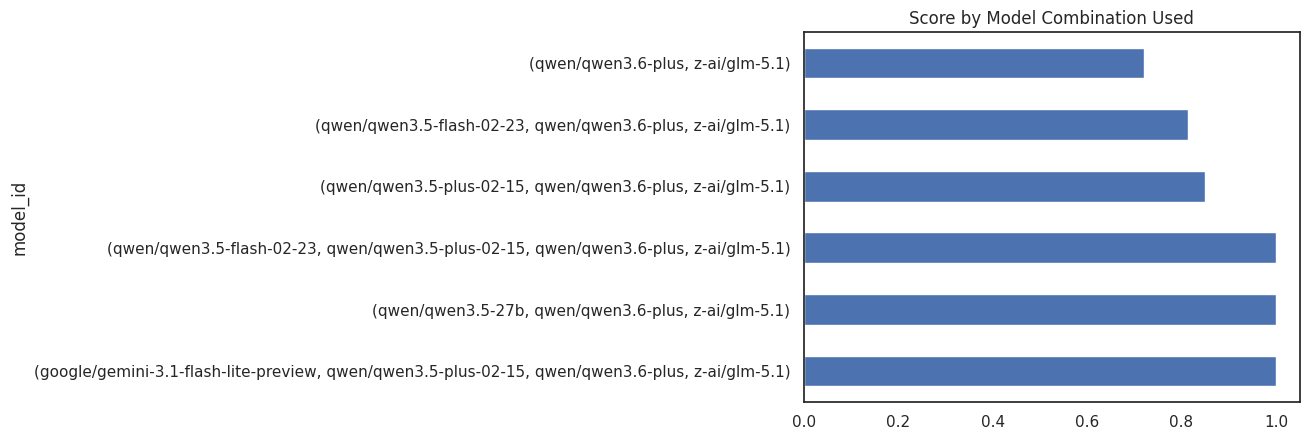

In [35]:
trace_models = df_llm.groupby('trace_id')['model_id'].apply(lambda x: tuple(sorted(set(x))))                                                                                          
trace_models_score = trace_models.reset_index().merge(video_recall_score, on='trace_id')                                                                                              
                                                                                                                                                                                    
combo_scores = trace_models_score.groupby('model_id')['feedback_value'].mean()                                                                                                        
combo_scores.sort_values(ascending=False).plot(kind='barh')                                                                                                                           
plt.title('Score by Model Combination Used')  

Text(0.5, 1.0, 'Tool Count vs Answer Score')

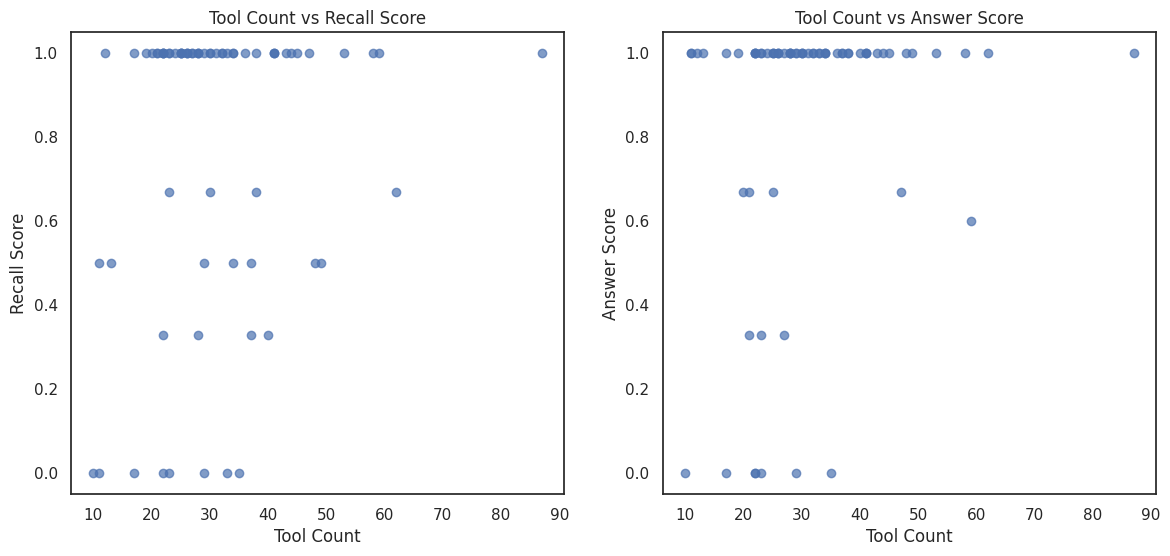

In [36]:
trace_tool_count = df_tool.groupby('trace_id').size().reset_index(name='tool_count')
tool_recall_score = trace_tool_count.merge(video_recall_score, on='trace_id')
tool_answer_score = trace_tool_count.merge(answer_score, on='trace_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(tool_recall_score['tool_count'], tool_recall_score['feedback_value'], alpha=0.7)
axes[0].set_xlabel('Tool Count')
axes[0].set_ylabel('Recall Score')
axes[0].set_title('Tool Count vs Recall Score')


axes[1].scatter(tool_answer_score['tool_count'], tool_answer_score['feedback_value'], alpha=0.7)
axes[1].set_xlabel('Tool Count')
axes[1].set_ylabel('Answer Score')
axes[1].set_title('Tool Count vs Answer Score')

/tmp/ipykernel_3115219/3516024826.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tool_recall_score.groupby('tool_bin')['feedback_value'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
/tmp/ipykernel_3115219/3516024826.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tool_answer_score.groupby('tool_bin')['feedback_value'].mean().plot(kind='bar', ax=axes[1], color='coral')


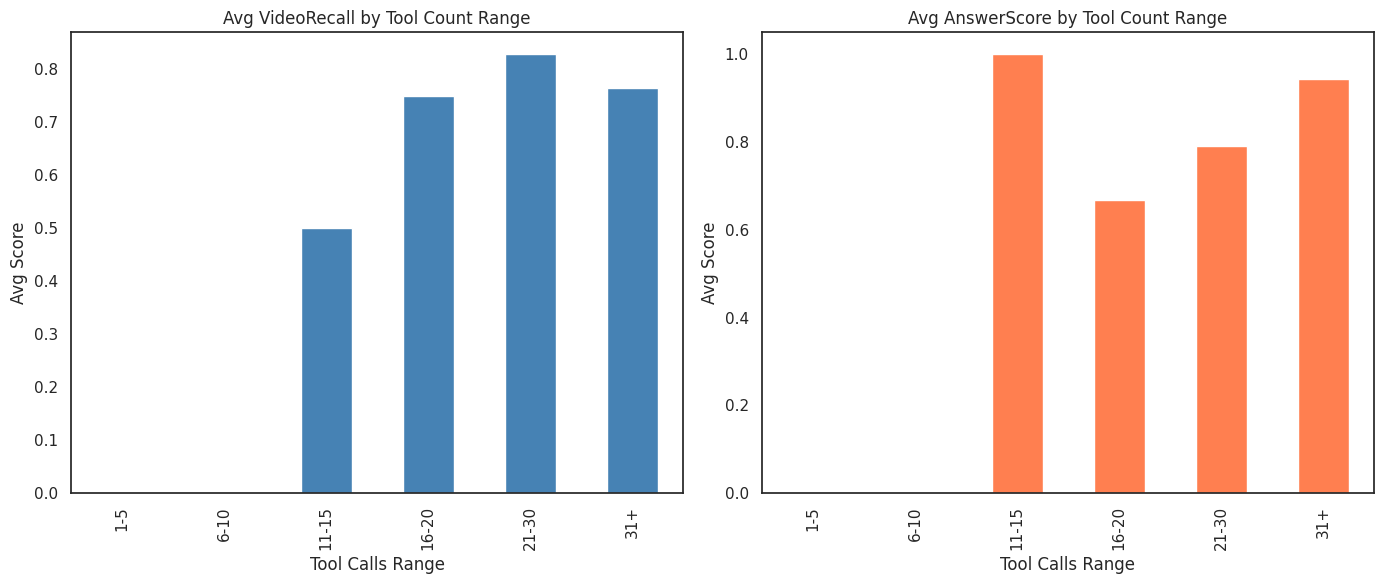

In [37]:
bins = [0, 5, 10, 15, 20, 30, 50]                                                                                                                                                     
labels = ['1-5', '6-10', '11-15', '16-20', '21-30', '31+']                                                                                                                            
                                                                                                                                                                                    
tool_recall_score['tool_bin'] = pd.cut(tool_recall_score['tool_count'], bins=bins, labels=labels)                                                                                                 
tool_answer_score['tool_bin'] = pd.cut(tool_answer_score['tool_count'], bins=bins, labels=labels)                                                                                                 
                                                                                                                                                                                    
# Bar chart of avg score per bin                                                                                                                                                      
fig, axes = plt.subplots(1, 2, figsize=(14, 6))                                                                                                                                       
                                                                                                                                                                                    
tool_recall_score.groupby('tool_bin')['feedback_value'].mean().plot(kind='bar', ax=axes[0], color='steelblue')                                                                              
axes[0].set_title('Avg VideoRecall by Tool Count Range')                                                                                                                              
axes[0].set_xlabel('Tool Calls Range')                                                                                                                                                
axes[0].set_ylabel('Avg Score')                                                                                                                                                       
                                                                                                                                                                                    
tool_answer_score.groupby('tool_bin')['feedback_value'].mean().plot(kind='bar', ax=axes[1], color='coral')                                                                                  
axes[1].set_title('Avg AnswerScore by Tool Count Range')                                                                                                                              
axes[1].set_xlabel('Tool Calls Range')                                                                                                                                                
axes[1].set_ylabel('Avg Score')                                                                                                                                                       
                                                                                                                                                                                    
plt.tight_layout()                                                                                                                                                                    
plt.show()  

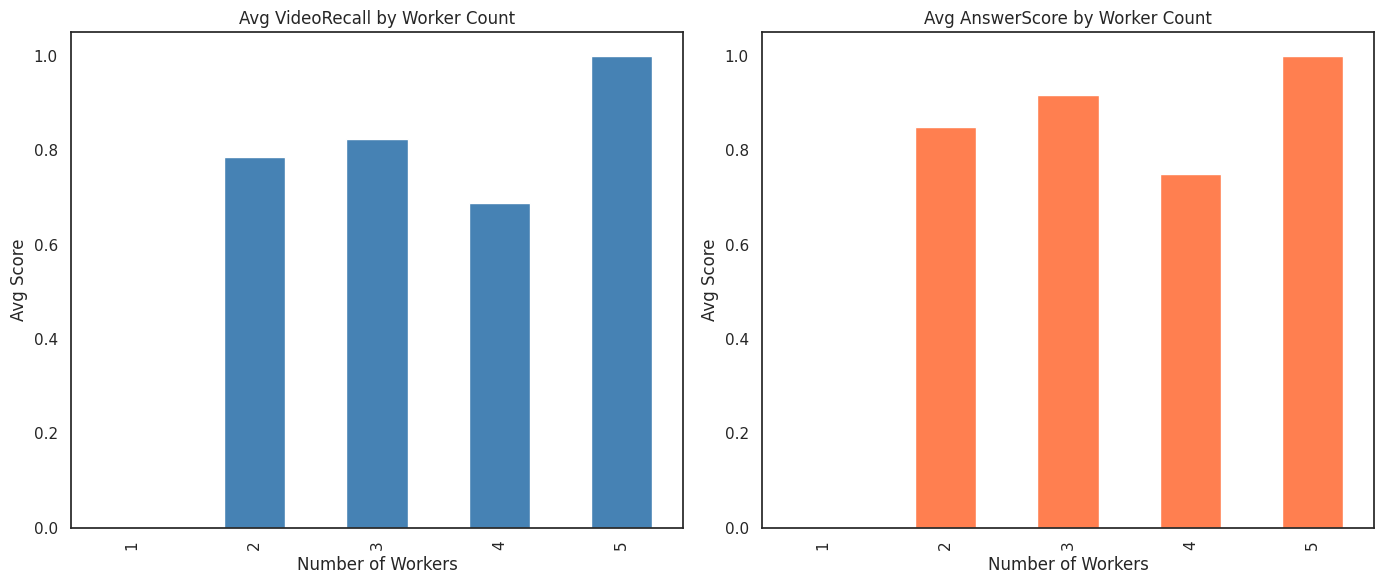

In [38]:
trace_worker_count = df_worker_tool.groupby('parent_trace_id')['worker_agent_name'].nunique().reset_index(name='worker_count')                                                        
trace_worker_count.columns = ['trace_id', 'worker_count']                                                                                                                             
                                                                                                                                                                                    
                                                                                                                                                                   
worker_recall = trace_worker_count.merge(video_recall_score, on='trace_id')                                                                                                           
worker_answer = trace_worker_count.merge(answer_score, on='trace_id')       
fig, axes = plt.subplots(1, 2, figsize=(14, 6))                                                                                                                                       
                                                                                                                                                                                    
worker_recall.groupby('worker_count')['feedback_value'].mean().plot(kind='bar', ax=axes[0], color='steelblue')                                                                        
axes[0].set_title('Avg VideoRecall by Worker Count')                                                                                                                                  
axes[0].set_xlabel('Number of Workers')                                                                                                                                               
axes[0].set_ylabel('Avg Score')                                                                                                                                                       
                                                                                                                                                                                    
worker_answer.groupby('worker_count')['feedback_value'].mean().plot(kind='bar', ax=axes[1], color='coral')                                                                            
axes[1].set_title('Avg AnswerScore by Worker Count')                                                                                                                                  
axes[1].set_xlabel('Number of Workers')                                                                                                                                               
axes[1].set_ylabel('Avg Score')                                                                                                                                                       
                                                                                                                                                                                    
plt.tight_layout()                                                                                                                                                                    
plt.show()             

# Deeper Analysis

## Divide DataFrames for Deeper Analysis

In [39]:
human_judgement = df_assessments[df_assessments['assessment_name'] == 'HumanJudgement']
video_recall = df_assessments[df_assessments['assessment_name'] == 'VideoRecall']
answer_correctness = df_assessments[df_assessments['assessment_name'] == 'AnswerCorrectnessPoint']

print(f"HumanJudgement: {len(human_judgement)} records")
print(f"VideoRecall: {len(video_recall)} records")
print(f"AnswerCorrectnessPoint: {len(answer_correctness)} records")

HumanJudgement: 70 records
VideoRecall: 70 records
AnswerCorrectnessPoint: 70 records


In [40]:
df_llm_qwen36_plus = df_llm[df_llm['model_id'] == 'qwen/qwen3.6-plus']
df_llm_glm51 = df_llm[df_llm['model_id'] == 'z-ai/glm-5.1']
df_llm_qwen35_flash = df_llm[df_llm['model_id'] == 'qwen/qwen3.5-flash-02-23']
df_llm_qwen35_27b = df_llm[df_llm['model_id'] == 'qwen/qwen3.5-27b']
df_llm_qwen35_plus = df_llm[df_llm['model_id'] == 'qwen/qwen3.5-plus-02-15']
df_llm_gemini = df_llm[df_llm['model_id'] == 'google/gemini-3.1-flash-lite-preview']

print("LLM calls by model:")
print(f"  qwen/qwen3.6-plus: {len(df_llm_qwen36_plus)}")
print(f"  z-ai/glm-5.1: {len(df_llm_glm51)}")
print(f"  qwen/qwen3.5-flash-02-23: {len(df_llm_qwen35_flash)}")
print(f"  qwen/qwen3.5-27b: {len(df_llm_qwen35_27b)}")
print(f"  qwen/qwen3.5-plus-02-15: {len(df_llm_qwen35_plus)}")
print(f"  google/gemini-3.1-flash-lite-preview: {len(df_llm_gemini)}")

LLM calls by model:
  qwen/qwen3.6-plus: 1821
  z-ai/glm-5.1: 389
  qwen/qwen3.5-flash-02-23: 278
  qwen/qwen3.5-27b: 23
  qwen/qwen3.5-plus-02-15: 381
  google/gemini-3.1-flash-lite-preview: 15


In [41]:
df_agent_root = df_agent[df_agent['model_name'] == 'VideoDeepSearch']
df_agent_orchestrator = df_agent[df_agent['model_name'] == 'Orchestrator']
df_agent_workers = df_agent[df_agent['model_name'].str.contains('worker')]

print("Agent spans by type:")
print(f"  Root (VideoDeepSearch): {len(df_agent_root)}")
print(f"  Orchestrator: {len(df_agent_orchestrator)}")
print(f"  Workers: {len(df_agent_workers)}")
print(f"\nWorker types: {df_agent_workers['model_name'].unique()}")

Agent spans by type:
  Root (VideoDeepSearch): 70
  Orchestrator: 70
  Workers: 132

Worker types: ['video_discovery_worker' 'visual_indicators_worker' 'audio_alerts_worker'
 'caption_asr_search_worker' 'visual_kg_search_worker'
 'tornado_visual_analysis_worker' 'split_screen_tornado_tracks_worker'
 'video_segment_search_worker' 'visual_speech_search_worker'
 'kg_audio_micro_event_worker' 'visual_segment_search_worker'
 'audio_asr_search_worker' 'transcript_keyword_search_worker'
 'visual_cooking_search_worker' 'asr_transcript_search_worker'
 'caption_kg_search_worker' 'kg_broad_search_worker'
 'asr_visual_search_worker' 'visual_asr_search_worker'
 'visual_caption_search_worker' 'asr_audio_search_worker'
 'deep_analysis_worker' 'steak_sear_visual_worker' 'steak_doneness_worker'
 'steak_third_video_worker' 'steak_sirloin_searing_worker'
 'kg_multi_granularity_search_worker'
 'caption_transcript_visual_search_worker' 'kg_search_worker'
 'asr_caption_search_worker' 'visual_search_worker'


In [42]:
trace_cost = df_llm.groupby('trace_id')['cost'].sum().reset_index()
trace_cost.rename(columns={'cost': 'total_cost'}, inplace=True)

high_cost_traces = trace_cost[trace_cost['total_cost'] >= trace_cost['total_cost'].quantile(0.75)]['trace_id']
low_cost_traces = trace_cost[trace_cost['total_cost'] <= trace_cost['total_cost'].quantile(0.25)]['trace_id']
medium_cost_traces = trace_cost[
    (trace_cost['total_cost'] > trace_cost['total_cost'].quantile(0.25)) & 
    (trace_cost['total_cost'] < trace_cost['total_cost'].quantile(0.75))
]['trace_id']

print("Traces by cost tier:")
print(f"  High cost (>=75th percentile): {len(high_cost_traces)}")
print(f"  Medium cost: {len(medium_cost_traces)}")
print(f"  Low cost (<=25th percentile): {len(low_cost_traces)}")

Traces by cost tier:
  High cost (>=75th percentile): 18
  Medium cost: 34
  Low cost (<=25th percentile): 18


In [43]:
df_llm_high_cost = df_llm[df_llm['trace_id'].isin(high_cost_traces)]
df_llm_low_cost = df_llm[df_llm['trace_id'].isin(low_cost_traces)]
df_llm_medium_cost = df_llm[df_llm['trace_id'].isin(medium_cost_traces)]

df_tool_high_cost = df_tool[df_tool['trace_id'].isin(high_cost_traces)]
df_tool_low_cost = df_tool[df_tool['trace_id'].isin(low_cost_traces)]
df_tool_medium_cost = df_tool[df_tool['trace_id'].isin(medium_cost_traces)]

df_agent_high_cost = df_agent[df_agent['trace_id'].isin(high_cost_traces)]
df_agent_low_cost = df_agent[df_agent['trace_id'].isin(low_cost_traces)]
df_agent_medium_cost = df_agent[df_agent['trace_id'].isin(medium_cost_traces)]

In [44]:
high_recall_traces = video_recall[video_recall['feedback_value'] >= 0.7]['trace_id']
medium_recall_traces = video_recall[(video_recall['feedback_value'] >= 0.33) & (video_recall['feedback_value'] < 0.7)]['trace_id']
low_recall_traces = video_recall[video_recall['feedback_value'] < 0.33]['trace_id']

print("Traces by VideoRecall performance:")
print(f"  High recall (>=0.7): {len(high_recall_traces)}")
print(f"  Medium recall (0.33-0.7): {len(medium_recall_traces)}")
print(f"  Low recall (<0.33): {len(low_recall_traces)}")

df_llm_high_recall = df_llm[df_llm['trace_id'].isin(high_recall_traces)]
df_llm_medium_recall = df_llm[df_llm['trace_id'].isin(medium_recall_traces)]
df_llm_low_recall = df_llm[df_llm['trace_id'].isin(low_recall_traces)]

Traces by VideoRecall performance:
  High recall (>=0.7): 47
  Medium recall (0.33-0.7): 15
  Low recall (<0.33): 8


In [45]:
high_answer_traces = answer_correctness[answer_correctness['feedback_value'] >= 0.8]['trace_id']
medium_answer_traces = answer_correctness[(answer_correctness['feedback_value'] >= 0.4) & (answer_correctness['feedback_value'] < 0.8)]['trace_id']
low_answer_traces = answer_correctness[answer_correctness['feedback_value'] < 0.4]['trace_id']

print("Traces by AnswerCorrectness performance:")
print(f"  High answer (>=0.8): {len(high_answer_traces)}")
print(f"  Medium answer (0.4-0.8): {len(medium_answer_traces)}")
print(f"  Low answer (<0.4): {len(low_answer_traces)}")

df_tool_high_answer = df_tool[df_tool['trace_id'].isin(high_answer_traces)]
df_tool_medium_answer = df_tool[df_tool['trace_id'].isin(medium_answer_traces)]
df_tool_low_answer = df_tool[df_tool['trace_id'].isin(low_answer_traces)]

Traces by AnswerCorrectness performance:
  High answer (>=0.8): 55
  Medium answer (0.4-0.8): 5
  Low answer (<0.4): 10


In [46]:
unique_workers = df_worker_tool['worker_agent_name'].unique()
worker_dfs = {}
for worker in unique_workers:
    worker_dfs[worker] = df_worker_tool[df_worker_tool['worker_agent_name'] == worker]

print(f"Total unique worker agents: {len(unique_workers)}")
for worker, df in worker_dfs.items():
    print(f"  {worker}: {len(df)} tool assignments")

Total unique worker agents: 134
  video_discovery_worker: 20 tool assignments
  visual_indicators_worker: 7 tool assignments
  audio_alerts_worker: 5 tool assignments
  caption_asr_search_worker: 30 tool assignments
  visual_kg_search_worker: 26 tool assignments
  tornado_outbreak_discovery: 5 tool assignments
  tornado_visual_analysis_worker: 5 tool assignments
  split_screen_tornado_tracks_worker: 5 tool assignments
  kg_public_speaking_search: 32 tool assignments
  video_segment_search_worker: 7 tool assignments
  visual_speech_search_worker: 6 tool assignments
  kg_audio_micro_event_worker: 7 tool assignments
  kg_chicken_breast_search: 6 tool assignments
  visual_segment_search_worker: 6 tool assignments
  audio_asr_search_worker: 3 tool assignments
  tornado_segment_finder: 5 tool assignments
  oklahoma_tornado_deep_analyzer: 8 tool assignments
  transcript_keyword_search_worker: 20 tool assignments
  visual_cooking_search_worker: 14 tool assignments
  asr_transcript_search_worke

In [47]:
trace_latency = df_agent.groupby('trace_id')['latency_sec'].sum().reset_index()
trace_latency.rename(columns={'latency_sec': 'total_latency'}, inplace=True)

high_latency_traces = trace_latency[trace_latency['total_latency'] >= trace_latency['total_latency'].quantile(0.75)]['trace_id']
low_latency_traces = trace_latency[trace_latency['total_latency'] <= trace_latency['total_latency'].quantile(0.25)]['trace_id']

print("Traces by latency tier:")
print(f"  High latency (>=75th percentile): {len(high_latency_traces)}")
print(f"  Low latency (<=25th percentile): {len(low_latency_traces)}")
print(f"\nHigh latency threshold: {trace_latency['total_latency'].quantile(0.75):.2f}s")
print(f"Low latency threshold: {trace_latency['total_latency'].quantile(0.25):.2f}s")

Traces by latency tier:
  High latency (>=75th percentile): 18
  Low latency (<=25th percentile): 18

High latency threshold: 1982.84s
Low latency threshold: 1230.07s


In [48]:
df_llm_high_latency = df_llm[df_llm['trace_id'].isin(high_latency_traces)]
df_llm_low_latency = df_llm[df_llm['trace_id'].isin(low_latency_traces)]

df_tool_high_latency = df_tool[df_tool['trace_id'].isin(high_latency_traces)]
df_tool_low_latency = df_tool[df_tool['trace_id'].isin(low_latency_traces)]

In [49]:
with open('analysis_results/trace_analysis_results.json', 'r') as f:
    results = json.load(f)
summary_trace_df = pd.read_csv('analysis_results/trace_analysis_summary.csv')

json_traces = results['traces']

general_trace_records = []
wk_records = []
tool_records = []
agent_metrics_records = []
video_match_records = []
key_steps_records = []

for trace in json_traces:
    general_trace_record = {
        'trace_id': trace['trace_id'],
        'total_spans': trace['total_spans'],
        'total_tool_calls': trace['total_tool_calls'],
        'total_llm_calls': trace['total_llm_calls'],
        'total_agent_calls': trace.get('total_agent_calls', 0),
        'execution_duration_ms': trace.get('execution_duration_ms', 0),
        'execution_duration_sec': trace.get('execution_duration_ms', 0) / 1000,
        'workers_spawned': trace.get('workers_spawned', 0),
        'agents_count': len(trace.get('agents', [])),
        'potential_savings': trace.get('potential_savings', 0),
        'potential_savings_pct': trace.get('potential_savings_pct', 0),
        'video_match': trace.get('video_match', False),
        'has_expected_record': trace.get('has_expected_record', False),
        'expected_video_count': len(trace.get('expected_video_ids', [])),
        'actual_video_count': len(trace.get('actual_video_ids', [])),
    }
    general_trace_records.append(general_trace_record)
    
    for wk_detail in trace.get('worker_details', []):
        wk_record = {
            'trace_id': trace['trace_id'],
            'step_th': wk_detail['step'],
            'worker_agent_name': wk_detail['agent'],
            'worker_tools_count': wk_detail.get('tools', 0),
        }
        wk_records.append(wk_record)
    
    for tool_s in trace.get('tool_sequence', []):
        tool_record = {
            'trace_id': trace['trace_id'],
            'tool_name': tool_s['tool'],
            'agent': tool_s['agent'],
            'step_th': tool_s['step']
        }
        tool_records.append(tool_record)
    
    per_agent_metrics = trace.get('per_agent_metrics', {})
    for agent_name, metrics in per_agent_metrics.items():
        agent_record = {
            'trace_id': trace['trace_id'],
            'agent_name': agent_name,
            'tool_calls': metrics.get('tool_calls', 0),
            'llm_calls': metrics.get('llm_calls', 0),
            'tools_used': metrics.get('tools_used', []),
            'unique_tools_used': len(set(metrics.get('tools_used', []))),
        }
        agent_metrics_records.append(agent_record)
    
    key_steps_record = {
        'trace_id': trace['trace_id'],
        'video_id_found_step': trace.get('video_id_found_step'),
        'timeline_found_step': trace.get('timeline_found_step'),
        'core_answer_step': trace.get('core_answer_step'),
        'final_step': trace.get('final_step'),
    }
    key_steps_records.append(key_steps_record)

df_trace_general = pd.DataFrame(general_trace_records)
df_trace_workers = pd.DataFrame(wk_records)
df_trace_tools = pd.DataFrame(tool_records)
df_trace_agent_metrics = pd.DataFrame(agent_metrics_records)
df_trace_key_steps = pd.DataFrame(key_steps_records)

print(f"General trace df: {len(df_trace_general)} rows")
print(f"Worker details df: {len(df_trace_workers)} rows")
print(f"Tool sequence df: {len(df_trace_tools)} rows")
print(f"Agent metrics df: {len(df_trace_agent_metrics)} rows")
print(f"Key steps df: {len(df_trace_key_steps)} rows")

General trace df: 70 rows
Worker details df: 132 rows
Tool sequence df: 2571 rows
Agent metrics df: 319 rows
Key steps df: 70 rows


In [50]:
df_trace_general.head()

,trace_id,total_spans,total_tool_calls,total_llm_calls,total_agent_calls,execution_duration_ms,execution_duration_sec,workers_spawned,agents_count,potential_savings,potential_savings_pct,video_match,has_expected_record,expected_video_count,actual_video_count
0,tr-2b35f46018dd98383e97c207cea057a2,78,34,39,5,641974,641.974,3,5,73,93.59,True,True,3,61
1,tr-c59695308af3dad1c0246b3d474fd588,57,24,29,4,437343,437.343,2,4,54,94.74,True,True,1,61
2,tr-26f3f4126a6ef4f29783ddd36c19bfe8,96,43,48,5,696664,696.664,2,5,91,94.79,True,True,3,61
3,tr-2d26e251e7afb64d9a467bb4fc451fc4,60,26,30,4,759919,759.919,1,4,55,91.67,True,True,2,62
4,tr-20c3a36333100acf40c031fe936d2368,86,39,43,4,883318,883.318,2,4,81,94.19,True,True,2,61


In [51]:
df_trace_workers.head()

,trace_id,step_th,worker_agent_name,worker_tools_count
0,tr-2b35f46018dd98383e97c207cea057a2,13,video_discovery_worker,8
1,tr-2b35f46018dd98383e97c207cea057a2,33,visual_indicators_worker,9
2,tr-2b35f46018dd98383e97c207cea057a2,55,audio_alerts_worker,10
3,tr-c59695308af3dad1c0246b3d474fd588,11,caption_asr_search_worker,8
4,tr-c59695308af3dad1c0246b3d474fd588,32,visual_kg_search_worker,11


In [52]:
df_trace_tools.head()

,trace_id,tool_name,agent,step_th
0,tr-2b35f46018dd98383e97c207cea057a2,get_member_information,VideoDeepSearch,3
1,tr-2b35f46018dd98383e97c207cea057a2,delegate_task_to_member,VideoDeepSearch,5
2,tr-2b35f46018dd98383e97c207cea057a2,get_available_worker_tools,Orchestrator,8
3,tr-2b35f46018dd98383e97c207cea057a2,get_available_models,Orchestrator,10
4,tr-2b35f46018dd98383e97c207cea057a2,spawn_and_run_worker,Orchestrator,12


In [53]:
df_trace_high_spans = df_trace_general[df_trace_general['total_spans'] >= df_trace_general['total_spans'].quantile(0.75)]
df_trace_low_spans = df_trace_general[df_trace_general['total_spans'] <= df_trace_general['total_spans'].quantile(0.25)]
df_trace_medium_spans = df_trace_general[
    (df_trace_general['total_spans'] > df_trace_general['total_spans'].quantile(0.25)) & 
    (df_trace_general['total_spans'] < df_trace_general['total_spans'].quantile(0.75))
]

print("Traces by span count:")
print(f"  High spans (>=75th percentile): {len(df_trace_high_spans)}")
print(f"  Medium spans: {len(df_trace_medium_spans)}")
print(f"  Low spans (<=25th percentile): {len(df_trace_low_spans)}")

Traces by span count:
  High spans (>=75th percentile): 19
  Medium spans: 33
  Low spans (<=25th percentile): 18


In [54]:
df_trace_high_tools = df_trace_general[df_trace_general['total_tool_calls'] >= df_trace_general['total_tool_calls'].quantile(0.75)]
df_trace_low_tools = df_trace_general[df_trace_general['total_tool_calls'] <= df_trace_general['total_tool_calls'].quantile(0.25)]

print("Traces by tool calls:")
print(f"  High tool calls (>=75th percentile): {len(df_trace_high_tools)}")
print(f"  Low tool calls (<=25th percentile): {len(df_trace_low_tools)}")

Traces by tool calls:
  High tool calls (>=75th percentile): 19
  Low tool calls (<=25th percentile): 19


In [55]:
df_trace_high_llm = df_trace_general[df_trace_general['total_llm_calls'] >= df_trace_general['total_llm_calls'].quantile(0.75)]
df_trace_low_llm = df_trace_general[df_trace_general['total_llm_calls'] <= df_trace_general['total_llm_calls'].quantile(0.25)]

print("Traces by LLM calls:")
print(f"  High LLM calls (>=75th percentile): {len(df_trace_high_llm)}")
print(f"  Low LLM calls (<=25th percentile): {len(df_trace_low_llm)}")

Traces by LLM calls:
  High LLM calls (>=75th percentile): 19
  Low LLM calls (<=25th percentile): 18


In [56]:
unique_workers_in_traces = df_trace_workers['worker_agent_name'].unique()
trace_worker_dfs = {}
for worker in unique_workers_in_traces:
    trace_worker_dfs[worker] = df_trace_workers[df_trace_workers['worker_agent_name'] == worker]

print(f"Total unique workers in trace analysis: {len(unique_workers_in_traces)}")
for worker, df in sorted(trace_worker_dfs.items(), key=lambda x: len(x[1]), reverse=True)[:10]:
    print(f"  {worker}: {len(df)} appearances")

Total unique workers in trace analysis: 94
  caption_asr_search_worker: 5 appearances
  asr_transcript_search_worker: 5 appearances
  visual_search_worker: 5 appearances
  transcript_keyword_search_worker: 4 appearances
  kg_search_worker: 4 appearances
  asr_caption_search_worker: 4 appearances
  visual_kg_search_worker: 3 appearances
  kg_visual_search_worker: 3 appearances
  transcript_search_worker: 3 appearances
  video_discovery_worker: 2 appearances


In [57]:
trace_tool_counts = df_trace_tools.groupby('trace_id').size().reset_index(name='tool_sequence_count')
trace_tool_counts['tool_sequence_count'].describe()

count    70.000000
mean     36.728571
std      13.741845
min      14.000000
25%      28.000000
50%      34.000000
75%      43.000000
max      95.000000
Name: tool_sequence_count, dtype: float64

In [58]:
df_trace_general_with_scores = df_trace_general.merge(video_recall, on='trace_id', how='left')
df_trace_general_with_scores = df_trace_general_with_scores.merge(answer_correctness, on='trace_id', how='left', suffixes=('_recall', '_answer'))

df_trace_general_with_scores.head()

,trace_id,total_spans,total_tool_calls,total_llm_calls,total_agent_calls,execution_duration_ms,execution_duration_sec,workers_spawned,agents_count,potential_savings,...,video_match,has_expected_record,expected_video_count,actual_video_count,assessment_name_recall,assessment_id_recall,feedback_value_recall,assessment_name_answer,assessment_id_answer,feedback_value_answer
0,tr-2b35f46018dd98383e97c207cea057a2,78,34,39,5,641974,641.974,3,5,73,...,True,True,3,61,VideoRecall,a-d568fe440793480da05d6cc20b16211b,0.33,AnswerCorrectnessPoint,a-3e857746c1c34d85821704dd4c83a2cb,1.0
1,tr-c59695308af3dad1c0246b3d474fd588,57,24,29,4,437343,437.343,2,4,54,...,True,True,1,61,VideoRecall,a-89cccc4cdbc24c759e633f877b656b97,1.0,AnswerCorrectnessPoint,a-d372d9a85e8e4cdeb1413cc060e5e268,0.67
2,tr-26f3f4126a6ef4f29783ddd36c19bfe8,96,43,48,5,696664,696.664,2,5,91,...,True,True,3,61,VideoRecall,a-c488790e30de43dc8a286217ba2ee892,0.33,AnswerCorrectnessPoint,a-92ab14feac3b400e922f21bb5b0613e2,1.0
3,tr-2d26e251e7afb64d9a467bb4fc451fc4,60,26,30,4,759919,759.919,1,4,55,...,True,True,2,62,VideoRecall,a-89ffbed016cd45868f26b94b8656a08b,1.0,AnswerCorrectnessPoint,a-49c2920928394b98a1595a8c1bba1024,0.67
4,tr-20c3a36333100acf40c031fe936d2368,86,39,43,4,883318,883.318,2,4,81,...,True,True,2,61,VideoRecall,a-870892bd703e4abfbae9852935983df0,0.5,AnswerCorrectnessPoint,a-10ee5fe3fb3b4246b5319b6a09480423,1.0


In [59]:
high_score_traces = df_trace_general_with_scores[df_trace_general_with_scores['feedback_value_recall'] >= 0.7]['trace_id']
low_score_traces = df_trace_general_with_scores[df_trace_general_with_scores['feedback_value_recall'] < 0.33]['trace_id']

df_trace_tools_high_score = df_trace_tools[df_trace_tools['trace_id'].isin(high_score_traces)]
df_trace_tools_low_score = df_trace_tools[df_trace_tools['trace_id'].isin(low_score_traces)]

print(f"Tool sequences in high-score traces: {len(df_trace_tools_high_score)}")
print(f"Tool sequences in low-score traces: {len(df_trace_tools_low_score)}")

Tool sequences in high-score traces: 1763
Tool sequences in low-score traces: 221


In [60]:
high_score_tool_freq = df_trace_tools_high_score['tool_name'].value_counts()
low_score_tool_freq = df_trace_tools_low_score['tool_name'].value_counts()

trace_tool_comparison = pd.DataFrame({
    'High Score': high_score_tool_freq,
    'Low Score': low_score_tool_freq
}).fillna(0)
trace_tool_comparison['ratio'] = trace_tool_comparison['High Score'] / trace_tool_comparison['Low Score'].replace(0, 0.01)
trace_tool_comparison.sort_values('ratio', ascending=False).head(10)

,High Score,Low Score,ratio
tool_name,,,
get_video_timeline,29,0.0,2900.000000
traverse_from_entity,40,1.0,40.000000
get_related_asr_from_image,74,5.0,14.800000
search_micro_events,65,5.0,13.000000
get_related_asr_from_segment,457,41.0,11.146341
get_adjacent_segments,89,8.0,11.125000
get_audio_from_query_hybrid,96,9.0,10.666667
get_images_from_caption_query_mmbert,21,2.0,10.500000
get_segments_from_qwenvl_query,60,7.0,8.571429


In [61]:
''

''

# Cross-DataFrame Visualization Analysis
Finding patterns between Tools, Agents, LLM usage, and Assessment Scores

## 1. Master Trace Summary - Combining All Metrics

In [62]:
trace_metrics = df_llm.groupby('trace_id').agg({
    'input_tokens': 'sum',
    'output_tokens': 'sum',
    'cost': 'sum',
}).reset_index()
trace_metrics.rename(columns={'cost': 'total_cost', 'input_tokens': 'total_input_tokens', 'output_tokens': 'total_output_tokens'}, inplace=True)

trace_agent_metrics = df_agent.groupby('trace_id').agg({
    'latency_sec': 'sum',
}).reset_index()
trace_agent_metrics.rename(columns={'latency_sec': 'total_latency_sec'}, inplace=True)

trace_tool_metrics = df_tool.groupby('trace_id').agg({
    'latency_ms': 'sum',
}).reset_index()
trace_tool_metrics.rename(columns={'latency_ms': 'total_tool_latency_ms'}, inplace=True)

trace_worker_count = df_worker_tool.groupby('parent_trace_id')['worker_agent_name'].nunique().reset_index()
trace_worker_count.columns = ['trace_id', 'worker_count']

trace_tool_diversity = df_tool.groupby('trace_id')['tool_name'].nunique().reset_index()
trace_tool_diversity.columns = ['trace_id', 'unique_tool_count']

trace_model_diversity = df_llm.groupby('trace_id')['model_id'].nunique().reset_index()
trace_model_diversity.columns = ['trace_id', 'unique_model_count']

master_trace = df_trace_general.merge(trace_metrics, on='trace_id', how='left')
master_trace = master_trace.merge(trace_agent_metrics, on='trace_id', how='left')
master_trace = master_trace.merge(trace_tool_metrics, on='trace_id', how='left')
master_trace = master_trace.merge(trace_worker_count, on='trace_id', how='left')
master_trace = master_trace.merge(trace_tool_diversity, on='trace_id', how='left')
master_trace = master_trace.merge(trace_model_diversity, on='trace_id', how='left')
master_trace = master_trace.merge(video_recall, on='trace_id', how='left')
master_trace = master_trace.merge(answer_correctness, on='trace_id', how='left', suffixes=('_recall', '_answer'))
master_trace = master_trace.merge(human_judgement, on='trace_id', how='left')
master_trace.rename(columns={'feedback_value': 'human_judgement_score'}, inplace=True)

master_trace.head()

,trace_id,total_spans,total_tool_calls,total_llm_calls,total_agent_calls,execution_duration_ms,execution_duration_sec,workers_spawned,agents_count,potential_savings,...,unique_model_count,assessment_name_recall,assessment_id_recall,feedback_value_recall,assessment_name_answer,assessment_id_answer,feedback_value_answer,assessment_name,assessment_id,human_judgement_score
0,tr-2b35f46018dd98383e97c207cea057a2,78,34,39,5,641974,641.974,3,5,73,...,2,VideoRecall,a-d568fe440793480da05d6cc20b16211b,0.33,AnswerCorrectnessPoint,a-3e857746c1c34d85821704dd4c83a2cb,1.0,HumanJudgement,a-7ab095d5421d4b46a71c1c50bd45adfe,0.9
1,tr-c59695308af3dad1c0246b3d474fd588,57,24,29,4,437343,437.343,2,4,54,...,4,VideoRecall,a-89cccc4cdbc24c759e633f877b656b97,1.0,AnswerCorrectnessPoint,a-d372d9a85e8e4cdeb1413cc060e5e268,0.67,HumanJudgement,a-776e7f5fc0b2434d94b17ecedca945e5,0.7
2,tr-26f3f4126a6ef4f29783ddd36c19bfe8,96,43,48,5,696664,696.664,2,5,91,...,2,VideoRecall,a-c488790e30de43dc8a286217ba2ee892,0.33,AnswerCorrectnessPoint,a-92ab14feac3b400e922f21bb5b0613e2,1.0,HumanJudgement,a-0168c9234624440585a1da5dda7901af,0.38
3,tr-2d26e251e7afb64d9a467bb4fc451fc4,60,26,30,4,759919,759.919,1,4,55,...,2,VideoRecall,a-89ffbed016cd45868f26b94b8656a08b,1.0,AnswerCorrectnessPoint,a-49c2920928394b98a1595a8c1bba1024,0.67,HumanJudgement,a-edf5e19f96004a41a5e4dcc4127aeef0,0.81
4,tr-20c3a36333100acf40c031fe936d2368,86,39,43,4,883318,883.318,2,4,81,...,3,VideoRecall,a-870892bd703e4abfbae9852935983df0,0.5,AnswerCorrectnessPoint,a-10ee5fe3fb3b4246b5319b6a09480423,1.0,HumanJudgement,a-cb87e33a9b3e489eabd2eceec5503871,0.75


In [63]:
master_trace.columns.tolist()

['trace_id',
 'total_spans',
 'total_tool_calls',
 'total_llm_calls',
 'total_agent_calls',
 'execution_duration_ms',
 'execution_duration_sec',
 'workers_spawned',
 'agents_count',
 'potential_savings',
 'potential_savings_pct',
 'video_match',
 'has_expected_record',
 'expected_video_count',
 'actual_video_count',
 'total_input_tokens',
 'total_output_tokens',
 'total_cost',
 'total_latency_sec',
 'total_tool_latency_ms',
 'worker_count',
 'unique_tool_count',
 'unique_model_count',
 'assessment_name_recall',
 'assessment_id_recall',
 'feedback_value_recall',
 'assessment_name_answer',
 'assessment_id_answer',
 'feedback_value_answer',
 'assessment_name',
 'assessment_id',
 'human_judgement_score']

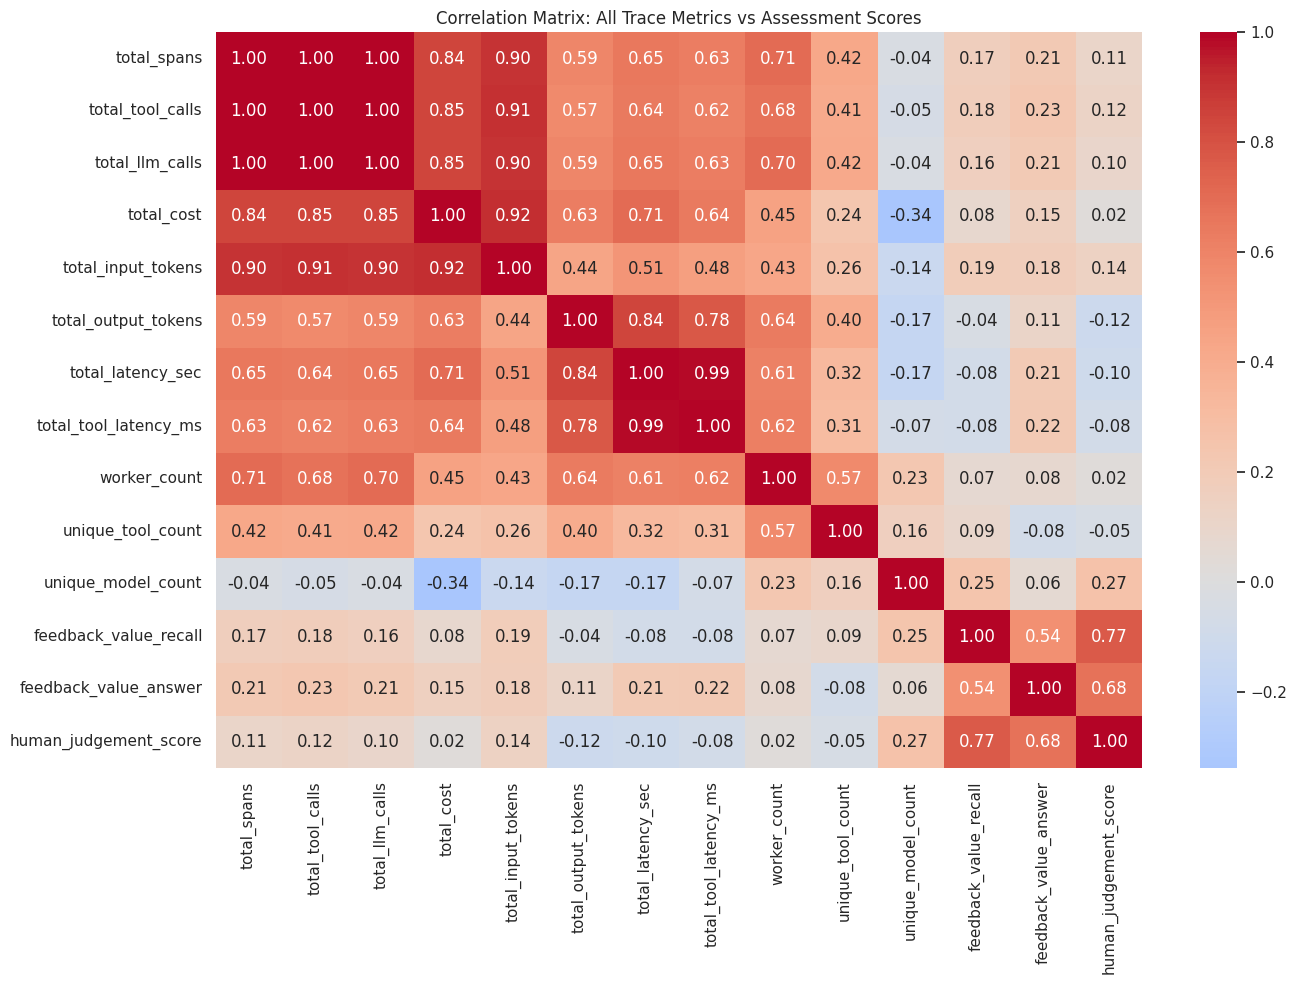

In [64]:
numeric_cols = ['total_spans', 'total_tool_calls', 'total_llm_calls', 'total_cost', 
                'total_input_tokens', 'total_output_tokens', 'total_latency_sec', 
                'total_tool_latency_ms', 'worker_count', 'unique_tool_count', 'unique_model_count',
                'feedback_value_recall', 'feedback_value_answer', 'human_judgement_score']

correlation_matrix = master_trace[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: All Trace Metrics vs Assessment Scores')
plt.tight_layout()
plt.show()

## 2. Cost vs All Assessment Scores (Multi-metric view)

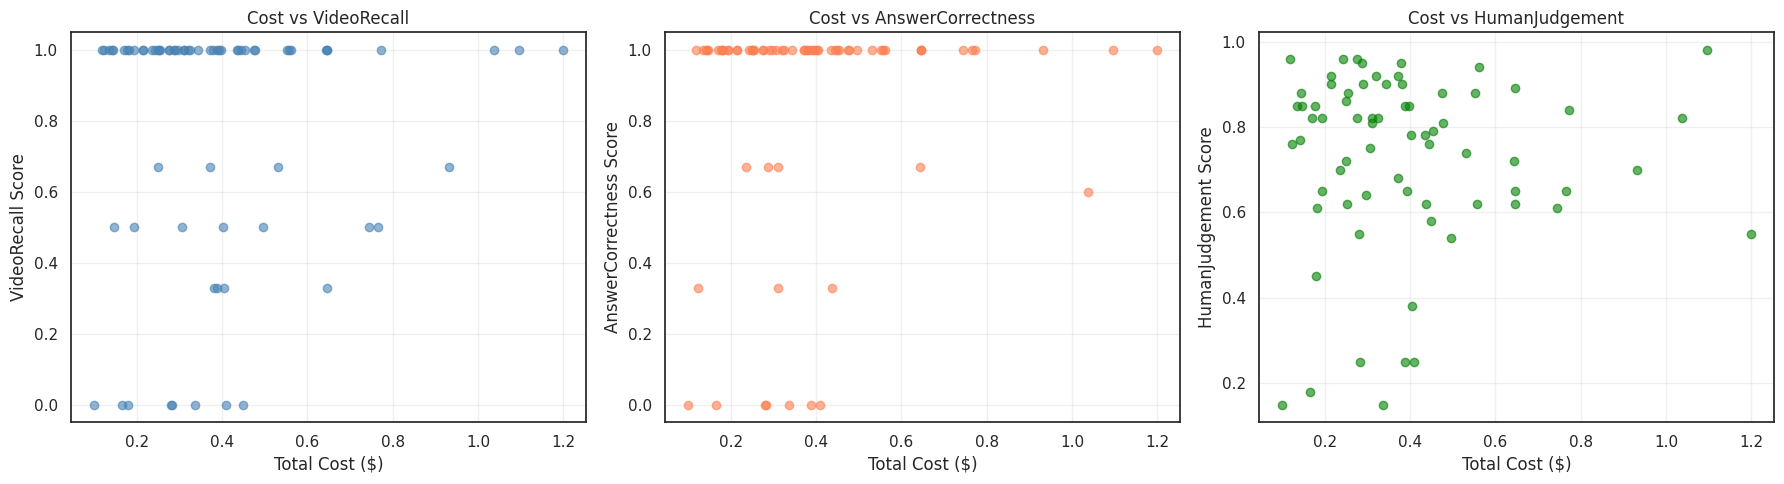

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(master_trace['total_cost'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Total Cost ($)')
axes[0].set_ylabel('VideoRecall Score')
axes[0].set_title('Cost vs VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(master_trace['total_cost'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[1].set_xlabel('Total Cost ($)')
axes[1].set_ylabel('AnswerCorrectness Score')
axes[1].set_title('Cost vs AnswerCorrectness')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(master_trace['total_cost'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[2].set_xlabel('Total Cost ($)')
axes[2].set_ylabel('HumanJudgement Score')
axes[2].set_title('Cost vs HumanJudgement')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Token Usage vs Assessment Scores

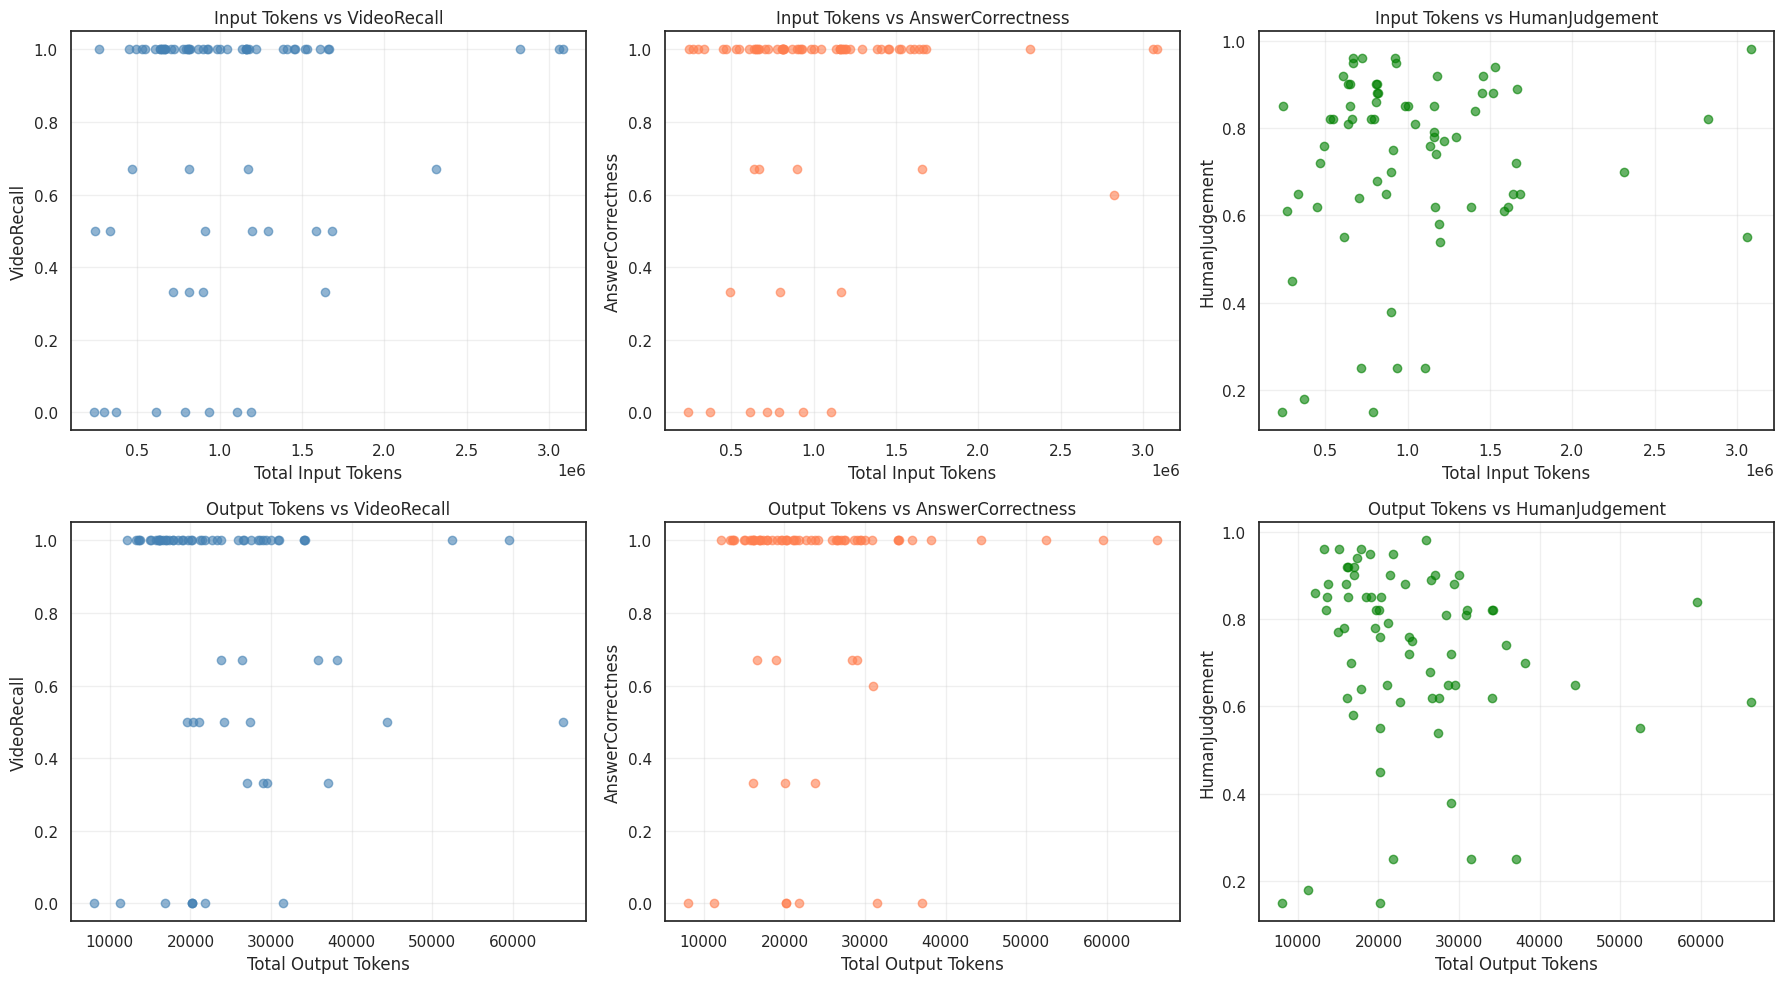

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(master_trace['total_input_tokens'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0, 0].set_xlabel('Total Input Tokens')
axes[0, 0].set_ylabel('VideoRecall')
axes[0, 0].set_title('Input Tokens vs VideoRecall')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(master_trace['total_input_tokens'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[0, 1].set_xlabel('Total Input Tokens')
axes[0, 1].set_ylabel('AnswerCorrectness')
axes[0, 1].set_title('Input Tokens vs AnswerCorrectness')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(master_trace['total_input_tokens'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[0, 2].set_xlabel('Total Input Tokens')
axes[0, 2].set_ylabel('HumanJudgement')
axes[0, 2].set_title('Input Tokens vs HumanJudgement')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(master_trace['total_output_tokens'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[1, 0].set_xlabel('Total Output Tokens')
axes[1, 0].set_ylabel('VideoRecall')
axes[1, 0].set_title('Output Tokens vs VideoRecall')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(master_trace['total_output_tokens'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[1, 1].set_xlabel('Total Output Tokens')
axes[1, 1].set_ylabel('AnswerCorrectness')
axes[1, 1].set_title('Output Tokens vs AnswerCorrectness')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(master_trace['total_output_tokens'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[1, 2].set_xlabel('Total Output Tokens')
axes[1, 2].set_ylabel('HumanJudgement')
axes[1, 2].set_title('Output Tokens vs HumanJudgement')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Latency vs Assessment Scores

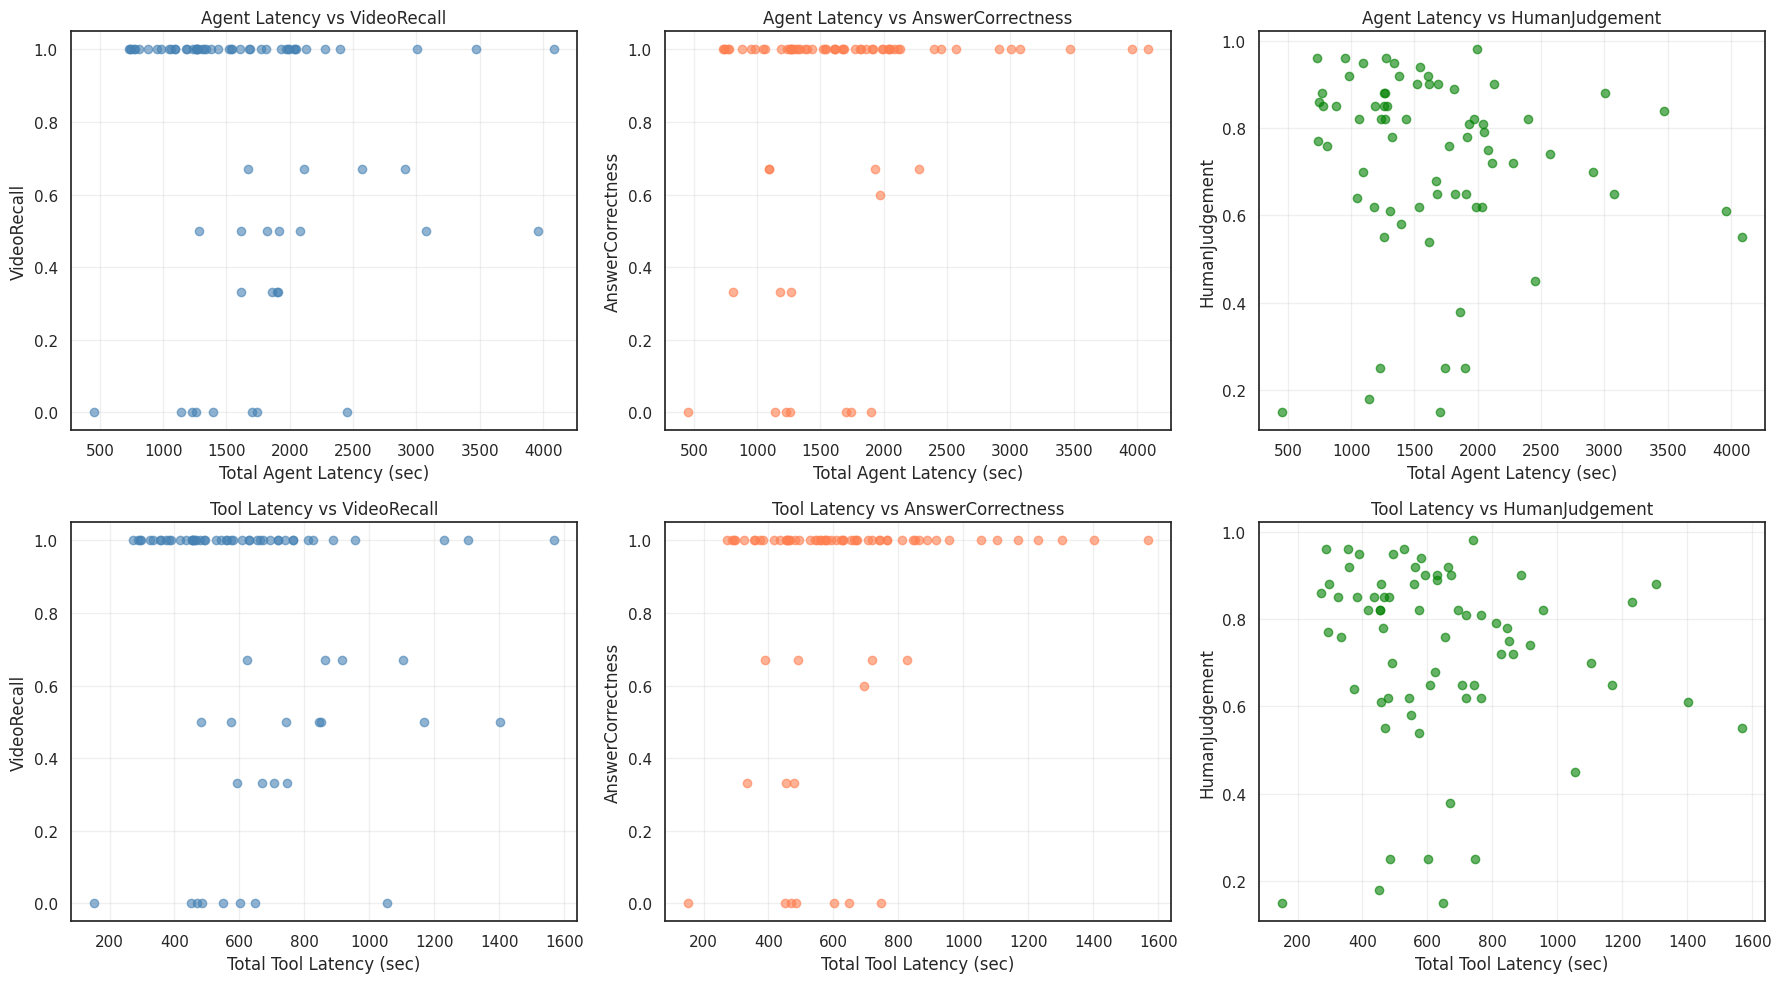

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(master_trace['total_latency_sec'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0, 0].set_xlabel('Total Agent Latency (sec)')
axes[0, 0].set_ylabel('VideoRecall')
axes[0, 0].set_title('Agent Latency vs VideoRecall')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(master_trace['total_latency_sec'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[0, 1].set_xlabel('Total Agent Latency (sec)')
axes[0, 1].set_ylabel('AnswerCorrectness')
axes[0, 1].set_title('Agent Latency vs AnswerCorrectness')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(master_trace['total_latency_sec'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[0, 2].set_xlabel('Total Agent Latency (sec)')
axes[0, 2].set_ylabel('HumanJudgement')
axes[0, 2].set_title('Agent Latency vs HumanJudgement')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(master_trace['total_tool_latency_ms'] / 1000, master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[1, 0].set_xlabel('Total Tool Latency (sec)')
axes[1, 0].set_ylabel('VideoRecall')
axes[1, 0].set_title('Tool Latency vs VideoRecall')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(master_trace['total_tool_latency_ms'] / 1000, master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[1, 1].set_xlabel('Total Tool Latency (sec)')
axes[1, 1].set_ylabel('AnswerCorrectness')
axes[1, 1].set_title('Tool Latency vs AnswerCorrectness')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(master_trace['total_tool_latency_ms'] / 1000, master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[1, 2].set_xlabel('Total Tool Latency (sec)')
axes[1, 2].set_ylabel('HumanJudgement')
axes[1, 2].set_title('Tool Latency vs HumanJudgement')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Worker Count & Tool Diversity vs Scores

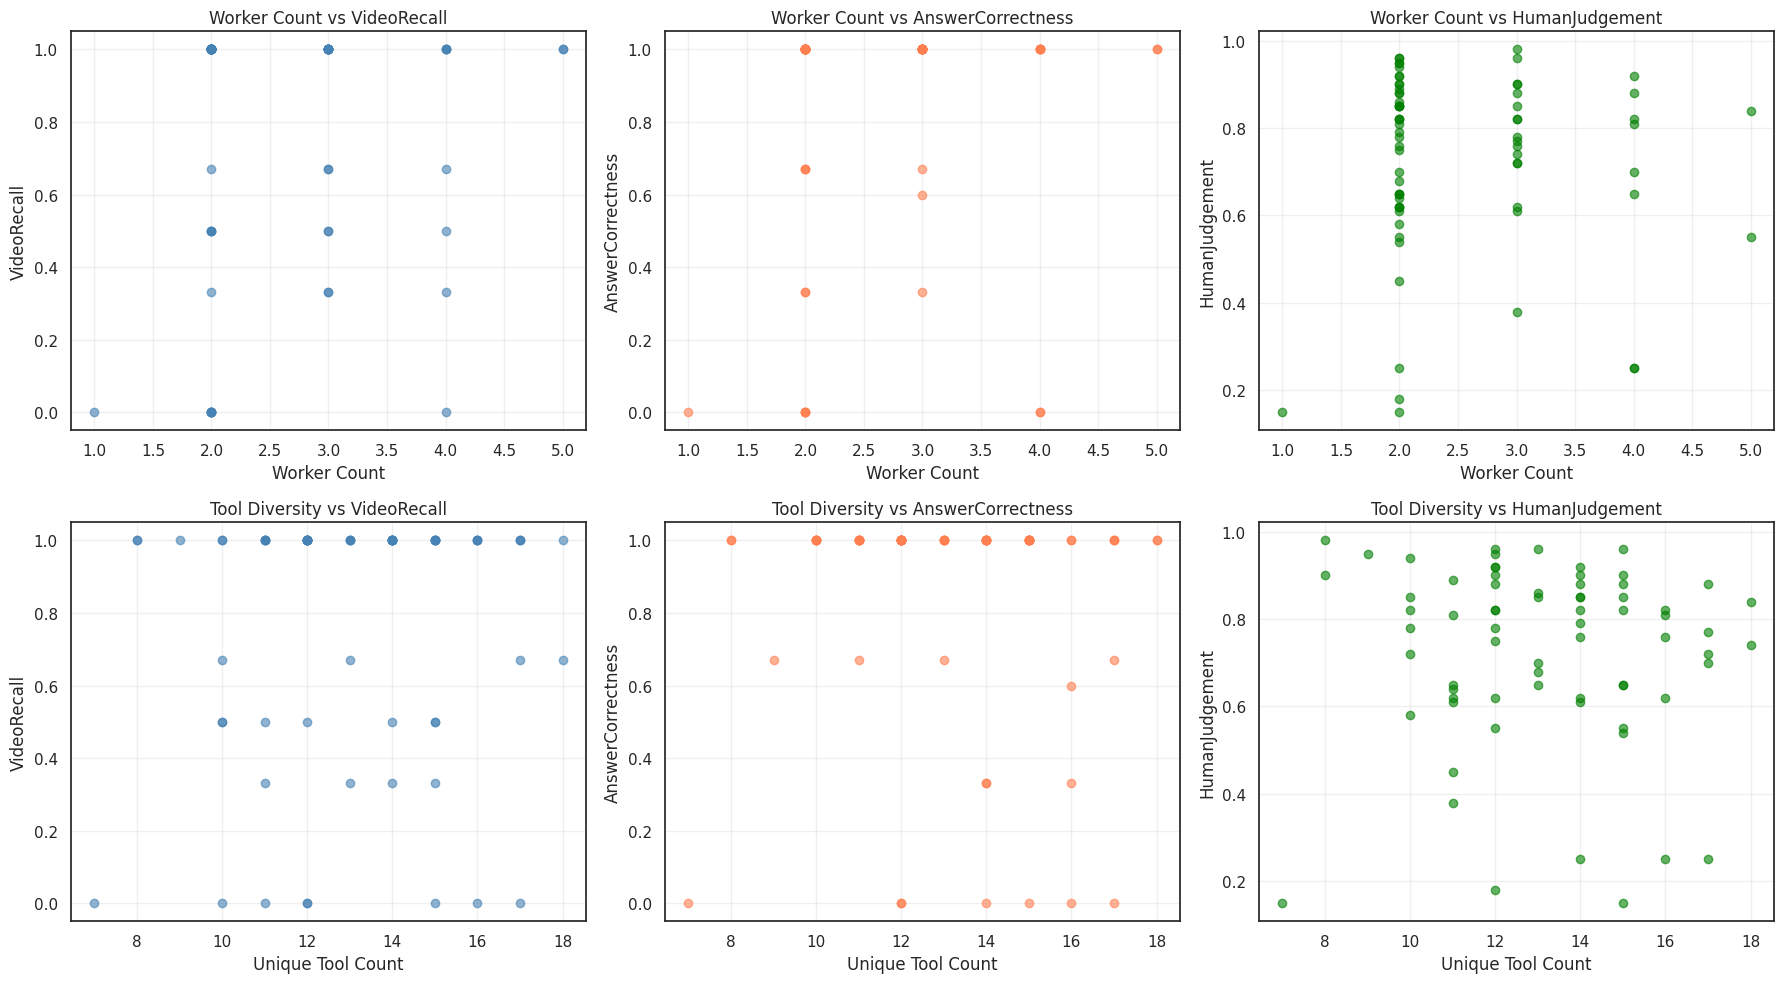

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(master_trace['worker_count'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0, 0].set_xlabel('Worker Count')
axes[0, 0].set_ylabel('VideoRecall')
axes[0, 0].set_title('Worker Count vs VideoRecall')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(master_trace['worker_count'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[0, 1].set_xlabel('Worker Count')
axes[0, 1].set_ylabel('AnswerCorrectness')
axes[0, 1].set_title('Worker Count vs AnswerCorrectness')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(master_trace['worker_count'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[0, 2].set_xlabel('Worker Count')
axes[0, 2].set_ylabel('HumanJudgement')
axes[0, 2].set_title('Worker Count vs HumanJudgement')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(master_trace['unique_tool_count'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[1, 0].set_xlabel('Unique Tool Count')
axes[1, 0].set_ylabel('VideoRecall')
axes[1, 0].set_title('Tool Diversity vs VideoRecall')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(master_trace['unique_tool_count'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[1, 1].set_xlabel('Unique Tool Count')
axes[1, 1].set_ylabel('AnswerCorrectness')
axes[1, 1].set_title('Tool Diversity vs AnswerCorrectness')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(master_trace['unique_tool_count'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[1, 2].set_xlabel('Unique Tool Count')
axes[1, 2].set_ylabel('HumanJudgement')
axes[1, 2].set_title('Tool Diversity vs HumanJudgement')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Diversity vs Scores

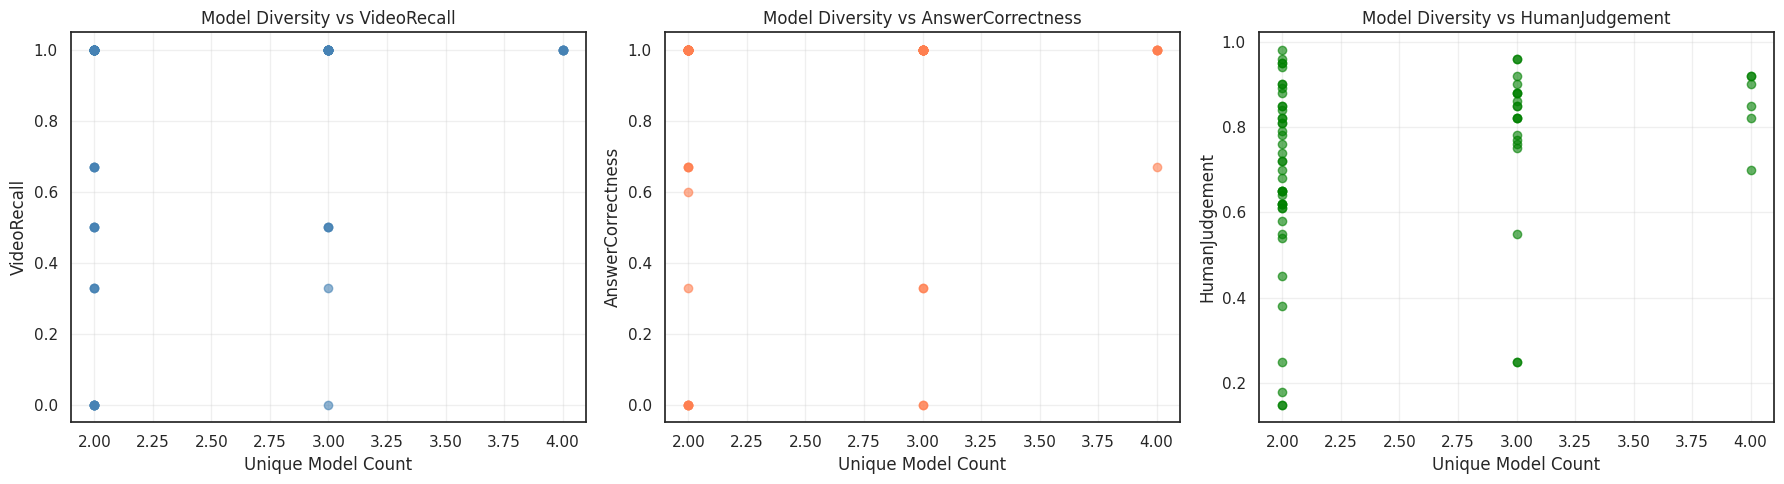

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(master_trace['unique_model_count'], master_trace['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Unique Model Count')
axes[0].set_ylabel('VideoRecall')
axes[0].set_title('Model Diversity vs VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(master_trace['unique_model_count'], master_trace['feedback_value_answer'], alpha=0.6, c='coral')
axes[1].set_xlabel('Unique Model Count')
axes[1].set_ylabel('AnswerCorrectness')
axes[1].set_title('Model Diversity vs AnswerCorrectness')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(master_trace['unique_model_count'], master_trace['human_judgement_score'], alpha=0.6, c='green')
axes[2].set_xlabel('Unique Model Count')
axes[2].set_ylabel('HumanJudgement')
axes[2].set_title('Model Diversity vs HumanJudgement')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Combination Impact on Scores

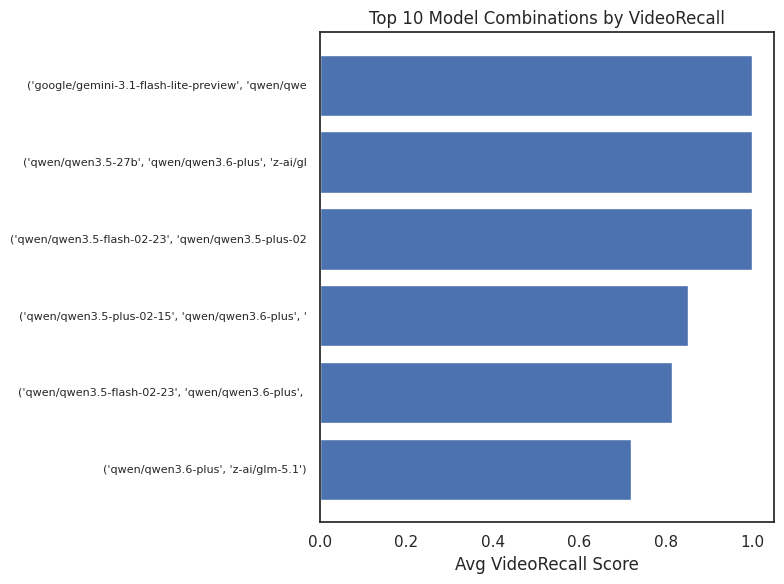

In [70]:
trace_models_used = df_llm.groupby('trace_id')['model_id'].apply(lambda x: tuple(sorted(set(x)))).reset_index()
trace_models_used.columns = ['trace_id', 'models_used']

trace_models_scores = trace_models_used.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
trace_models_scores = trace_models_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

model_combo_avg_recall = trace_models_scores.groupby('models_used')['feedback_value_recall'].mean().sort_values(ascending=False)
model_combo_avg_answer = trace_models_scores.groupby('models_used')['feedback_value_answer'].mean().sort_values(ascending=False)


top_10_recall = model_combo_avg_recall.head(10)

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_10_recall)), top_10_recall.values)
plt.yticks(range(len(top_10_recall)), [str(m)[:50] for m in top_10_recall.index], fontsize=8)
plt.xlabel('Avg VideoRecall Score')
plt.title('Top 10 Model Combinations by VideoRecall')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

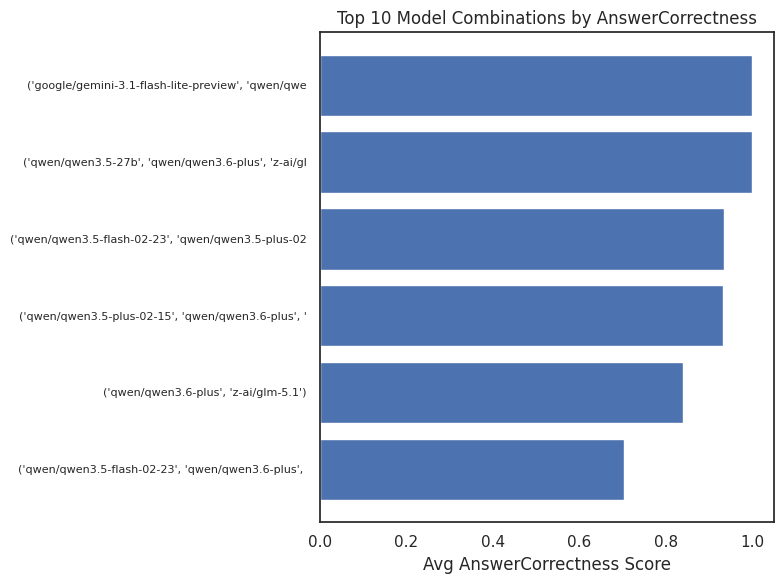

In [71]:
top_10_answer = model_combo_avg_answer.head(10)

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_10_answer)), top_10_answer.values)
plt.yticks(range(len(top_10_answer)), [str(m)[:50] for m in top_10_answer.index], fontsize=8)
plt.xlabel('Avg AnswerCorrectness Score')
plt.title('Top 10 Model Combinations by AnswerCorrectness')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Worker Agent Performance Heatmap

/tmp/ipykernel_3115219/3186648481.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).fillna(0)


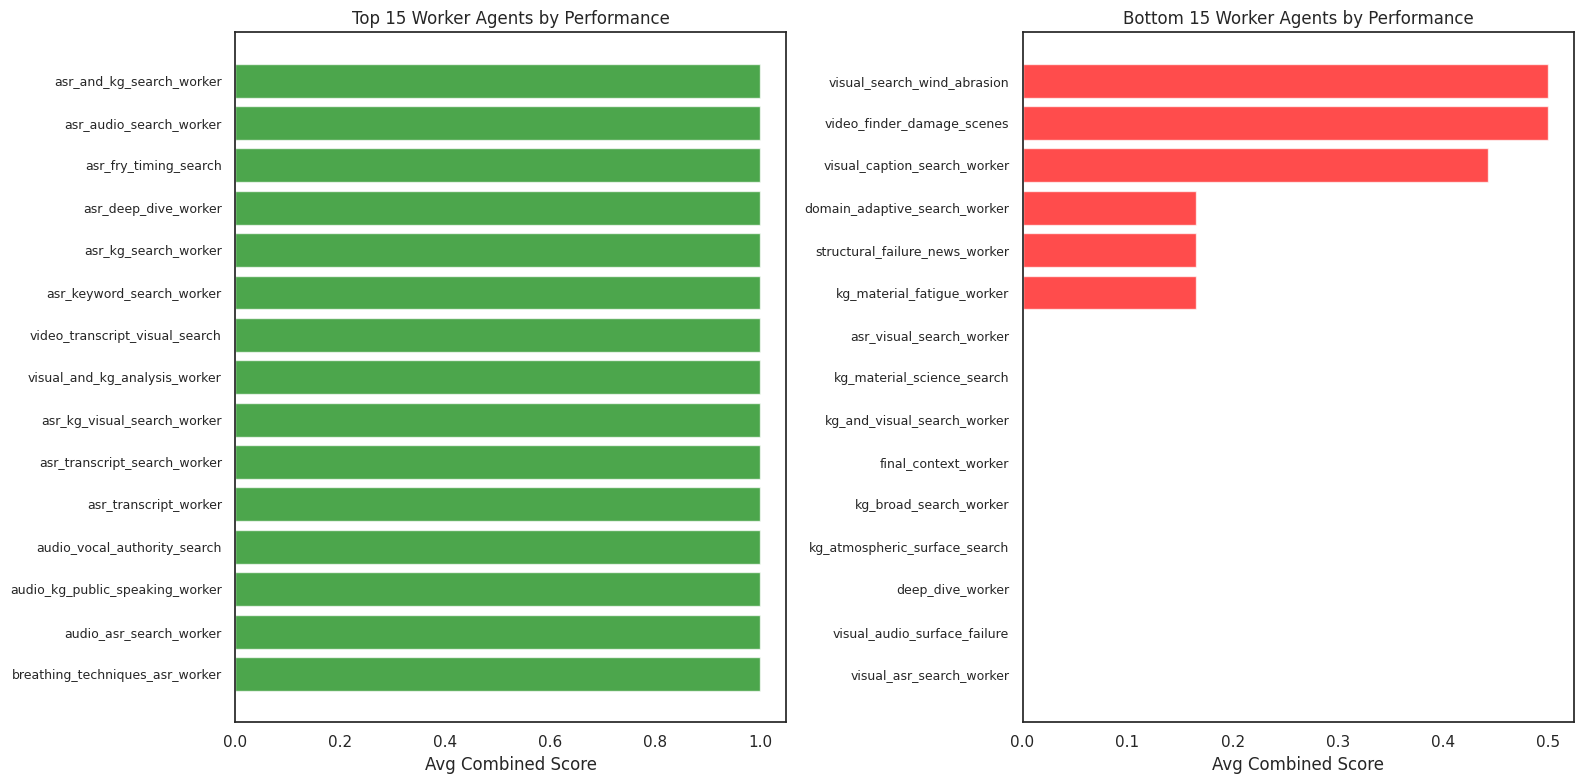

In [72]:
worker_recall_perf = df_worker_tool.merge(video_recall[['trace_id', 'feedback_value']], left_on='parent_trace_id', right_on='trace_id', how='left')
worker_answer_perf = df_worker_tool.merge(answer_correctness[['trace_id', 'feedback_value']], left_on='parent_trace_id', right_on='trace_id', how='left')

worker_avg_recall = worker_recall_perf.groupby('worker_agent_name')['feedback_value'].mean()
worker_avg_answer = worker_answer_perf.groupby('worker_agent_name')['feedback_value'].mean()

worker_perf_df = pd.DataFrame({
    'avg_recall': worker_avg_recall,
    'avg_answer': worker_avg_answer,
    'count': worker_recall_perf.groupby('worker_agent_name').size()
}).fillna(0)

worker_perf_df['avg_score'] = (worker_perf_df['avg_recall'] + worker_perf_df['avg_answer']) / 2
worker_perf_df = worker_perf_df.sort_values('avg_score', ascending=False)

top_15_workers = worker_perf_df.head(n=15)
bottom_15_workers = worker_perf_df.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(len(top_15_workers)), top_15_workers['avg_score'].values, color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_15_workers)))
axes[0].set_yticklabels(top_15_workers.index, fontsize=9)
axes[0].set_xlabel('Avg Combined Score')
axes[0].set_title('Top 15 Worker Agents by Performance')
axes[0].invert_yaxis()

axes[1].barh(range(len(bottom_15_workers)), bottom_15_workers['avg_score'].values, color='red', alpha=0.7)
axes[1].set_yticks(range(len(bottom_15_workers)))
axes[1].set_yticklabels(bottom_15_workers.index, fontsize=9)
axes[1].set_xlabel('Avg Combined Score')
axes[1].set_title('Bottom 15 Worker Agents by Performance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Tool Category Impact on Scores

In [73]:
def categorize_tool(tool_name):
    if 'kg.' in tool_name or 'triple_hybrid' in tool_name or 'search_' in tool_name:
        return 'KnowledgeGraph'
    elif 'get_audio' in tool_name or 'get_asr' in tool_name or 'audio' in tool_name.lower():
        return 'Audio/ASR'
    elif 'get_images' in tool_name or 'get_segments' in tool_name or 'visual' in tool_name.lower():
        return 'Visual'
    elif 'get_related_asr' in tool_name or 'get_adjacent' in tool_name:
        return 'ContextExpansion'
    elif 'get_video' in tool_name:
        return 'VideoMetadata'
    else:
        return 'Other'

ignore_tool_list_cat = [
    'get_member_information',
    'delegate_task_to_member',
    'get_available_worker_tools',
    'get_available_models',
    'spawn_and_run_worker'
]
df_tool_filtered = df_tool[~df_tool['tool_name'].isin(ignore_tool_list_cat)]

df_tool_filtered['tool_category'] = df_tool_filtered['tool_name'].apply(categorize_tool)

trace_tool_categories = df_tool_filtered.groupby('trace_id')['tool_category'].value_counts().unstack(fill_value=0)
trace_tool_categories = trace_tool_categories.reset_index()

trace_tool_cat_scores = trace_tool_categories.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
trace_tool_cat_scores = trace_tool_cat_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

trace_tool_cat_scores.head()

/tmp/ipykernel_3115219/2523081474.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tool_filtered['tool_category'] = df_tool_filtered['tool_name'].apply(categorize_tool)


,trace_id,Audio/ASR,ContextExpansion,KnowledgeGraph,Other,VideoMetadata,Visual,feedback_value_recall,feedback_value_answer
0,tr-01ee9f794325242fd70297e4d8ee62f1,2,12,9,1,0,4,0.0,0.0
1,tr-06dd73dbdc6cf4b6ab34302c84d458b9,3,0,9,1,0,7,0.33,0.0
2,tr-07b82ba9bae85eaefcc23fd665e5b0e9,2,27,4,1,0,5,0.33,1.0
3,tr-102ac03e8e568186b1e7daa5775b78ea,3,12,8,2,0,4,1.0,1.0
4,tr-1246f0338e5541a4dbfd6316d656ce4b,2,21,5,0,0,3,1.0,1.0


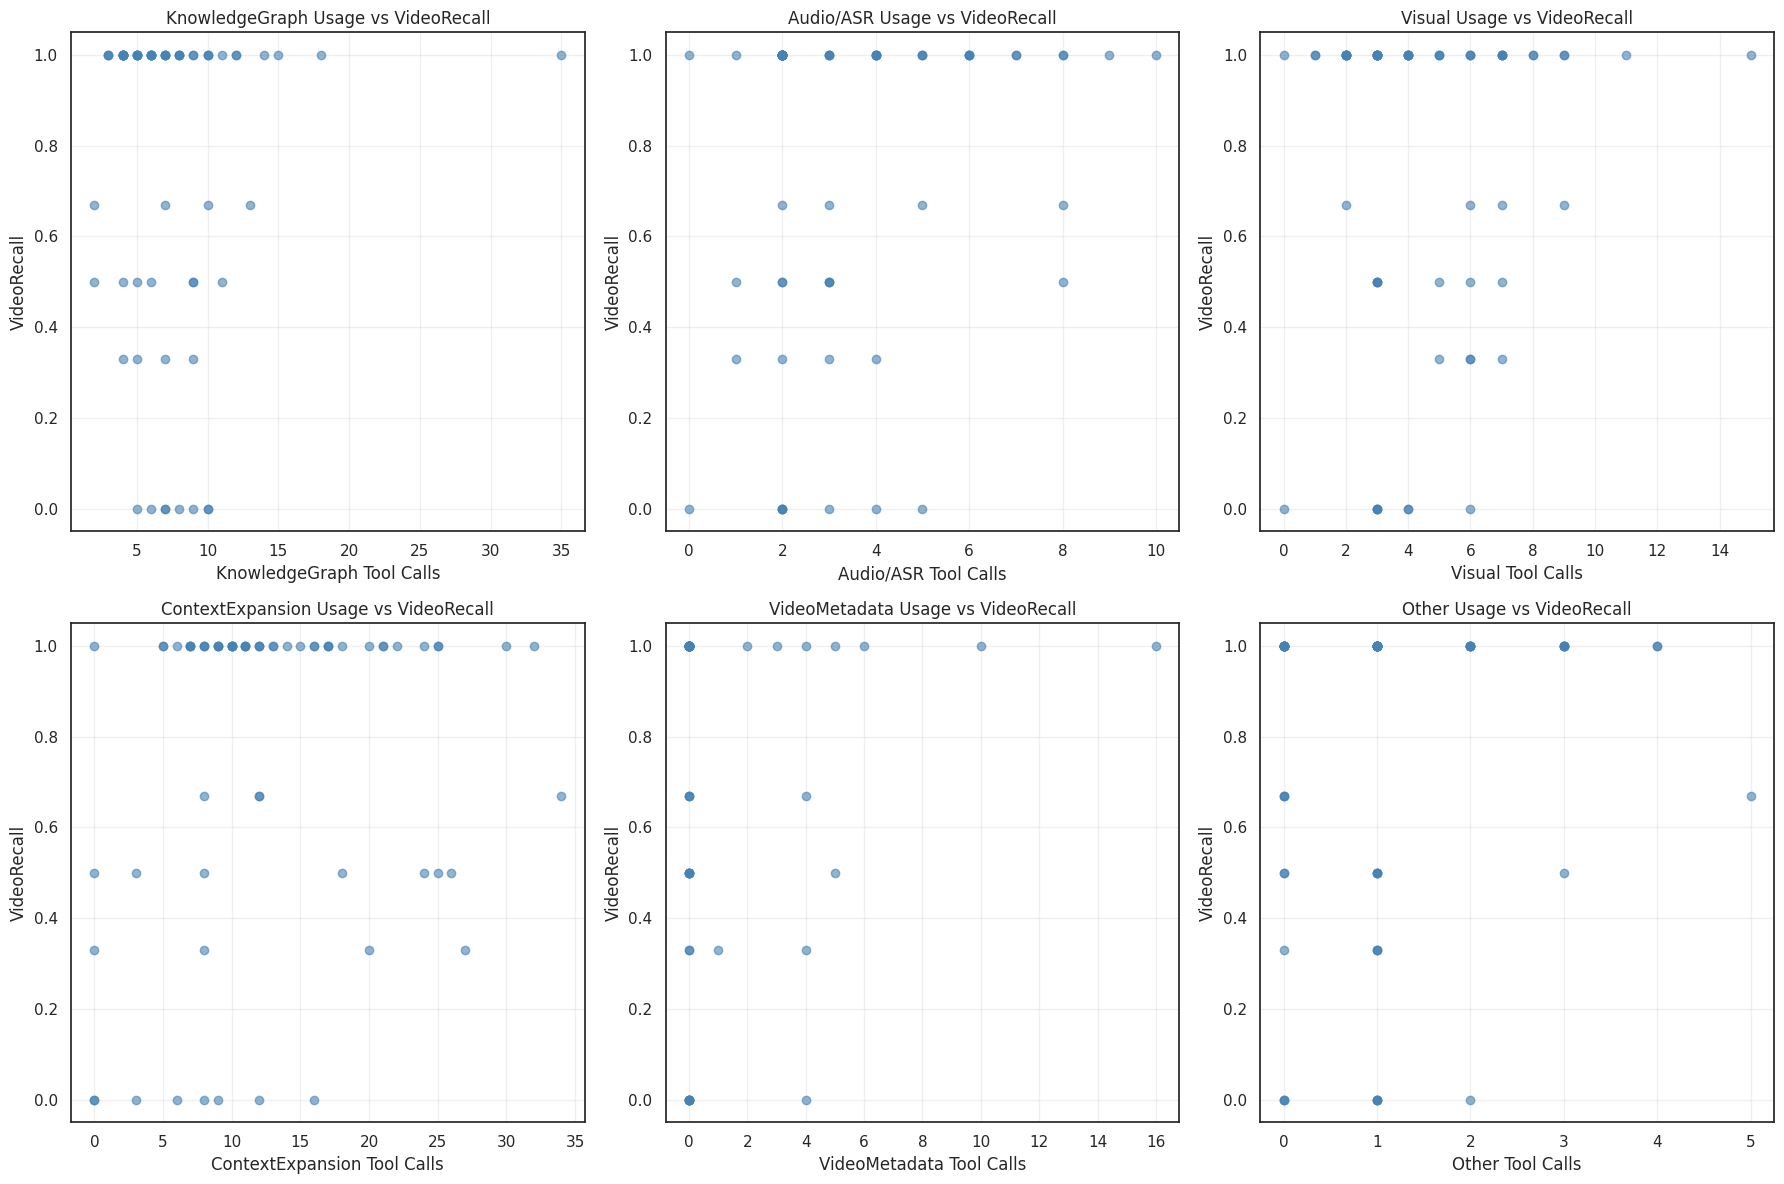

In [74]:
categories = ['KnowledgeGraph', 'Audio/ASR', 'Visual', 'ContextExpansion', 'VideoMetadata', 'Other']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, cat in enumerate(categories):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].scatter(trace_tool_cat_scores[cat], trace_tool_cat_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
    axes[row, col].set_xlabel(f'{cat} Tool Calls')
    axes[row, col].set_ylabel('VideoRecall')
    axes[row, col].set_title(f'{cat} Usage vs VideoRecall')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. High vs Low Performance Trace Patterns

In [75]:
high_perf_traces = master_trace[(master_trace['feedback_value_recall'] >= 0.7) & (master_trace['feedback_value_answer'] >= 0.8)]['trace_id']
low_perf_traces = master_trace[(master_trace['feedback_value_recall'] < 0.5) & (master_trace['feedback_value_answer'] < 0.6)]['trace_id']

print(f"High performance traces: {len(high_perf_traces)}")
print(f"Low performance traces: {len(low_perf_traces)}")

high_llm = df_llm[df_llm['trace_id'].isin(high_perf_traces)]
low_llm = df_llm[df_llm['trace_id'].isin(low_perf_traces)]

high_tool = df_tool_filtered[df_tool_filtered['trace_id'].isin(high_perf_traces)]
low_tool = df_tool_filtered[df_tool_filtered['trace_id'].isin(low_perf_traces)]

high_agent = df_agent[df_agent['trace_id'].isin(high_perf_traces)]
low_agent = df_agent[df_agent['trace_id'].isin(low_perf_traces)]

High performance traces: 39
Low performance traces: 7


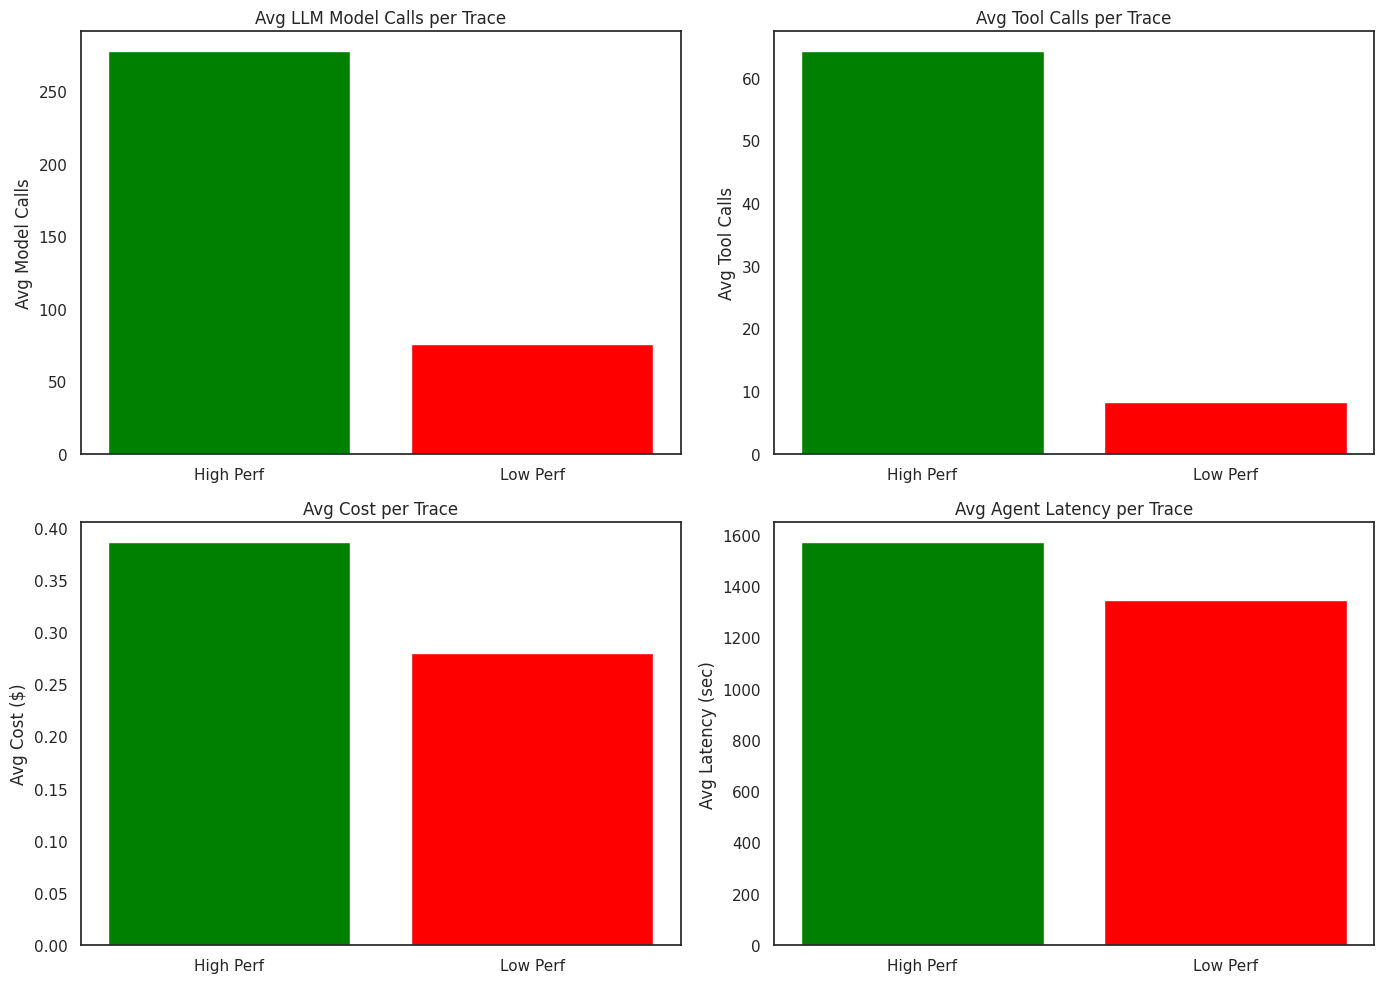

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(['High Perf', 'Low Perf'], 
              [high_llm['model_id'].value_counts().mean() if len(high_llm) > 0 else 0, 
               low_llm['model_id'].value_counts().mean() if len(low_llm) > 0 else 0],
              color=['green', 'red'])
axes[0, 0].set_ylabel('Avg Model Calls')
axes[0, 0].set_title('Avg LLM Model Calls per Trace')

axes[0, 1].bar(['High Perf', 'Low Perf'], 
              [high_tool['tool_name'].value_counts().mean() if len(high_tool) > 0 else 0, 
               low_tool['tool_name'].value_counts().mean() if len(low_tool) > 0 else 0],
              color=['green', 'red'])
axes[0, 1].set_ylabel('Avg Tool Calls')
axes[0, 1].set_title('Avg Tool Calls per Trace')

axes[1, 0].bar(['High Perf', 'Low Perf'], 
              [high_llm['cost'].sum() / len(high_perf_traces) if len(high_perf_traces) > 0 else 0, 
               low_llm['cost'].sum() / len(low_perf_traces) if len(low_perf_traces) > 0 else 0],
              color=['green', 'red'])
axes[1, 0].set_ylabel('Avg Cost ($)')
axes[1, 0].set_title('Avg Cost per Trace')

axes[1, 1].bar(['High Perf', 'Low Perf'], 
              [high_agent['latency_sec'].sum() / len(high_perf_traces) if len(high_perf_traces) > 0 else 0, 
               low_agent['latency_sec'].sum() / len(low_perf_traces) if len(low_perf_traces) > 0 else 0],
              color=['green', 'red'])
axes[1, 1].set_ylabel('Avg Latency (sec)')
axes[1, 1].set_title('Avg Agent Latency per Trace')

plt.tight_layout()
plt.show()

## 11. Tool Usage Pattern: High vs Low Recall Traces

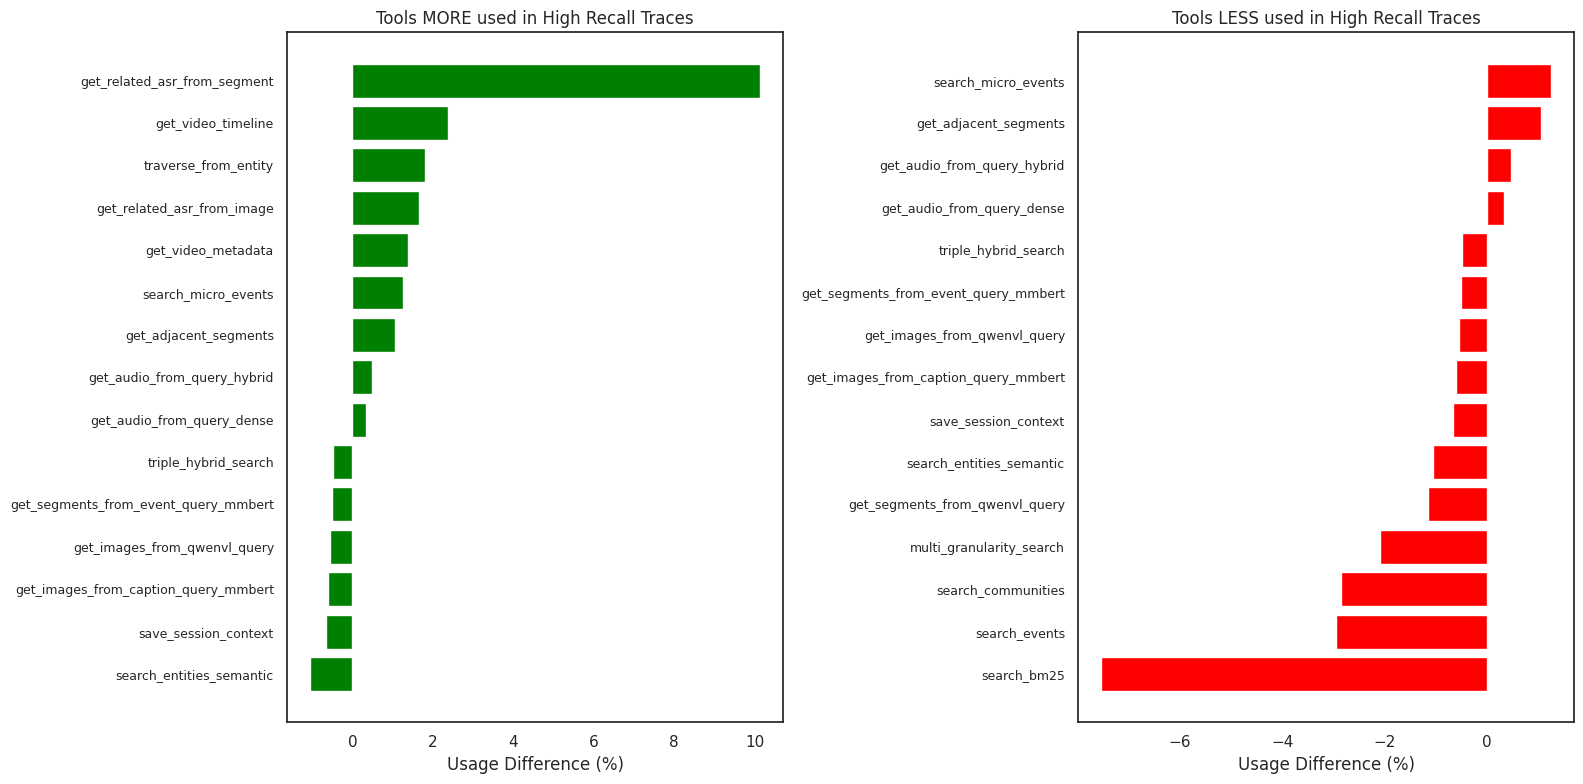

In [77]:
high_recall_tools = high_tool['tool_name'].value_counts(normalize=True) * 100
low_recall_tools = low_tool['tool_name'].value_counts(normalize=True) * 100

tool_usage_compare = pd.DataFrame({
    'High Recall (%)': high_recall_tools,
    'Low Recall (%)': low_recall_tools
}).fillna(0)

tool_usage_compare['diff'] = tool_usage_compare['High Recall (%)'] - tool_usage_compare['Low Recall (%)']
tool_usage_compare = tool_usage_compare.sort_values('diff', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_diff = tool_usage_compare.head(15)
axes[0].barh(range(len(top_diff)), top_diff['diff'].values, color='green' if top_diff['diff'].mean() > 0 else 'red')
axes[0].set_yticks(range(len(top_diff)))
axes[0].set_yticklabels(top_diff.index, fontsize=9)
axes[0].set_xlabel('Usage Difference (%)')
axes[0].set_title('Tools MORE used in High Recall Traces')
axes[0].invert_yaxis()

bottom_diff = tool_usage_compare.tail(15)
axes[1].barh(range(len(bottom_diff)), bottom_diff['diff'].values, color='red')
axes[1].set_yticks(range(len(bottom_diff)))
axes[1].set_yticklabels(bottom_diff.index, fontsize=9)
axes[1].set_xlabel('Usage Difference (%)')
axes[1].set_title('Tools LESS used in High Recall Traces')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 12. Worker Agent Type Distribution by Score Tier

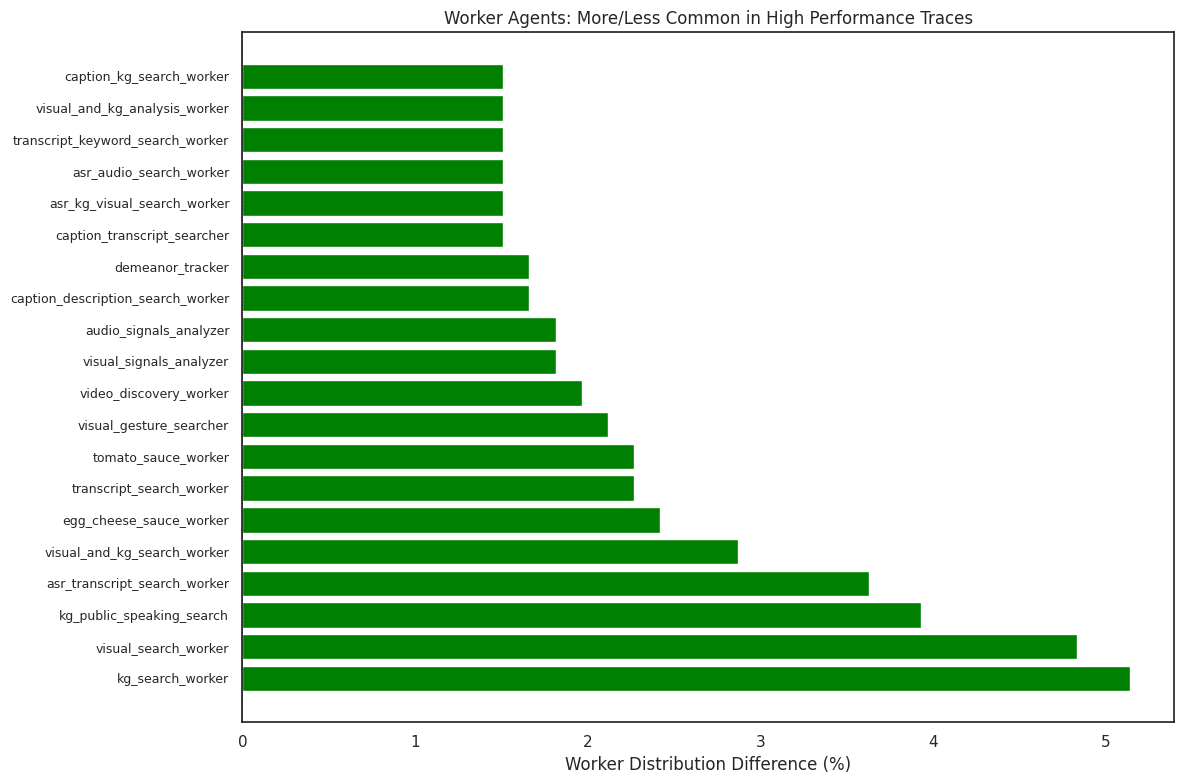

In [78]:
high_recall_workers = df_worker_tool[df_worker_tool['parent_trace_id'].isin(high_perf_traces)]['worker_agent_name'].value_counts(normalize=True) * 100
low_recall_workers = df_worker_tool[df_worker_tool['parent_trace_id'].isin(low_perf_traces)]['worker_agent_name'].value_counts(normalize=True) * 100

worker_dist_compare = pd.DataFrame({
    'High Perf (%)': high_recall_workers,
    'Low Perf (%)': low_recall_workers
}).fillna(0)

worker_dist_compare['diff'] = worker_dist_compare['High Perf (%)'] - worker_dist_compare['Low Perf (%)']
worker_dist_compare = worker_dist_compare.sort_values('diff', ascending=False)

plt.figure(figsize=(12, 8))
top_worker_diff = worker_dist_compare.head(20)
colors = ['green' if x > 0 else 'red' for x in top_worker_diff['diff'].values]
plt.barh(range(len(top_worker_diff)), top_worker_diff['diff'].values, color=colors)
plt.yticks(range(len(top_worker_diff)), top_worker_diff.index, fontsize=9)
plt.xlabel('Worker Distribution Difference (%)')
plt.title('Worker Agents: More/Less Common in High Performance Traces')
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## 13. LLM Model Performance Comparison

In [79]:
llm_trace_scores = df_llm.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
llm_trace_scores = llm_trace_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

model_perf = llm_trace_scores.groupby('model_id').agg({
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean',
    'cost': ['mean', 'sum'],
    'input_tokens': 'mean',
    'output_tokens': 'mean',
}).reset_index()

model_perf.columns = ['model_id', 'avg_recall', 'avg_answer', 'avg_cost', 'total_cost', 'avg_input_tokens', 'avg_output_tokens']

model_perf['avg_combined_score'] = (model_perf['avg_recall'] + model_perf['avg_answer']) / 2
model_perf = model_perf.sort_values('avg_combined_score', ascending=False)

model_perf

,model_id,avg_recall,avg_answer,avg_cost,total_cost,avg_input_tokens,avg_output_tokens,avg_combined_score
0,google/gemini-3.1-flash-lite-preview,1.0,1.0,0.002468,0.037019,9046.133333,137.600000,1.0
1,qwen/qwen3.5-27b,1.0,1.0,0.004746,0.109149,21300.521739,379.478261,1.0
3,qwen/qwen3.5-plus-02-15,0.895013,0.964987,0.007252,2.762835,27384.133858,405.112861,0.93
2,qwen/qwen3.5-flash-02-23,0.911187,0.835576,0.001746,0.485472,25046.942446,454.812950,0.873381
5,z-ai/glm-5.1,0.783625,0.850771,0.015417,5.997242,13344.128535,869.889460,0.817198
4,qwen/qwen3.6-plus,0.761269,0.859127,0.010004,18.217354,27273.018122,584.773202,0.810198


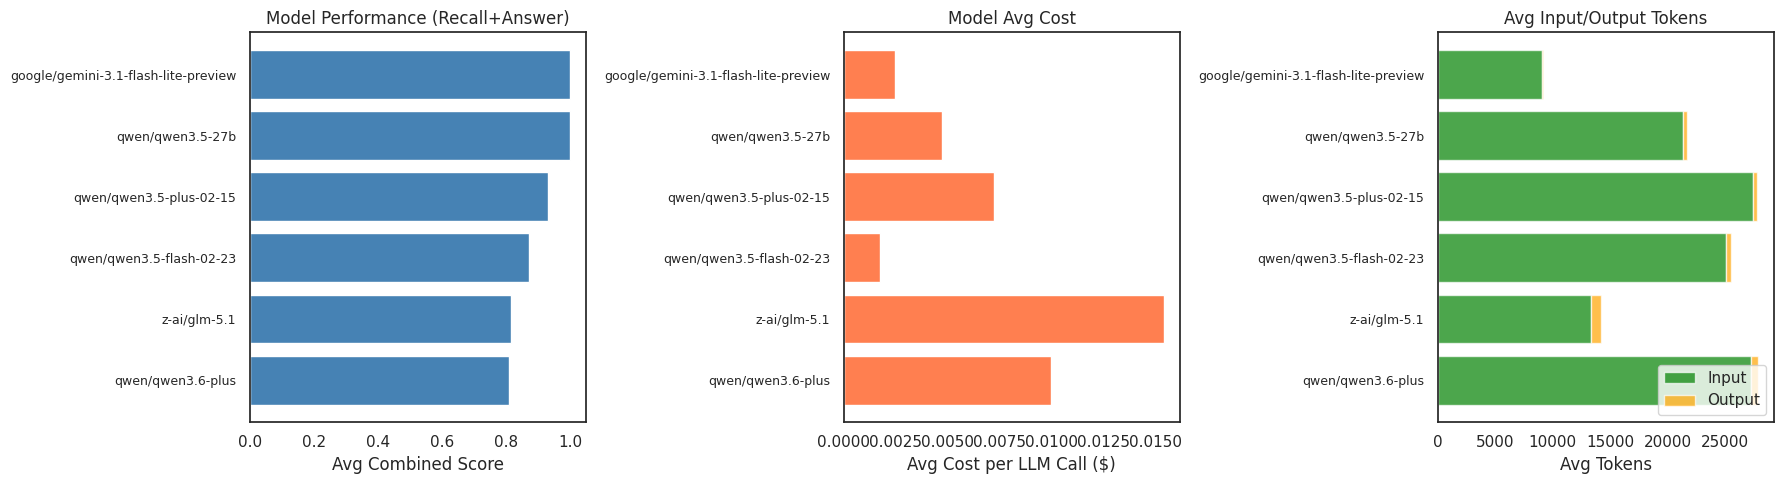

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(range(len(model_perf)), model_perf['avg_combined_score'].values, color='steelblue')
axes[0].set_yticks(range(len(model_perf)))
axes[0].set_yticklabels(model_perf['model_id'], fontsize=9)
axes[0].set_xlabel('Avg Combined Score')
axes[0].set_title('Model Performance (Recall+Answer)')
axes[0].invert_yaxis()

axes[1].barh(range(len(model_perf)), model_perf['avg_cost'].values, color='coral')
axes[1].set_yticks(range(len(model_perf)))
axes[1].set_yticklabels(model_perf['model_id'], fontsize=9)
axes[1].set_xlabel('Avg Cost per LLM Call ($)')
axes[1].set_title('Model Avg Cost')
axes[1].invert_yaxis()

axes[2].barh(range(len(model_perf)), model_perf['avg_input_tokens'].values, color='green', alpha=0.7)
axes[2].barh(range(len(model_perf)), model_perf['avg_output_tokens'].values, color='orange', alpha=0.7, left=model_perf['avg_input_tokens'].values)
axes[2].set_yticks(range(len(model_perf)))
axes[2].set_yticklabels(model_perf['model_id'], fontsize=9)
axes[2].set_xlabel('Avg Tokens')
axes[2].set_title('Avg Input/Output Tokens')
axes[2].legend(['Input', 'Output'], loc='lower right')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 14. Cost Efficiency: Performance per Dollar

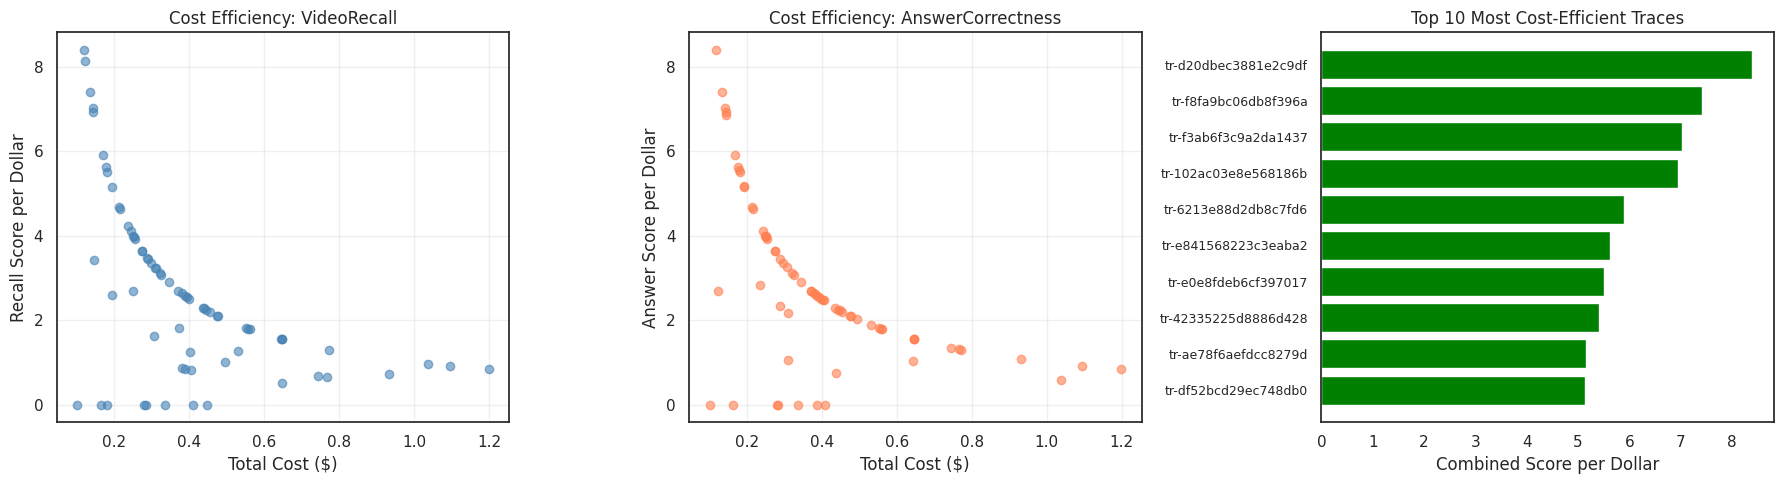

In [81]:
master_trace['cost_efficiency_recall'] = master_trace['feedback_value_recall'] / master_trace['total_cost'].replace(0, 0.0001)
master_trace['cost_efficiency_answer'] = master_trace['feedback_value_answer'] / master_trace['total_cost'].replace(0, 0.0001)
master_trace['cost_efficiency_combined'] = (master_trace['feedback_value_recall'] + master_trace['feedback_value_answer']) / (2 * master_trace['total_cost'].replace(0, 0.0001))

efficiency_sorted = master_trace.sort_values('cost_efficiency_combined', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(master_trace['total_cost'], master_trace['cost_efficiency_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Total Cost ($)')
axes[0].set_ylabel('Recall Score per Dollar')
axes[0].set_title('Cost Efficiency: VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(master_trace['total_cost'], master_trace['cost_efficiency_answer'], alpha=0.6, c='coral')
axes[1].set_xlabel('Total Cost ($)')
axes[1].set_ylabel('Answer Score per Dollar')
axes[1].set_title('Cost Efficiency: AnswerCorrectness')
axes[1].grid(True, alpha=0.3)

top_efficiency = efficiency_sorted.head(10)
axes[2].barh(range(len(top_efficiency)), top_efficiency['cost_efficiency_combined'].values, color='green')
axes[2].set_yticks(range(len(top_efficiency)))
axes[2].set_yticklabels([tid[:20] for tid in top_efficiency['trace_id'].values], fontsize=9)
axes[2].set_xlabel('Combined Score per Dollar')
axes[2].set_title('Top 10 Most Cost-Efficient Traces')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 15. Score Distribution by Metric Combinations

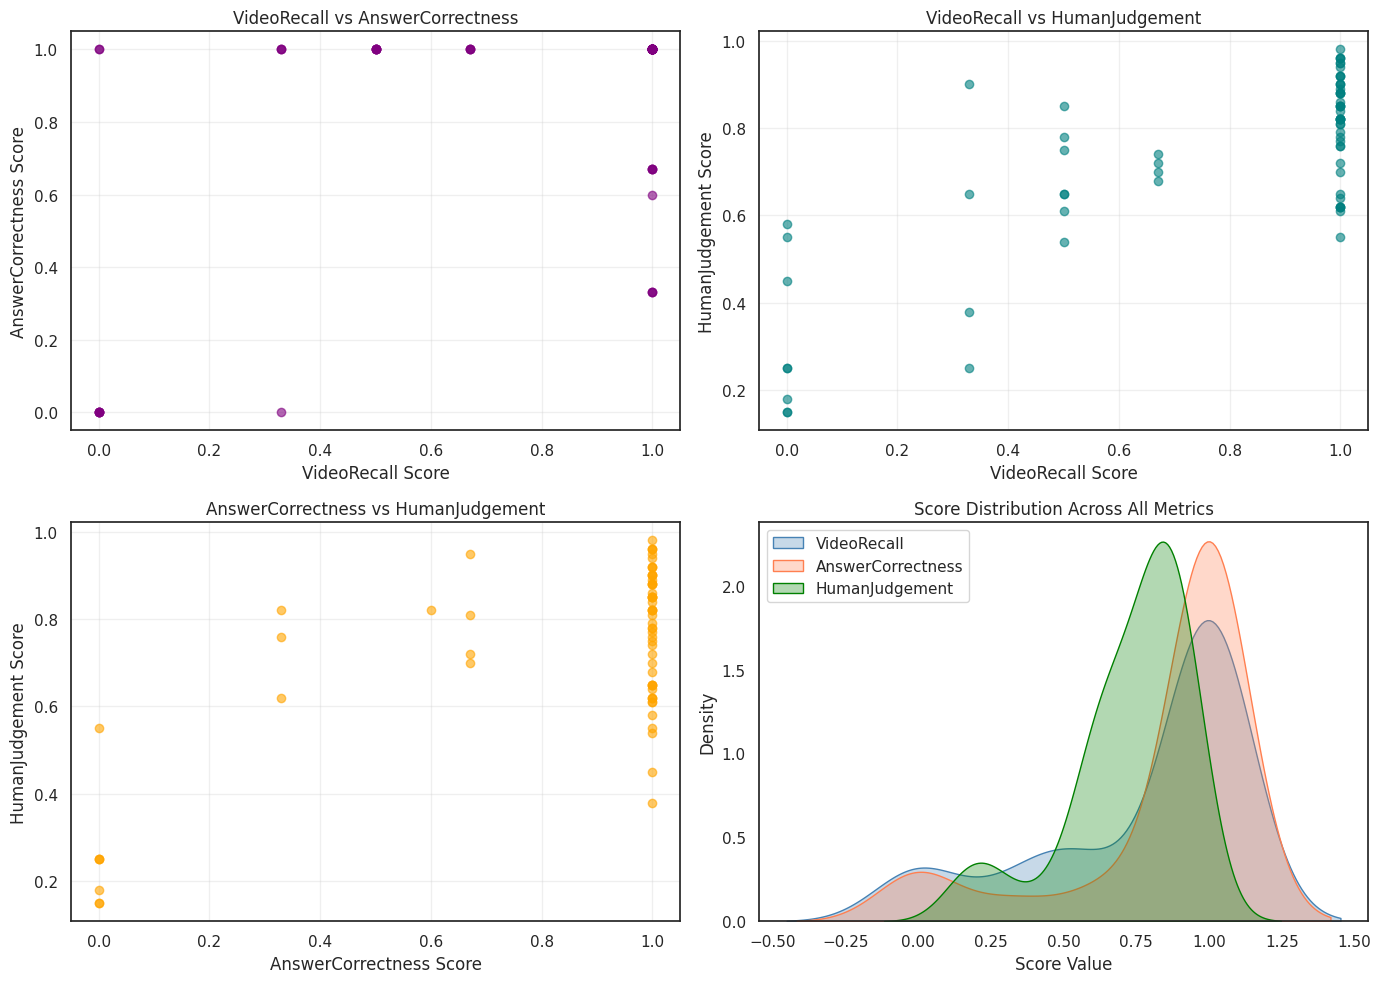

In [82]:
score_cols = ['feedback_value_recall', 'feedback_value_answer', 'human_judgement_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(master_trace['feedback_value_recall'], master_trace['feedback_value_answer'], alpha=0.6, c='purple')
axes[0, 0].set_xlabel('VideoRecall Score')
axes[0, 0].set_ylabel('AnswerCorrectness Score')
axes[0, 0].set_title('VideoRecall vs AnswerCorrectness')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(master_trace['feedback_value_recall'], master_trace['human_judgement_score'], alpha=0.6, c='teal')
axes[0, 1].set_xlabel('VideoRecall Score')
axes[0, 1].set_ylabel('HumanJudgement Score')
axes[0, 1].set_title('VideoRecall vs HumanJudgement')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(master_trace['feedback_value_answer'], master_trace['human_judgement_score'], alpha=0.6, c='orange')
axes[1, 0].set_xlabel('AnswerCorrectness Score')
axes[1, 0].set_ylabel('HumanJudgement Score')
axes[1, 0].set_title('AnswerCorrectness vs HumanJudgement')
axes[1, 0].grid(True, alpha=0.3)

sns.kdeplot(master_trace['feedback_value_recall'].dropna(), ax=axes[1, 1], label='VideoRecall', color='steelblue', fill=True, alpha=0.3)
sns.kdeplot(master_trace['feedback_value_answer'].dropna(), ax=axes[1, 1], label='AnswerCorrectness', color='coral', fill=True, alpha=0.3)
sns.kdeplot(master_trace['human_judgement_score'].dropna(), ax=axes[1, 1], label='HumanJudgement', color='green', fill=True, alpha=0.3)
axes[1, 1].set_xlabel('Score Value')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Score Distribution Across All Metrics')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# In-Depth Analysis from Trace Analysis JSON
Analysis based on additional fields extracted from trace_analysis_results.json

## 17. Execution Duration Analysis

In [83]:
df_trace_general['execution_duration_sec'].describe()

count      70.000000
mean      653.693514
std       272.914237
min       178.419000
25%       480.539500
50%       624.125500
75%       757.738250
max      1586.734000
Name: execution_duration_sec, dtype: float64

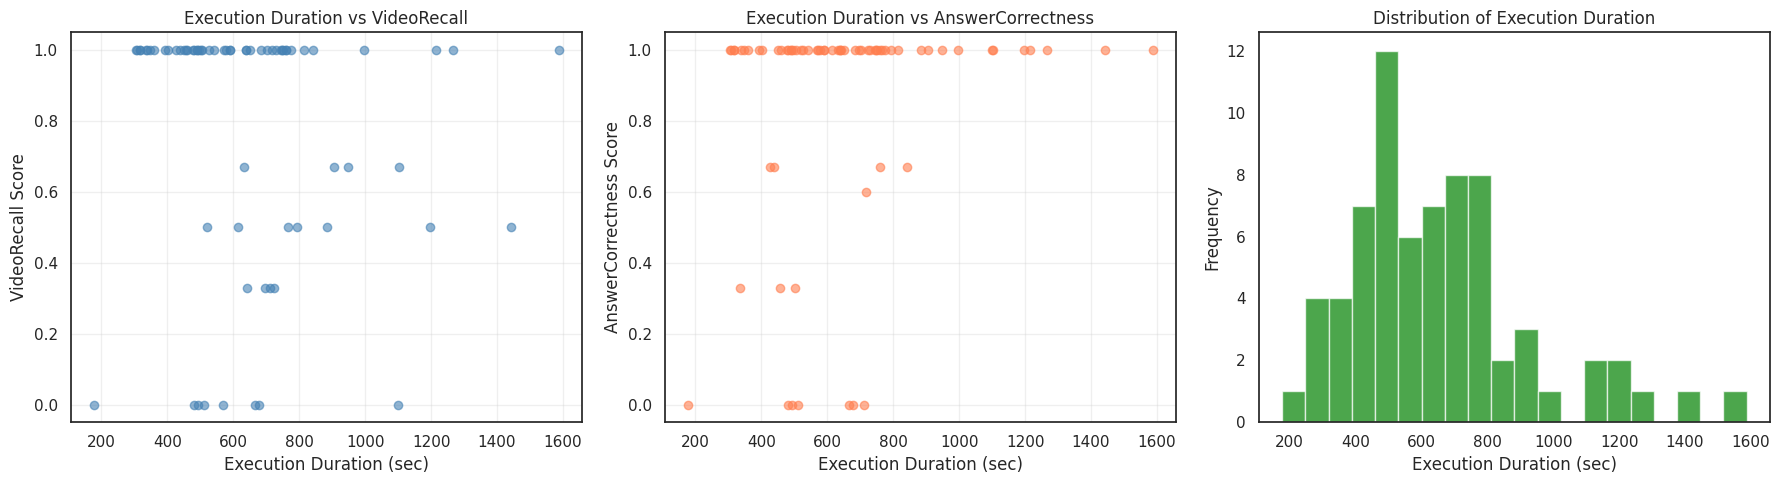

In [84]:
trace_general_scores = df_trace_general.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
trace_general_scores = trace_general_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(trace_general_scores['execution_duration_sec'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Execution Duration (sec)')
axes[0].set_ylabel('VideoRecall Score')
axes[0].set_title('Execution Duration vs VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(trace_general_scores['execution_duration_sec'], trace_general_scores['feedback_value_answer'], alpha=0.6, c='coral')
axes[1].set_xlabel('Execution Duration (sec)')
axes[1].set_ylabel('AnswerCorrectness Score')
axes[1].set_title('Execution Duration vs AnswerCorrectness')
axes[1].grid(True, alpha=0.3)

axes[2].hist(trace_general_scores['execution_duration_sec'], bins=20, color='green', alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Execution Duration (sec)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Execution Duration')

plt.tight_layout()
plt.show()

## 18. Potential Savings Analysis

In [85]:
print("Potential Savings Statistics:")
print(f"  Mean potential savings: {df_trace_general['potential_savings'].mean():.2f} spans")
print(f"  Mean potential savings %: {df_trace_general['potential_savings_pct'].mean():.2f}%")
print(f"  Max potential savings: {df_trace_general['potential_savings'].max()} spans")
print(f"  Max potential savings %: {df_trace_general['potential_savings_pct'].max():.2f}%")

Potential Savings Statistics:
  Mean potential savings: 77.60 spans
  Mean potential savings %: 92.99%
  Max potential savings: 202 spans
  Max potential savings %: 97.58%


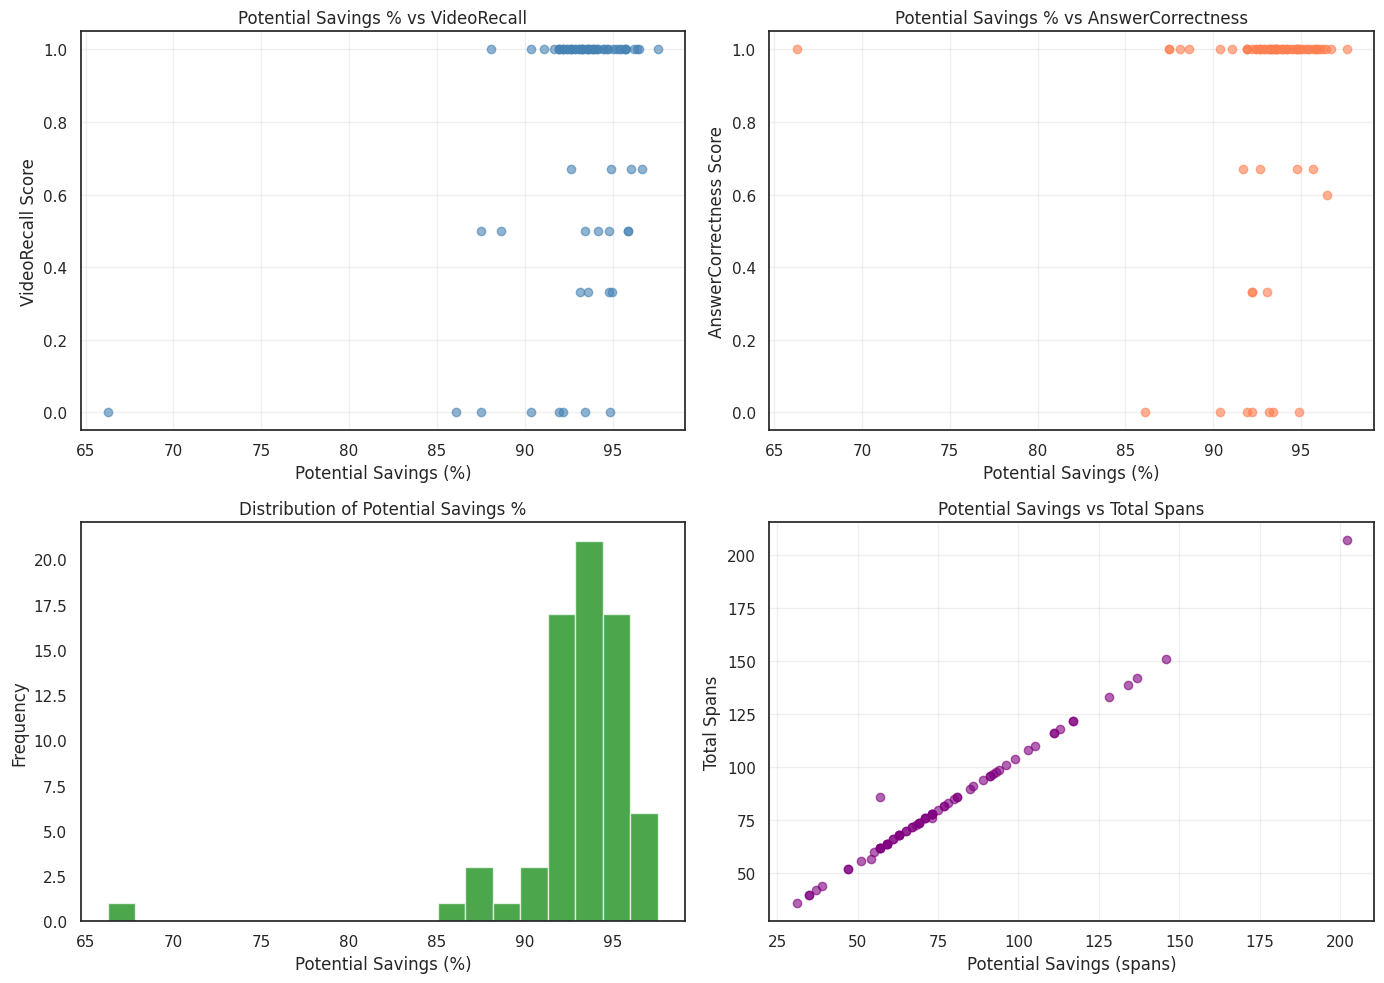

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(trace_general_scores['potential_savings_pct'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0, 0].set_xlabel('Potential Savings (%)')
axes[0, 0].set_ylabel('VideoRecall Score')
axes[0, 0].set_title('Potential Savings % vs VideoRecall')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(trace_general_scores['potential_savings_pct'], trace_general_scores['feedback_value_answer'], alpha=0.6, c='coral')
axes[0, 1].set_xlabel('Potential Savings (%)')
axes[0, 1].set_ylabel('AnswerCorrectness Score')
axes[0, 1].set_title('Potential Savings % vs AnswerCorrectness')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(trace_general_scores['potential_savings_pct'], bins=20, color='green', alpha=0.7, edgecolor='white')
axes[1, 0].set_xlabel('Potential Savings (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Potential Savings %')

axes[1, 1].scatter(trace_general_scores['potential_savings'], trace_general_scores['total_spans'], alpha=0.6, c='purple')
axes[1, 1].set_xlabel('Potential Savings (spans)')
axes[1, 1].set_ylabel('Total Spans')
axes[1, 1].set_title('Potential Savings vs Total Spans')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Video Match Analysis

In [87]:
video_match_stats = df_trace_general['video_match'].value_counts()
print("Video Match Statistics:")
print(f"  Matched: {video_match_stats.get(True, 0)} traces")
print(f"  Not Matched: {video_match_stats.get(False, 0)} traces")
print(f"  Match Rate: {video_match_stats.get(True, 0) / len(df_trace_general) * 100:.2f}%")

Video Match Statistics:
  Matched: 70 traces
  Not Matched: 0 traces
  Match Rate: 100.00%


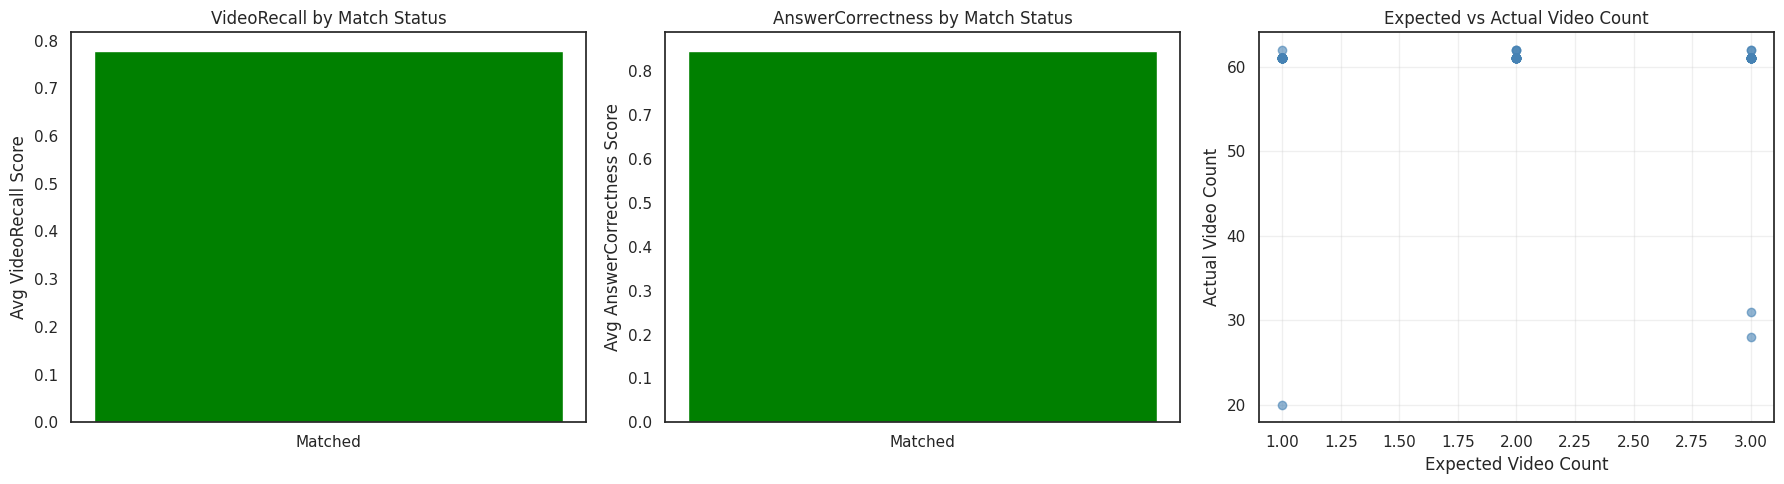

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matched = trace_general_scores[trace_general_scores['video_match'] == True]
not_matched = trace_general_scores[trace_general_scores['video_match'] == False]

axes[0].bar(['Matched', 'Not Matched'], [matched['feedback_value_recall'].mean(), not_matched['feedback_value_recall'].mean()], color=['green', 'red'])
axes[0].set_ylabel('Avg VideoRecall Score')
axes[0].set_title('VideoRecall by Match Status')

axes[1].bar(['Matched', 'Not Matched'], [matched['feedback_value_answer'].mean(), not_matched['feedback_value_answer'].mean()], color=['green', 'red'])
axes[1].set_ylabel('Avg AnswerCorrectness Score')
axes[1].set_title('AnswerCorrectness by Match Status')

axes[2].scatter(trace_general_scores['expected_video_count'], trace_general_scores['actual_video_count'], alpha=0.6, c='steelblue')
axes[2].set_xlabel('Expected Video Count')
axes[2].set_ylabel('Actual Video Count')
axes[2].set_title('Expected vs Actual Video Count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Per-Agent Metrics Analysis

In [89]:
df_trace_agent_metrics.head(10)

,trace_id,agent_name,tool_calls,llm_calls,tools_used,unique_tools_used
0,tr-2b35f46018dd98383e97c207cea057a2,VideoDeepSearch,2,3,"[get_member_information, delegate_task_to_member]",2
1,tr-2b35f46018dd98383e97c207cea057a2,Orchestrator,5,6,"[get_available_worker_tools, get_available_mod...",3
2,tr-2b35f46018dd98383e97c207cea057a2,video_discovery_worker,8,9,"[triple_hybrid_search, search_bm25, search_ent...",6
3,tr-2b35f46018dd98383e97c207cea057a2,visual_indicators_worker,9,10,"[get_images_from_qwenvl_query, get_images_from...",6
4,tr-2b35f46018dd98383e97c207cea057a2,audio_alerts_worker,10,11,"[get_audio_from_query_hybrid, get_audio_from_q...",4
5,tr-c59695308af3dad1c0246b3d474fd588,VideoDeepSearch,1,2,[delegate_task_to_member],1
6,tr-c59695308af3dad1c0246b3d474fd588,Orchestrator,4,5,"[get_available_worker_tools, get_available_mod...",3
7,tr-c59695308af3dad1c0246b3d474fd588,caption_asr_search_worker,8,10,"[get_audio_from_query_hybrid, get_audio_from_q...",5
8,tr-c59695308af3dad1c0246b3d474fd588,visual_kg_search_worker,11,12,"[get_segments_from_qwenvl_query, get_images_fr...",8
9,tr-26f3f4126a6ef4f29783ddd36c19bfe8,VideoDeepSearch,2,3,"[get_member_information, delegate_task_to_member]",2


In [90]:
agent_metrics_scores = df_trace_agent_metrics.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
agent_metrics_scores = agent_metrics_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

agent_avg_metrics = agent_metrics_scores.groupby('agent_name').agg({
    'tool_calls': 'mean',
    'llm_calls': 'mean',
    'unique_tools_used': 'mean',
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean'
}).reset_index()

agent_avg_metrics['combined_score'] = (agent_avg_metrics['feedback_value_recall'] + agent_avg_metrics['feedback_value_answer']) / 2
agent_avg_metrics = agent_avg_metrics.sort_values('combined_score', ascending=False)

agent_avg_metrics.head(10)

,agent_name,tool_calls,llm_calls,unique_tools_used,feedback_value_recall,feedback_value_answer,combined_score
68,kg_transcript_search_worker,11.0,12.0,8.0,1.0,1.0,1.0
33,deep_analysis_worker,10.0,11.0,2.0,1.0,1.0,1.0
111,visual_audio_environmental_forces_worker,14.0,15.0,7.0,1.0,1.0,1.0
110,visual_audio_breathing_cues_worker,19.0,20.0,7.0,1.0,1.0,1.0
38,demeanor_tracker,20.0,22.0,4.0,1.0,1.0,1.0
107,visual_and_kg_search_worker,15.5,16.5,9.5,1.0,1.0,1.0
40,egg_cheese_sauce_worker,17.5,18.5,8.0,1.0,1.0,1.0
106,visual_and_kg_analysis_worker,20.0,22.0,7.0,1.0,1.0,1.0
105,video_transcript_visual_search,8.0,9.0,4.0,1.0,1.0,1.0
100,verbal_pace_intonation_worker,17.0,18.0,6.0,1.0,1.0,1.0


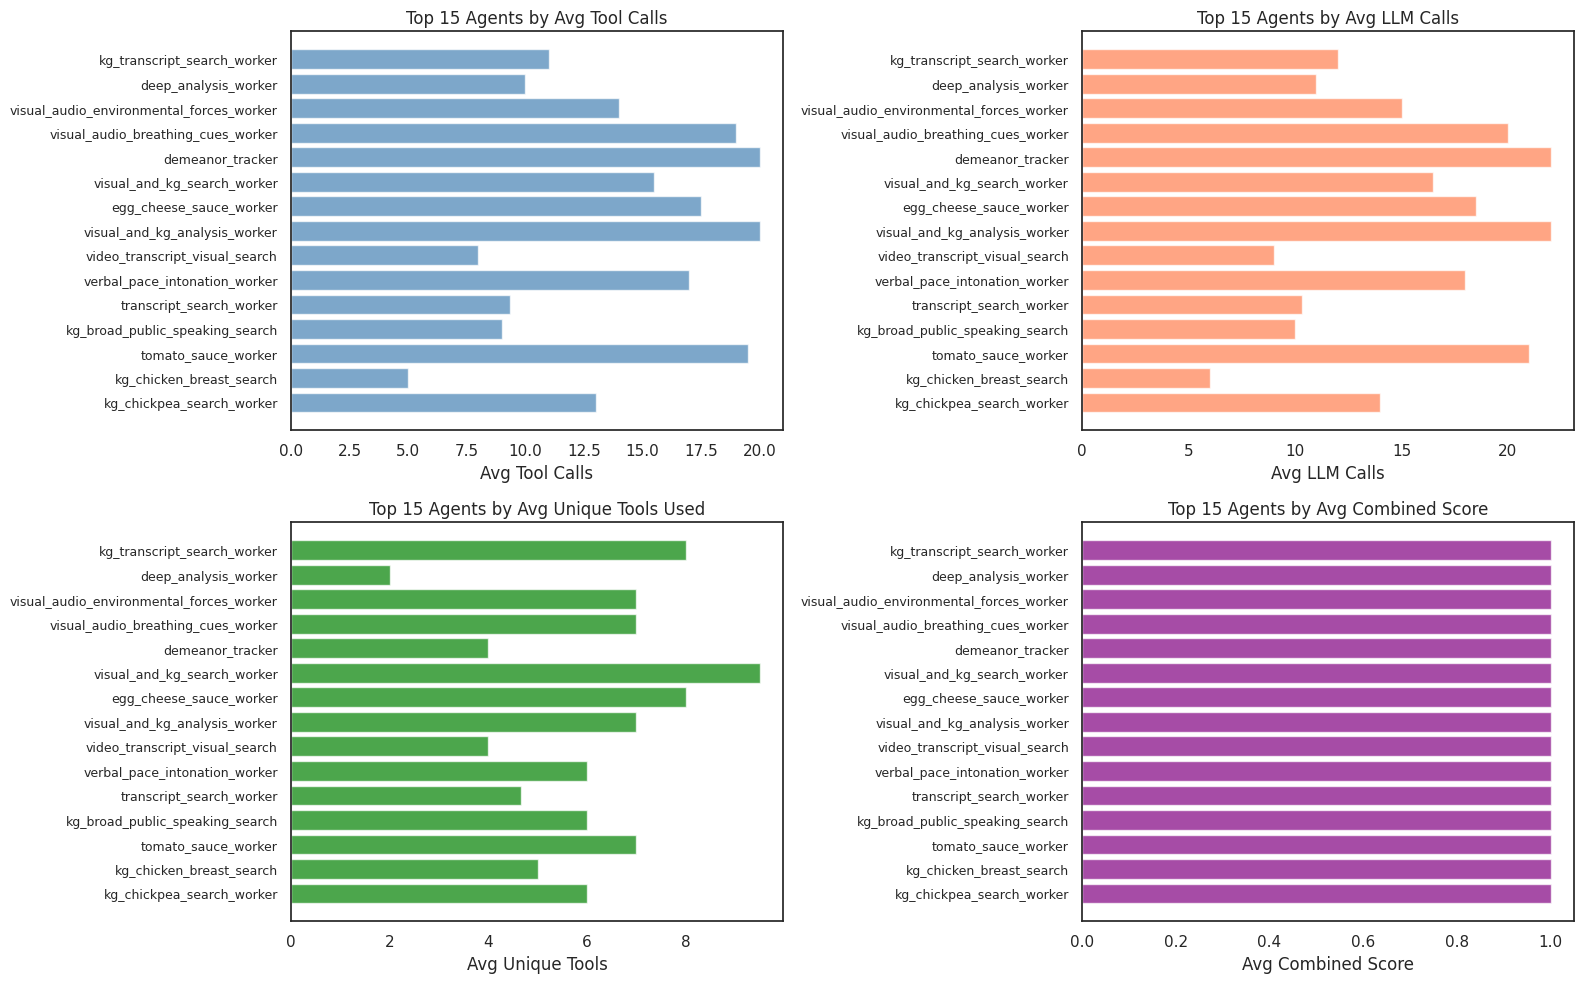

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

top_agents = agent_avg_metrics.head(15)

axes[0, 0].barh(range(len(top_agents)), top_agents['tool_calls'].values, color='steelblue', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_agents)))
axes[0, 0].set_yticklabels(top_agents['agent_name'], fontsize=9)
axes[0, 0].set_xlabel('Avg Tool Calls')
axes[0, 0].set_title('Top 15 Agents by Avg Tool Calls')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(range(len(top_agents)), top_agents['llm_calls'].values, color='coral', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_agents)))
axes[0, 1].set_yticklabels(top_agents['agent_name'], fontsize=9)
axes[0, 1].set_xlabel('Avg LLM Calls')
axes[0, 1].set_title('Top 15 Agents by Avg LLM Calls')
axes[0, 1].invert_yaxis()

axes[1, 0].barh(range(len(top_agents)), top_agents['unique_tools_used'].values, color='green', alpha=0.7)
axes[1, 0].set_yticks(range(len(top_agents)))
axes[1, 0].set_yticklabels(top_agents['agent_name'], fontsize=9)
axes[1, 0].set_xlabel('Avg Unique Tools')
axes[1, 0].set_title('Top 15 Agents by Avg Unique Tools Used')
axes[1, 0].invert_yaxis()

axes[1, 1].barh(range(len(top_agents)), top_agents['combined_score'].values, color='purple', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_agents)))
axes[1, 1].set_yticklabels(top_agents['agent_name'], fontsize=9)
axes[1, 1].set_xlabel('Avg Combined Score')
axes[1, 1].set_title('Top 15 Agents by Avg Combined Score')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 21. Key Steps Analysis (Video Found, Timeline, Answer)

In [92]:
key_steps_scores = df_trace_key_steps.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
key_steps_scores = key_steps_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

key_steps_scores['video_found_ratio'] = key_steps_scores['video_id_found_step'] / key_steps_scores['final_step']
key_steps_scores['timeline_found_ratio'] = key_steps_scores['timeline_found_step'] / key_steps_scores['final_step']
key_steps_scores['answer_found_ratio'] = key_steps_scores['core_answer_step'] / key_steps_scores['final_step']

print("Key Steps Statistics:")
print(f"  Avg video_id_found_step: {key_steps_scores['video_id_found_step'].mean():.2f}")
print(f"  Avg timeline_found_step: {key_steps_scores['timeline_found_step'].mean():.2f}")
print(f"  Avg core_answer_step: {key_steps_scores['core_answer_step'].mean():.2f}")
print(f"  Avg final_step: {key_steps_scores['final_step'].mean():.2f}")
print(f"\n  Avg video_found_ratio: {key_steps_scores['video_found_ratio'].mean():.2%}")
print(f"  Avg timeline_found_ratio: {key_steps_scores['timeline_found_ratio'].mean():.2%}")
print(f"  Avg answer_found_ratio: {key_steps_scores['answer_found_ratio'].mean():.2%}")

Key Steps Statistics:
  Avg video_id_found_step: 5.11
  Avg timeline_found_step: 5.29
  Avg core_answer_step: 5.29
  Avg final_step: 82.89

  Avg video_found_ratio: 6.81%
  Avg timeline_found_ratio: 7.01%
  Avg answer_found_ratio: 7.01%


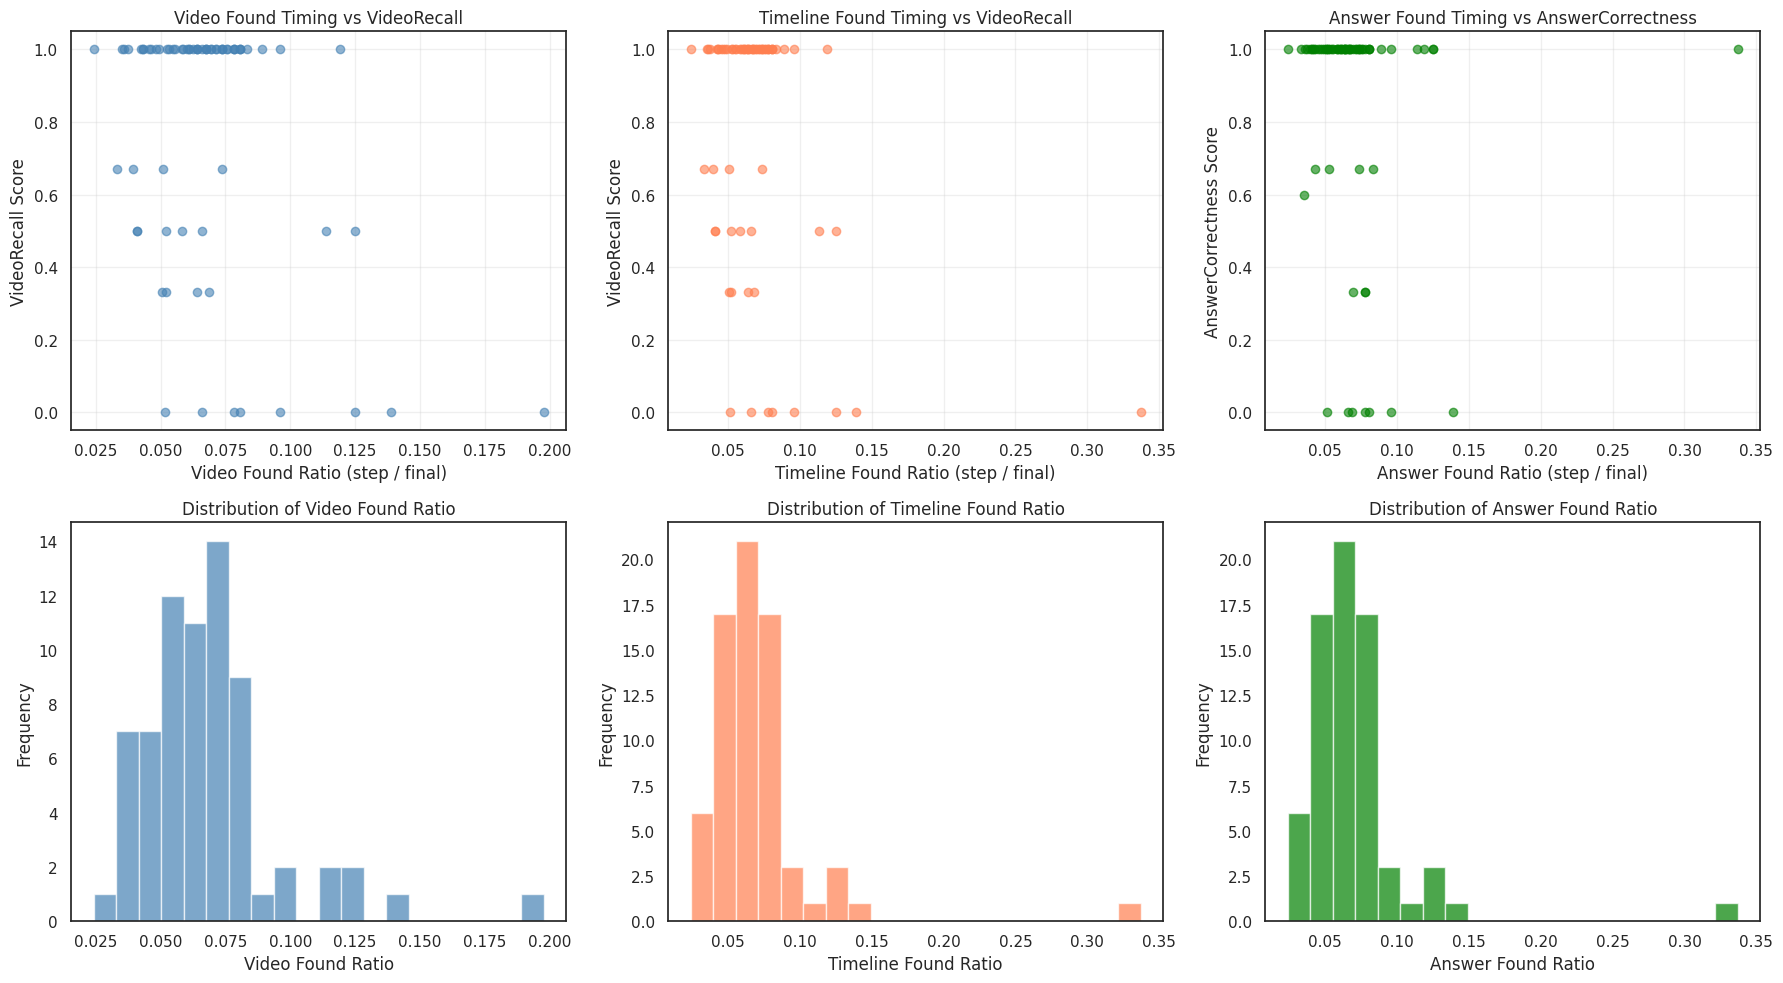

In [93]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(key_steps_scores['video_found_ratio'], key_steps_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0, 0].set_xlabel('Video Found Ratio (step / final)')
axes[0, 0].set_ylabel('VideoRecall Score')
axes[0, 0].set_title('Video Found Timing vs VideoRecall')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(key_steps_scores['timeline_found_ratio'], key_steps_scores['feedback_value_recall'], alpha=0.6, c='coral')
axes[0, 1].set_xlabel('Timeline Found Ratio (step / final)')
axes[0, 1].set_ylabel('VideoRecall Score')
axes[0, 1].set_title('Timeline Found Timing vs VideoRecall')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(key_steps_scores['answer_found_ratio'], key_steps_scores['feedback_value_answer'], alpha=0.6, c='green')
axes[0, 2].set_xlabel('Answer Found Ratio (step / final)')
axes[0, 2].set_ylabel('AnswerCorrectness Score')
axes[0, 2].set_title('Answer Found Timing vs AnswerCorrectness')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].hist(key_steps_scores['video_found_ratio'].dropna(), bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[1, 0].set_xlabel('Video Found Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Video Found Ratio')

axes[1, 1].hist(key_steps_scores['timeline_found_ratio'].dropna(), bins=20, color='coral', alpha=0.7, edgecolor='white')
axes[1, 1].set_xlabel('Timeline Found Ratio')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Timeline Found Ratio')

axes[1, 2].hist(key_steps_scores['answer_found_ratio'].dropna(), bins=20, color='green', alpha=0.7, edgecolor='white')
axes[1, 2].set_xlabel('Answer Found Ratio')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Answer Found Ratio')

plt.tight_layout()
plt.show()

## 22. Workers Spawned vs Performance

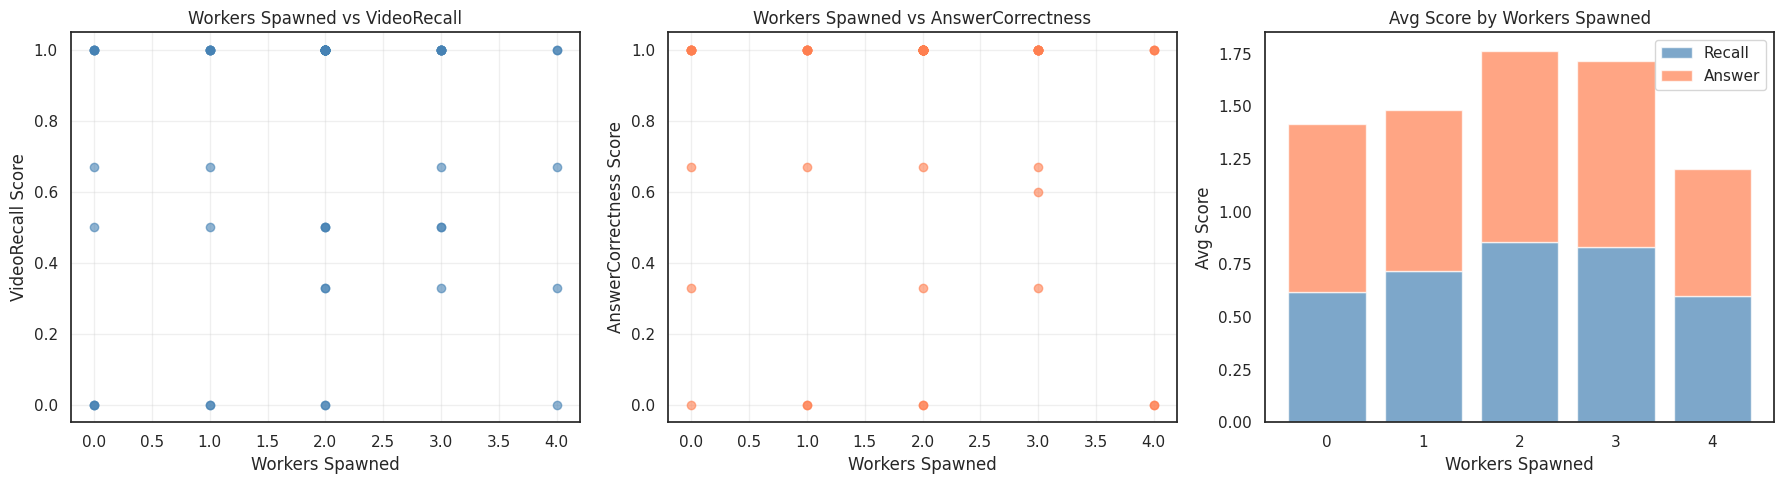

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(trace_general_scores['workers_spawned'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Workers Spawned')
axes[0].set_ylabel('VideoRecall Score')
axes[0].set_title('Workers Spawned vs VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(trace_general_scores['workers_spawned'], trace_general_scores['feedback_value_answer'], alpha=0.6, c='coral')
axes[1].set_xlabel('Workers Spawned')
axes[1].set_ylabel('AnswerCorrectness Score')
axes[1].set_title('Workers Spawned vs AnswerCorrectness')
axes[1].grid(True, alpha=0.3)

worker_perf_avg = trace_general_scores.groupby('workers_spawned').agg({
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean',
    'execution_duration_sec': 'mean'
}).reset_index()

axes[2].bar(worker_perf_avg['workers_spawned'], worker_perf_avg['feedback_value_recall'], color='steelblue', alpha=0.7, label='Recall')
axes[2].bar(worker_perf_avg['workers_spawned'], worker_perf_avg['feedback_value_answer'], color='coral', alpha=0.7, bottom=worker_perf_avg['feedback_value_recall'], label='Answer')
axes[2].set_xlabel('Workers Spawned')
axes[2].set_ylabel('Avg Score')
axes[2].set_title('Avg Score by Workers Spawned')
axes[2].legend()

plt.tight_layout()
plt.show()

## 23. Agent Count vs Performance

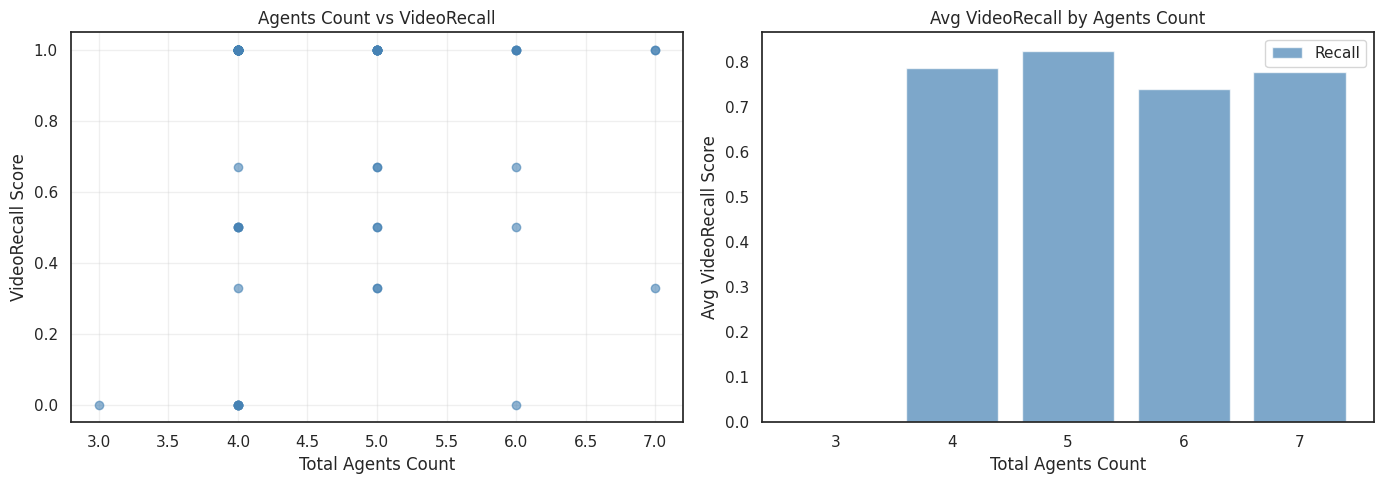

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(trace_general_scores['agents_count'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Total Agents Count')
axes[0].set_ylabel('VideoRecall Score')
axes[0].set_title('Agents Count vs VideoRecall')
axes[0].grid(True, alpha=0.3)

agent_count_avg = trace_general_scores.groupby('agents_count').agg({
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean',
    'execution_duration_sec': 'mean'
}).reset_index()

axes[1].bar(agent_count_avg['agents_count'], agent_count_avg['feedback_value_recall'], color='steelblue', alpha=0.7, label='Recall')
axes[1].set_xlabel('Total Agents Count')
axes[1].set_ylabel('Avg VideoRecall Score')
axes[1].set_title('Avg VideoRecall by Agents Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 24. Efficiency Analysis: Spans per Second

In [96]:
trace_general_scores['spans_per_sec'] = trace_general_scores['total_spans'] / trace_general_scores['execution_duration_sec']
trace_general_scores['tools_per_sec'] = trace_general_scores['total_tool_calls'] / trace_general_scores['execution_duration_sec']
trace_general_scores['llm_calls_per_sec'] = trace_general_scores['total_llm_calls'] / trace_general_scores['execution_duration_sec']

print("Efficiency Statistics:")
print(f"  Avg spans per sec: {trace_general_scores['spans_per_sec'].mean():.3f}")
print(f"  Avg tools per sec: {trace_general_scores['tools_per_sec'].mean():.3f}")
print(f"  Avg LLM calls per sec: {trace_general_scores['llm_calls_per_sec'].mean():.3f}")

Efficiency Statistics:
  Avg spans per sec: 0.139
  Avg tools per sec: 0.061
  Avg LLM calls per sec: 0.070


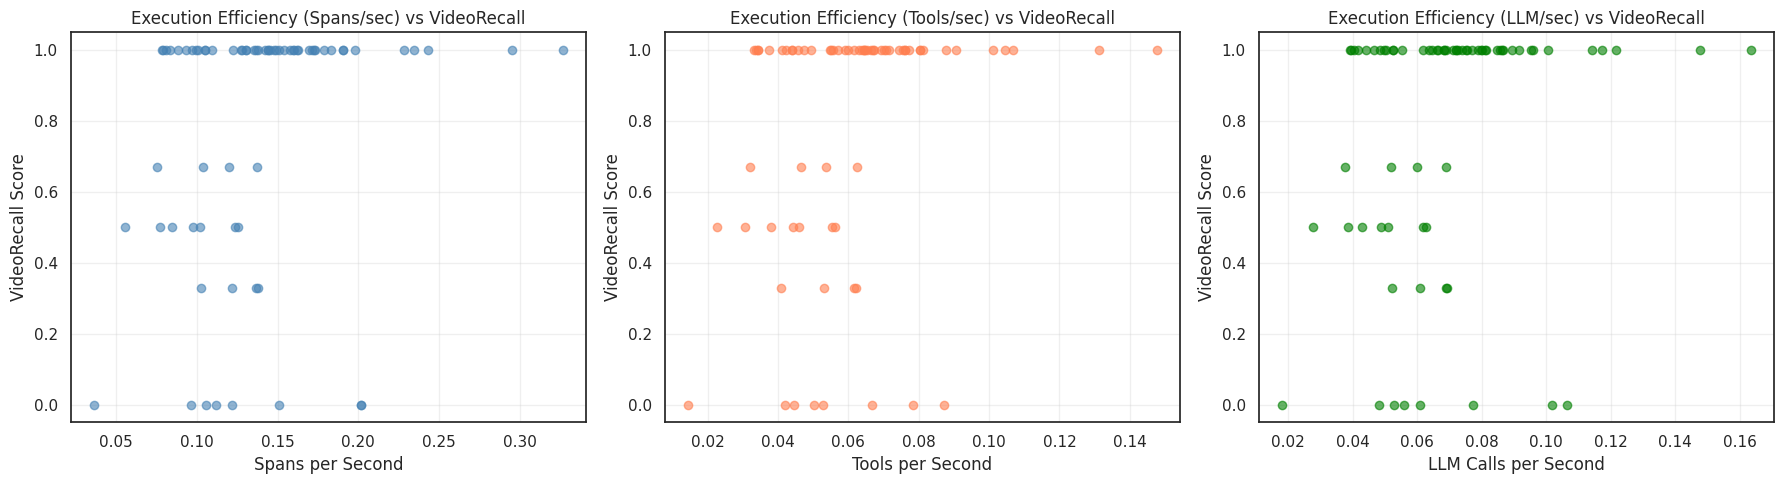

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(trace_general_scores['spans_per_sec'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Spans per Second')
axes[0].set_ylabel('VideoRecall Score')
axes[0].set_title('Execution Efficiency (Spans/sec) vs VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(trace_general_scores['tools_per_sec'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='coral')
axes[1].set_xlabel('Tools per Second')
axes[1].set_ylabel('VideoRecall Score')
axes[1].set_title('Execution Efficiency (Tools/sec) vs VideoRecall')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(trace_general_scores['llm_calls_per_sec'], trace_general_scores['feedback_value_recall'], alpha=0.6, c='green')
axes[2].set_xlabel('LLM Calls per Second')
axes[2].set_ylabel('VideoRecall Score')
axes[2].set_title('Execution Efficiency (LLM/sec) vs VideoRecall')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 25. High vs Low Potential Savings Comparison

In [98]:
high_savings = trace_general_scores[trace_general_scores['potential_savings_pct'] >= trace_general_scores['potential_savings_pct'].quantile(0.75)]
low_savings = trace_general_scores[trace_general_scores['potential_savings_pct'] <= trace_general_scores['potential_savings_pct'].quantile(0.25)]

print(f"High savings traces (>=75th percentile): {len(high_savings)}")
print(f"Low savings traces (<=25th percentile): {len(low_savings)}")

print("\nComparison of High vs Low Potential Savings Traces:")
print(f"  Avg VideoRecall - High: {high_savings['feedback_value_recall'].mean():.3f}, Low: {low_savings['feedback_value_recall'].mean():.3f}")
print(f"  Avg AnswerCorrectness - High: {high_savings['feedback_value_answer'].mean():.3f}, Low: {low_savings['feedback_value_answer'].mean():.3f}")
print(f"  Avg Execution Duration - High: {high_savings['execution_duration_sec'].mean():.1f}s, Low: {low_savings['execution_duration_sec'].mean():.1f}s")
print(f"  Avg Total Spans - High: {high_savings['total_spans'].mean():.1f}, Low: {low_savings['total_spans'].mean():.1f}")

High savings traces (>=75th percentile): 18
Low savings traces (<=25th percentile): 18

Comparison of High vs Low Potential Savings Traces:
  Avg VideoRecall - High: 0.797, Low: 0.611
  Avg AnswerCorrectness - High: 0.904, Low: 0.685
  Avg Execution Duration - High: 897.6s, Low: 563.1s
  Avg Total Spans - High: 119.9, Low: 56.2


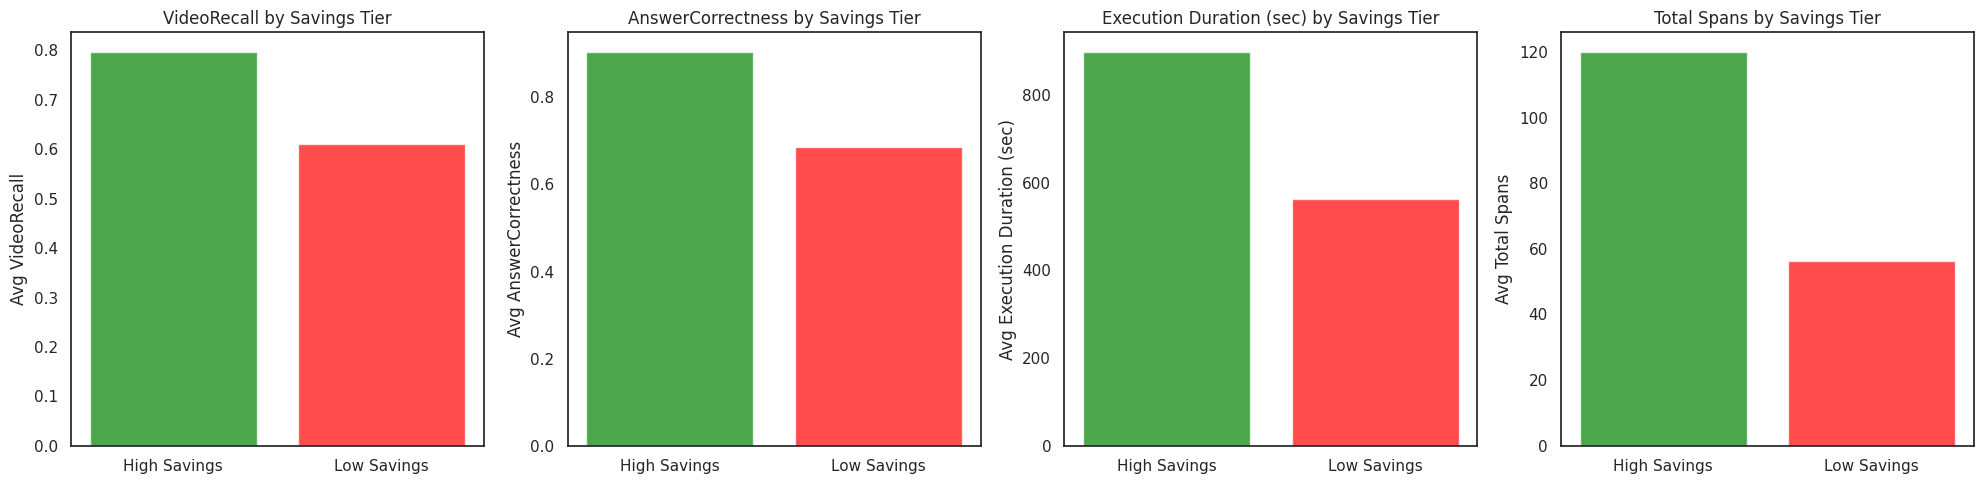

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = ['feedback_value_recall', 'feedback_value_answer', 'execution_duration_sec', 'total_spans']
labels = ['VideoRecall', 'AnswerCorrectness', 'Execution Duration (sec)', 'Total Spans']
colors = ['steelblue', 'coral', 'green', 'purple']

for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    axes[i].bar(['High Savings', 'Low Savings'], 
               [high_savings[metric].mean(), low_savings[metric].mean()], 
               color=['green', 'red'], alpha=0.7)
    axes[i].set_ylabel(f'Avg {label}')
    axes[i].set_title(f'{label} by Savings Tier')

plt.tight_layout()
plt.show()

## 27. Performance Tiers Based on Execution Duration

In [100]:
trace_general_scores['duration_tier'] = pd.cut(trace_general_scores['execution_duration_sec'], 
                                                bins=[0, 1200, 1500, 1800, 2500],
                                                labels=['Fast (<1200s)', 'Medium (1200-1500s)', 'Slow (1500-1800s)', 'Very Slow (>1800s)'])

duration_tier_perf = trace_general_scores.groupby('duration_tier').agg({
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean',
    'potential_savings_pct': 'mean',
    'workers_spawned': 'mean',
    'spans_per_sec': 'mean'
}).reset_index()

duration_tier_perf

/tmp/ipykernel_3115219/1033567598.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_tier_perf = trace_general_scores.groupby('duration_tier').agg({


,duration_tier,feedback_value_recall,feedback_value_answer,potential_savings_pct,workers_spawned,spans_per_sec
0,Fast (<1200s),0.772727,0.837424,92.781212,1.954545,0.141053
1,Medium (1200-1500s),0.833333,1.0,95.966667,0.666667,0.095754
2,Slow (1500-1800s),1.0,1.0,97.580000,1.000000,0.130457
3,Very Slow (>1800s),NaN,NaN,NaN,NaN,NaN


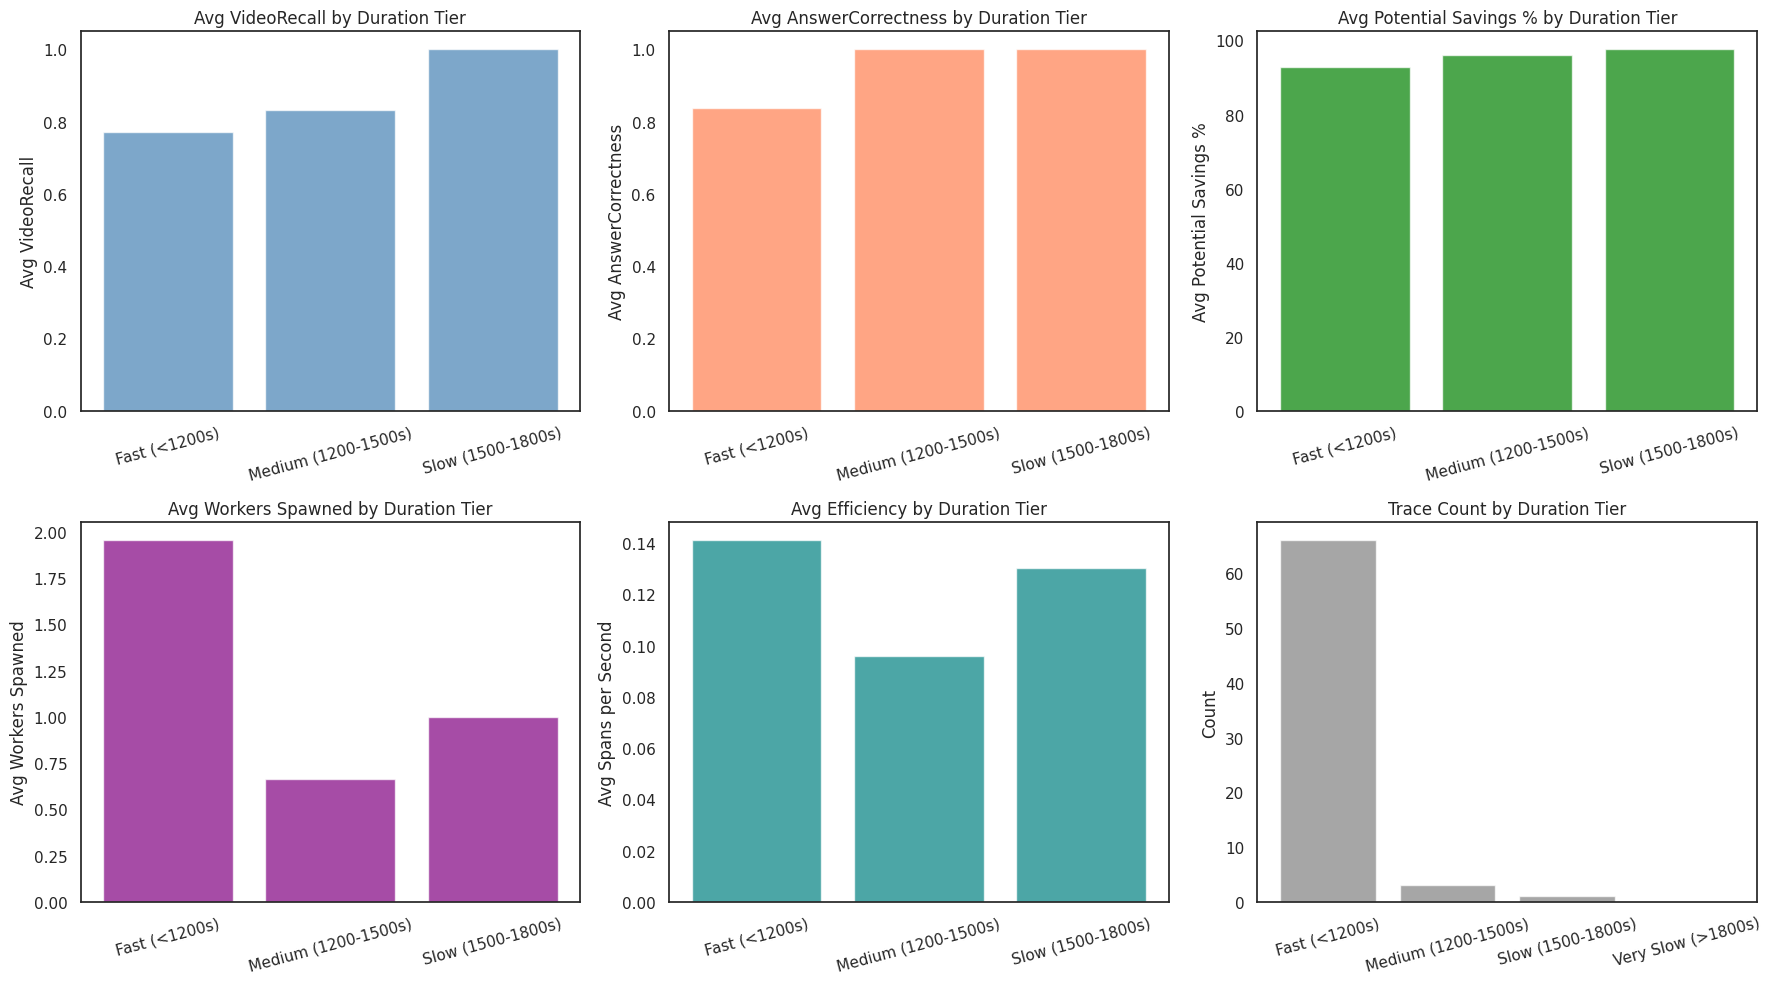

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].bar(duration_tier_perf['duration_tier'], duration_tier_perf['feedback_value_recall'], color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('Avg VideoRecall')
axes[0, 0].set_title('Avg VideoRecall by Duration Tier')
axes[0, 0].tick_params(axis='x', rotation=15)

axes[0, 1].bar(duration_tier_perf['duration_tier'], duration_tier_perf['feedback_value_answer'], color='coral', alpha=0.7)
axes[0, 1].set_ylabel('Avg AnswerCorrectness')
axes[0, 1].set_title('Avg AnswerCorrectness by Duration Tier')
axes[0, 1].tick_params(axis='x', rotation=15)

axes[0, 2].bar(duration_tier_perf['duration_tier'], duration_tier_perf['potential_savings_pct'], color='green', alpha=0.7)
axes[0, 2].set_ylabel('Avg Potential Savings %')
axes[0, 2].set_title('Avg Potential Savings % by Duration Tier')
axes[0, 2].tick_params(axis='x', rotation=15)

axes[1, 0].bar(duration_tier_perf['duration_tier'], duration_tier_perf['workers_spawned'], color='purple', alpha=0.7)
axes[1, 0].set_ylabel('Avg Workers Spawned')
axes[1, 0].set_title('Avg Workers Spawned by Duration Tier')
axes[1, 0].tick_params(axis='x', rotation=15)

axes[1, 1].bar(duration_tier_perf['duration_tier'], duration_tier_perf['spans_per_sec'], color='teal', alpha=0.7)
axes[1, 1].set_ylabel('Avg Spans per Second')
axes[1, 1].set_title('Avg Efficiency by Duration Tier')
axes[1, 1].tick_params(axis='x', rotation=15)

tier_counts = trace_general_scores['duration_tier'].value_counts()
axes[1, 2].bar(tier_counts.index, tier_counts.values, color='gray', alpha=0.7)
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Trace Count by Duration Tier')
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 28. Comprehensive Trace Analysis Summary

In [102]:
print("="*100)
print("COMPREHENSIVE TRACE ANALYSIS SUMMARY (From JSON)")
print("="*100)

print("\n1. EXECUTION DURATION ANALYSIS:")
print(f"   Mean execution duration: {trace_general_scores['execution_duration_sec'].mean():.2f} seconds")
print(f"   Median execution duration: {trace_general_scores['execution_duration_sec'].median():.2f} seconds")
print(f"   Min execution duration: {trace_general_scores['execution_duration_sec'].min():.2f} seconds")
print(f"   Max execution duration: {trace_general_scores['execution_duration_sec'].max():.2f} seconds")

print("\n2. POTENTIAL SAVINGS ANALYSIS:")
print(f"   Mean potential savings: {trace_general_scores['potential_savings'].mean():.2f} spans")
print(f"   Mean potential savings %: {trace_general_scores['potential_savings_pct'].mean():.2f}%")
print(f"   Traces with >90% potential savings: {len(trace_general_scores[trace_general_scores['potential_savings_pct'] > 90])}")

print("\n3. VIDEO MATCH ANALYSIS:")
print(f"   Video match rate: {df_trace_general['video_match'].sum() / len(df_trace_general) * 100:.2f}%")
print(f"   Traces with expected records: {df_trace_general['has_expected_record'].sum()}")
print(f"   Mean expected video count: {trace_general_scores['expected_video_count'].mean():.2f}")
print(f"   Mean actual video count: {trace_general_scores['actual_video_count'].mean():.2f}")

print("\n4. KEY STEPS ANALYSIS:")
print(f"   Avg video_id_found_step: {key_steps_scores['video_id_found_step'].mean():.2f}")
print(f"   Avg timeline_found_step: {key_steps_scores['timeline_found_step'].mean():.2f}")
print(f"   Avg core_answer_step: {key_steps_scores['core_answer_step'].mean():.2f}")
print(f"   Avg video found ratio: {key_steps_scores['video_found_ratio'].mean():.2%}")

print("\n5. WORKERS & AGENTS ANALYSIS:")
print(f"   Mean workers spawned: {trace_general_scores['workers_spawned'].mean():.2f}")
print(f"   Mean agents count: {trace_general_scores['agents_count'].mean():.2f}")
print(f"   Most common workers spawned: {trace_general_scores['workers_spawned'].mode().values[0]}")

print("\n6. EFFICIENCY ANALYSIS:")
print(f"   Mean spans per second: {trace_general_scores['spans_per_sec'].mean():.4f}")
print(f"   Mean tools per second: {trace_general_scores['tools_per_sec'].mean():.4f}")
print(f"   Mean LLM calls per second: {trace_general_scores['llm_calls_per_sec'].mean():.4f}")

print("\n7. HIGH PERFORMANCE TIER ANALYSIS (VideoRecall >= 0.7):")
high_perf = trace_general_scores[trace_general_scores['feedback_value_recall'] >= 0.7]
print(f"   Count: {len(high_perf)}")
print(f"   Avg execution duration: {high_perf['execution_duration_sec'].mean():.2f}s")
print(f"   Avg potential savings %: {high_perf['potential_savings_pct'].mean():.2f}%")
print(f"   Avg workers spawned: {high_perf['workers_spawned'].mean():.2f}")
print(f"   Video match rate: {high_perf['video_match'].sum() / len(high_perf) * 100:.2f}%")

print("\n8. LOW PERFORMANCE TIER ANALYSIS (VideoRecall < 0.5):")
low_perf = trace_general_scores[trace_general_scores['feedback_value_recall'] < 0.5]
print(f"   Count: {len(low_perf)}")
print(f"   Avg execution duration: {low_perf['execution_duration_sec'].mean():.2f}s")
print(f"   Avg potential savings %: {low_perf['potential_savings_pct'].mean():.2f}%")
print(f"   Avg workers spawned: {low_perf['workers_spawned'].mean():.2f}")
print(f"   Video match rate: {low_perf['video_match'].sum() / len(low_perf) * 100:.2f}%")

print("\n" + "="*100)

COMPREHENSIVE TRACE ANALYSIS SUMMARY (From JSON)

1. EXECUTION DURATION ANALYSIS:
   Mean execution duration: 653.69 seconds
   Median execution duration: 624.13 seconds
   Min execution duration: 178.42 seconds
   Max execution duration: 1586.73 seconds

2. POTENTIAL SAVINGS ANALYSIS:
   Mean potential savings: 77.60 spans
   Mean potential savings %: 92.99%
   Traces with >90% potential savings: 64

3. VIDEO MATCH ANALYSIS:
   Video match rate: 100.00%
   Traces with expected records: 70
   Mean expected video count: 1.96
   Mean actual video count: 59.60

4. KEY STEPS ANALYSIS:
   Avg video_id_found_step: 5.11
   Avg timeline_found_step: 5.29
   Avg core_answer_step: 5.29
   Avg video found ratio: 6.81%

5. WORKERS & AGENTS ANALYSIS:
   Mean workers spawned: 1.89
   Mean agents count: 4.56
   Most common workers spawned: 2

6. EFFICIENCY ANALYSIS:
   Mean spans per second: 0.1390
   Mean tools per second: 0.0613
   Mean LLM calls per second: 0.0697

7. HIGH PERFORMANCE TIER ANALYSIS

## 16. Summary Statistics

In [103]:
print("="*80)
print("CROSS-DATAFRAME ANALYSIS SUMMARY")
print("="*80)

print("\n1. KEY CORRELATIONS WITH SCORES:")
corr_with_recall = correlation_matrix['feedback_value_recall'].drop('feedback_value_recall').sort_values(ascending=False)
print(f"\n   Top positive correlations with VideoRecall:")
for metric, corr in corr_with_recall.head(5).items():
    print(f"      {metric}: {corr:.3f}")
print(f"\n   Top negative correlations with VideoRecall:")
for metric, corr in corr_with_recall.tail(3).items():
    print(f"      {metric}: {corr:.3f}")

print("\n2. AVERAGE METRICS BY SCORE TIER:")
for metric in ['total_cost', 'total_latency_sec', 'worker_count', 'unique_tool_count', 'unique_model_count']:
    high_avg = master_trace[master_trace['feedback_value_recall'] >= 0.7][metric].mean()
    low_avg = master_trace[master_trace['feedback_value_recall'] < 0.5][metric].mean()
    print(f"   {metric}: High={high_avg:.2f}, Low={low_avg:.2f}, Diff={high_avg-low_avg:.2f}")

print("\n3. TOP PERFORMING MODEL COMBINATIONS:")
for i, (combo, score) in enumerate(model_combo_avg_recall.head(3).items(), 1):
    print(f"   {i}. {combo}: Avg Recall={score:.3f}")

print("\n4. TOP PERFORMING WORKER AGENTS:")
for i, (worker, score) in enumerate(worker_perf_df['avg_score'].head(5).items(), 1):
    print(f"   {i}. {worker}: Avg Combined Score={score:.3f}")

print("\n5. TOP COST-EFFICIENT TRACES:")
for i, row in enumerate(efficiency_sorted.head(5).iterrows(), 1):
    tid = row[1]['trace_id'][:30]
    eff = row[1]['cost_efficiency_combined']
    cost = row[1]['total_cost']
    recall = row[1]['feedback_value_recall']
    print(f"   {i}. {tid}: Efficiency={eff:.2f}, Cost=${cost:.4f}, Recall={recall:.2f}")

print("\n" + "="*80)

CROSS-DATAFRAME ANALYSIS SUMMARY

1. KEY CORRELATIONS WITH SCORES:

   Top positive correlations with VideoRecall:
      human_judgement_score: 0.769
      feedback_value_answer: 0.544
      unique_model_count: 0.247
      total_input_tokens: 0.187
      total_tool_calls: 0.177

   Top negative correlations with VideoRecall:
      total_output_tokens: -0.038
      total_latency_sec: -0.078
      total_tool_latency_ms: -0.080

2. AVERAGE METRICS BY SCORE TIER:
   total_cost: High=0.39, Low=0.34, Diff=0.06
   total_latency_sec: High=1550.37, Low=1553.28, Diff=-2.91
   worker_count: High=2.53, Low=2.42, Diff=0.12
   unique_tool_count: High=13.21, Low=12.75, Diff=0.46
   unique_model_count: High=2.57, Low=2.17, Diff=0.41

3. TOP PERFORMING MODEL COMBINATIONS:
   1. ('google/gemini-3.1-flash-lite-preview', 'qwen/qwen3.5-plus-02-15', 'qwen/qwen3.6-plus', 'z-ai/glm-5.1'): Avg Recall=1.000
   2. ('qwen/qwen3.5-27b', 'qwen/qwen3.6-plus', 'z-ai/glm-5.1'): Avg Recall=1.000
   3. ('qwen/qwen3.5-fl

# Tool Sequence & Tool Group Sequence Analysis
Analyzing patterns in how tools are called in sequence and their impact on performance

In [104]:
ignore_tool_list = [
    'get_member_information',
    'delegate_task_to_member',
    'get_available_worker_tools',
    'get_available_models',
    'spawn_and_run_worker'
]
df_trace_tools[~df_trace_tools['tool_name'].isin(ignore_tool_list)]

,trace_id,tool_name,agent,step_th
5,tr-2b35f46018dd98383e97c207cea057a2,triple_hybrid_search,video_discovery_worker,15
6,tr-2b35f46018dd98383e97c207cea057a2,search_bm25,video_discovery_worker,17
7,tr-2b35f46018dd98383e97c207cea057a2,search_entities_semantic,video_discovery_worker,19
8,tr-2b35f46018dd98383e97c207cea057a2,get_segments_from_event_query_mmbert,video_discovery_worker,21
9,tr-2b35f46018dd98383e97c207cea057a2,get_video_metadata,video_discovery_worker,23
...,...,...,...,...
2566,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,130
2567,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,132
2568,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,134
2569,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,136


## 1. Build Tool Sequences for Each Trace

In [105]:
df_trace_tools_filtered = df_trace_tools[~df_trace_tools['tool_name'].isin(ignore_tool_list)]

trace_tool_seq = df_trace_tools_filtered.groupby('trace_id').apply(
    lambda x: tuple(x.sort_values('step_th')['tool_name'].tolist()),
    include_groups=False
).reset_index()
trace_tool_seq.columns = ['trace_id', 'tool_sequence']

trace_tool_seq['sequence_length'] = trace_tool_seq['tool_sequence'].apply(len)
trace_tool_seq['unique_tools'] = trace_tool_seq['tool_sequence'].apply(lambda x: len(set(x)))

trace_tool_seq_scores = trace_tool_seq.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
trace_tool_seq_scores = trace_tool_seq_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

print(f"Total traces: {len(trace_tool_seq_scores)}")
print(f"Ignored tools: {ignore_tool_list}")
trace_tool_seq_scores.head()

Total traces: 70
Ignored tools: ['get_member_information', 'delegate_task_to_member', 'get_available_worker_tools', 'get_available_models', 'spawn_and_run_worker']


,trace_id,tool_sequence,sequence_length,unique_tools,feedback_value_recall,feedback_value_answer
0,tr-01ee9f794325242fd70297e4d8ee62f1,"(search_bm25, search_communities, search_event...",28,15,0.0,0.0
1,tr-06dd73dbdc6cf4b6ab34302c84d458b9,"(triple_hybrid_search, search_entities_semanti...",20,13,0.33,0.0
2,tr-07b82ba9bae85eaefcc23fd665e5b0e9,"(get_segments_from_qwenvl_query, get_segments_...",39,12,0.33,1.0
3,tr-102ac03e8e568186b1e7daa5775b78ea,"(multi_granularity_search, triple_hybrid_searc...",29,14,1.0,1.0
4,tr-1246f0338e5541a4dbfd6316d656ce4b,"(get_segments_from_qwenvl_query, get_segments_...",31,13,1.0,1.0


## 2. Build Tool Group Sequences (Category-based)

In [106]:
df_trace_tools_filtered

,trace_id,tool_name,agent,step_th
5,tr-2b35f46018dd98383e97c207cea057a2,triple_hybrid_search,video_discovery_worker,15
6,tr-2b35f46018dd98383e97c207cea057a2,search_bm25,video_discovery_worker,17
7,tr-2b35f46018dd98383e97c207cea057a2,search_entities_semantic,video_discovery_worker,19
8,tr-2b35f46018dd98383e97c207cea057a2,get_segments_from_event_query_mmbert,video_discovery_worker,21
9,tr-2b35f46018dd98383e97c207cea057a2,get_video_metadata,video_discovery_worker,23
...,...,...,...,...
2566,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,130
2567,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,132
2568,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,134
2569,tr-8fafb04c98bd4e967d79ff101ace7c43,get_related_asr_from_segment,deep_dive_safety_grip_worker,136


In [107]:
df_trace_tools_filtered['tool_group'] = df_trace_tools_filtered['tool_name'].apply(categorize_tool)

trace_toolgroup_seq = df_trace_tools_filtered.groupby('trace_id').apply(
    lambda x: tuple(x.sort_values('step_th')['tool_group'].tolist()),
    include_groups=False
).reset_index()
trace_toolgroup_seq.columns = ['trace_id', 'toolgroup_sequence']

trace_toolgroup_seq['group_sequence_length'] = trace_toolgroup_seq['toolgroup_sequence'].apply(len)
trace_toolgroup_seq['unique_groups'] = trace_toolgroup_seq['toolgroup_sequence'].apply(lambda x: len(set(x)))

trace_toolgroup_seq_scores = trace_toolgroup_seq.merge(video_recall[['trace_id', 'feedback_value']], on='trace_id', how='left')
trace_toolgroup_seq_scores = trace_toolgroup_seq_scores.merge(answer_correctness[['trace_id', 'feedback_value']], on='trace_id', how='left', suffixes=('_recall', '_answer'))

trace_toolgroup_seq_scores.head()

/tmp/ipykernel_3115219/87140063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trace_tools_filtered['tool_group'] = df_trace_tools_filtered['tool_name'].apply(categorize_tool)


,trace_id,toolgroup_sequence,group_sequence_length,unique_groups,feedback_value_recall,feedback_value_answer
0,tr-01ee9f794325242fd70297e4d8ee62f1,"(KnowledgeGraph, KnowledgeGraph, KnowledgeGrap...",28,5,0.0,0.0
1,tr-06dd73dbdc6cf4b6ab34302c84d458b9,"(KnowledgeGraph, KnowledgeGraph, KnowledgeGrap...",20,4,0.33,0.0
2,tr-07b82ba9bae85eaefcc23fd665e5b0e9,"(Visual, Visual, Visual, Visual, Visual, Conte...",39,5,0.33,1.0
3,tr-102ac03e8e568186b1e7daa5775b78ea,"(Other, KnowledgeGraph, KnowledgeGraph, Knowle...",29,5,1.0,1.0
4,tr-1246f0338e5541a4dbfd6316d656ce4b,"(Visual, Visual, Visual, ContextExpansion, Con...",31,4,1.0,1.0


## 3. Sequence Length vs Performance

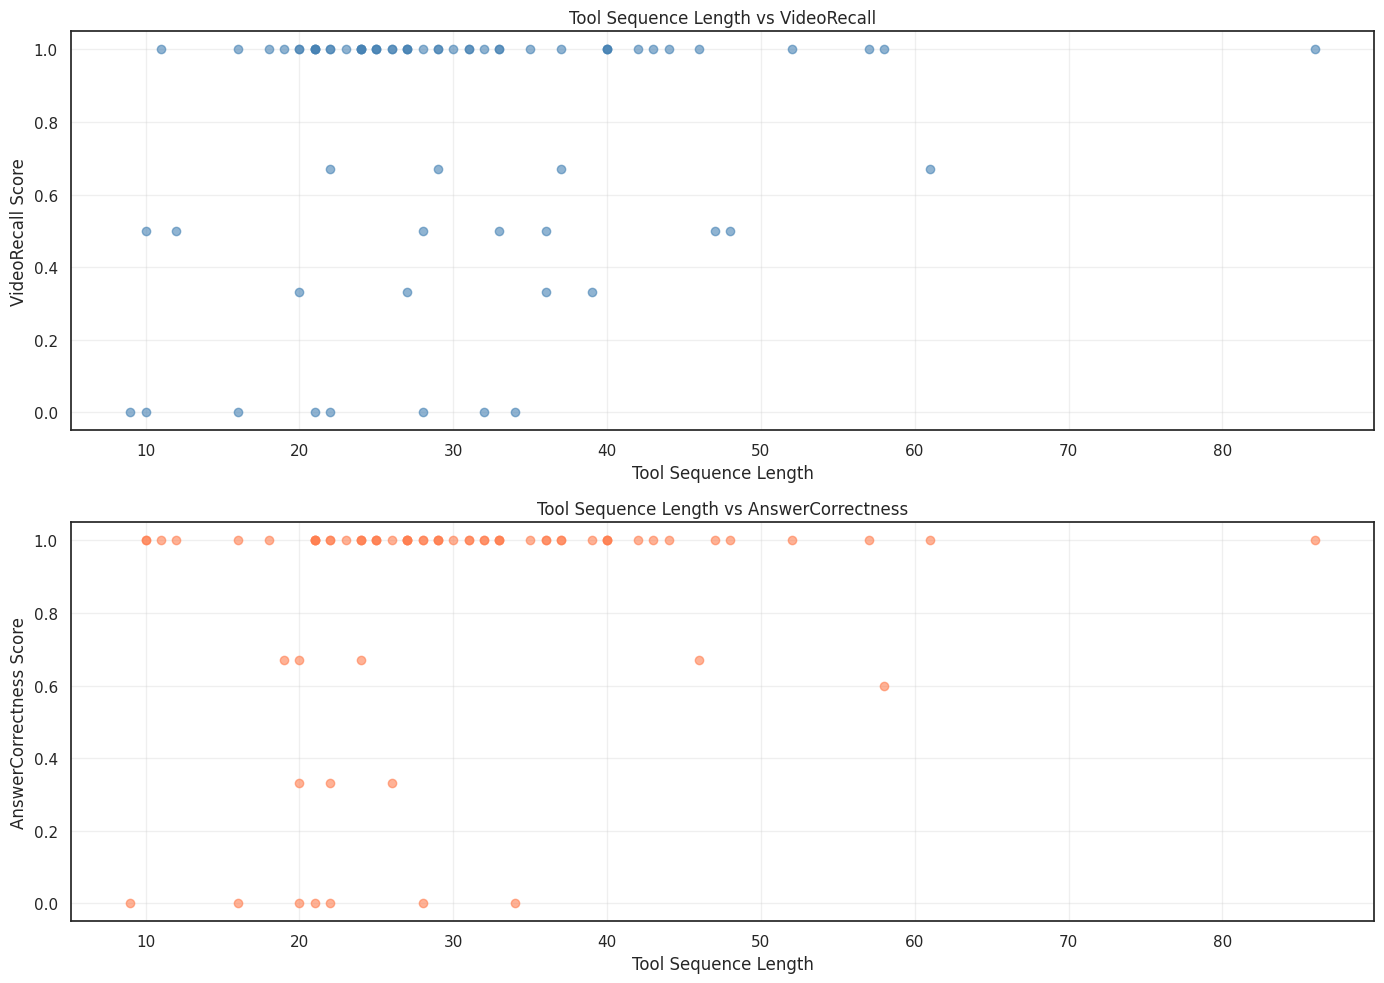

In [108]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].scatter(trace_tool_seq_scores['sequence_length'], trace_tool_seq_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('Tool Sequence Length')
axes[0].set_ylabel('VideoRecall Score')
axes[0].set_title('Tool Sequence Length vs VideoRecall')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(trace_tool_seq_scores['sequence_length'], trace_tool_seq_scores['feedback_value_answer'], alpha=0.6, c='coral')
axes[ 1].set_xlabel('Tool Sequence Length')
axes[ 1].set_ylabel('AnswerCorrectness Score')
axes[ 1].set_title('Tool Sequence Length vs AnswerCorrectness')
axes[ 1].grid(True, alpha=0.3)

# axes[1, 0].scatter(trace_toolgroup_seq_scores['group_sequence_length'], trace_toolgroup_seq_scores['feedback_value_recall'], alpha=0.6, c='green')
# axes[1, 0].set_xlabel('Tool Group Sequence Length')
# axes[1, 0].set_ylabel('VideoRecall Score')
# axes[1, 0].set_title('Tool Group Sequence Length vs VideoRecall')
# axes[1, 0].grid(True, alpha=0.3)

# axes[1, 1].scatter(trace_toolgroup_seq_scores['group_sequence_length'], trace_toolgroup_seq_scores['feedback_value_answer'], alpha=0.6, c='purple')
# axes[1, 1].set_xlabel('Tool Group Sequence Length')
# axes[1, 1].set_ylabel('AnswerCorrectness Score')
# axes[1, 1].set_title('Tool Group Sequence Length vs AnswerCorrectness')
# axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Most Common Tool Sequences by Performance Tier

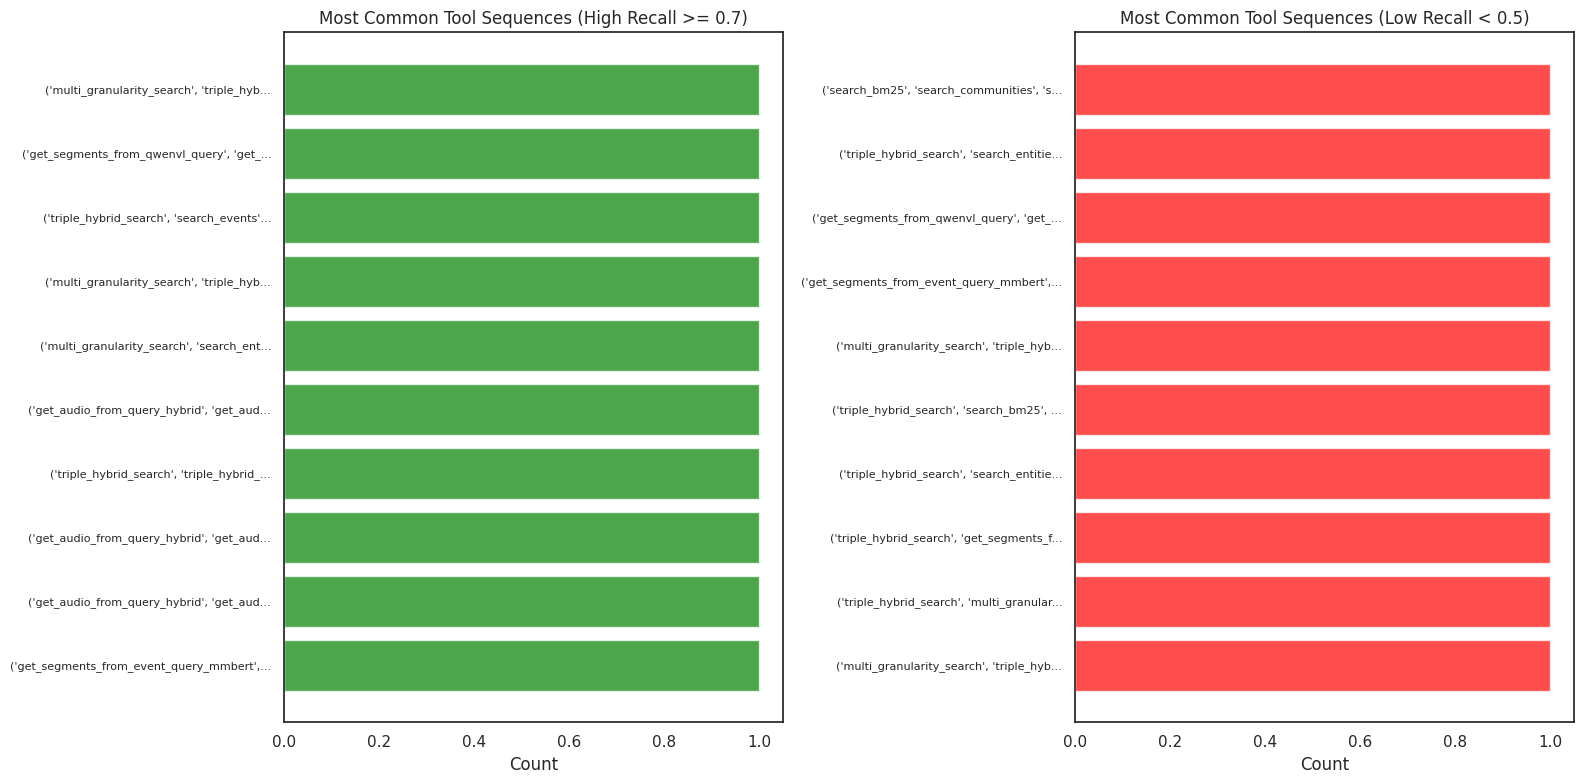

In [109]:
low_thresh = trace_tool_seq_scores['feedback_value_recall'].quantile(0.3)
high_thresh = trace_tool_seq_scores['feedback_value_recall'].quantile(0.8)

high_perf = trace_tool_seq_scores[
    trace_tool_seq_scores['feedback_value_recall'] >= high_thresh
]

low_perf = trace_tool_seq_scores[
    trace_tool_seq_scores['feedback_value_recall'] < low_thresh
]

high_perf_sequences = high_perf['tool_sequence'].value_counts().head(10)
low_perf_sequences = low_perf['tool_sequence'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(len(high_perf_sequences)), high_perf_sequences.values, color='green', alpha=0.7)
axes[0].set_yticks(range(len(high_perf_sequences)))
axes[0].set_yticklabels([str(seq)[:40] + '...' if len(str(seq)) > 40 else str(seq) for seq in high_perf_sequences.index], fontsize=8)
axes[0].set_xlabel('Count')
axes[0].set_title('Most Common Tool Sequences (High Recall >= 0.7)')
axes[0].invert_yaxis()

axes[1].barh(range(len(low_perf_sequences)), low_perf_sequences.values, color='red', alpha=0.7)
axes[1].set_yticks(range(len(low_perf_sequences)))
axes[1].set_yticklabels([str(seq)[:40] + '...' if len(str(seq)) > 40 else str(seq) for seq in low_perf_sequences.index], fontsize=8)
axes[1].set_xlabel('Count')
axes[1].set_title('Most Common Tool Sequences (Low Recall < 0.5)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [110]:
high_perf_sequences

tool_sequence
(multi_granularity_search, triple_hybrid_search, triple_hybrid_search, triple_hybrid_search, search_events, search_events, search_micro_events, search_entities_semantic, search_communities, traverse_from_entity, get_images_from_qwenvl_query, get_segments_from_event_query_mmbert, get_segments_from_qwenvl_query, get_audio_from_query_dense, get_audio_from_query_hybrid, get_related_asr_from_segment, get_related_asr_from_segment, get_adjacent_segments, get_segments_from_event_query_mmbert, get_audio_from_query_dense, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment)                                                                                            1
(get_segments_from_qwenvl_query, get_segments_from_event_query_mmbert, get_images_from_qwenvl_query, get_

In [111]:
low_perf_sequences

tool_sequence
(search_bm25, search_communities, search_events, search_entities_semantic, triple_hybrid_search, multi_granularity_search, search_events, search_events, search_events, search_events, get_images_from_qwenvl_query, get_audio_from_query_dense, get_segments_from_event_query_mmbert, get_segments_from_qwenvl_query, get_audio_from_query_hybrid, get_images_from_caption_query_mmbert, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_segment, get_related_asr_from_image, get_related_asr_from_image, get_related_asr_from_image, get_adjacent_segments, get_adjacent_segments, get_adjacent_segments, get_adjacent_segments, get_related_asr_from_segment, get_related_asr_from_image)                                                                                                                                                                                                                                                                                             

## 5. Most Common Tool Group Sequences by Performance Tier

In [112]:
low_thresh = trace_toolgroup_seq_scores['feedback_value_recall'].quantile(0.3)
high_thresh = trace_toolgroup_seq_scores['feedback_value_recall'].quantile(0.8)

high_perf_groups = trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['feedback_value_recall'] >= high_thresh]
low_perf_groups = trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['feedback_value_recall'] < low_thresh]

high_group_sequences = high_perf_groups['toolgroup_sequence'].value_counts().head(15)
low_group_sequences = low_perf_groups['toolgroup_sequence'].value_counts().head(15)



In [113]:
low_group_sequences

toolgroup_sequence
(KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, Other, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, Visual, Audio/ASR, Visual, Visual, Audio/ASR, Visual, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion, ContextExpansion)                                                                                                                                                                                                          1
(KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, KnowledgeGraph, Visual, Visual, Visual, Visual, Audio/ASR, Audio/ASR, Visual, Other, KnowledgeGraph, KnowledgeGraph, Visual, Audio/ASR, KnowledgeGraph, Visual)                                                                                                                    

## 6. Average Performance by Sequence Length Buckets

/tmp/ipykernel_3115219/379965333.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seq_perf = trace_tool_seq_scores.groupby('seq_bucket').agg({
/tmp/ipykernel_3115219/379965333.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_seq_perf = trace_toolgroup_seq_scores.groupby('group_seq_bucket').agg({


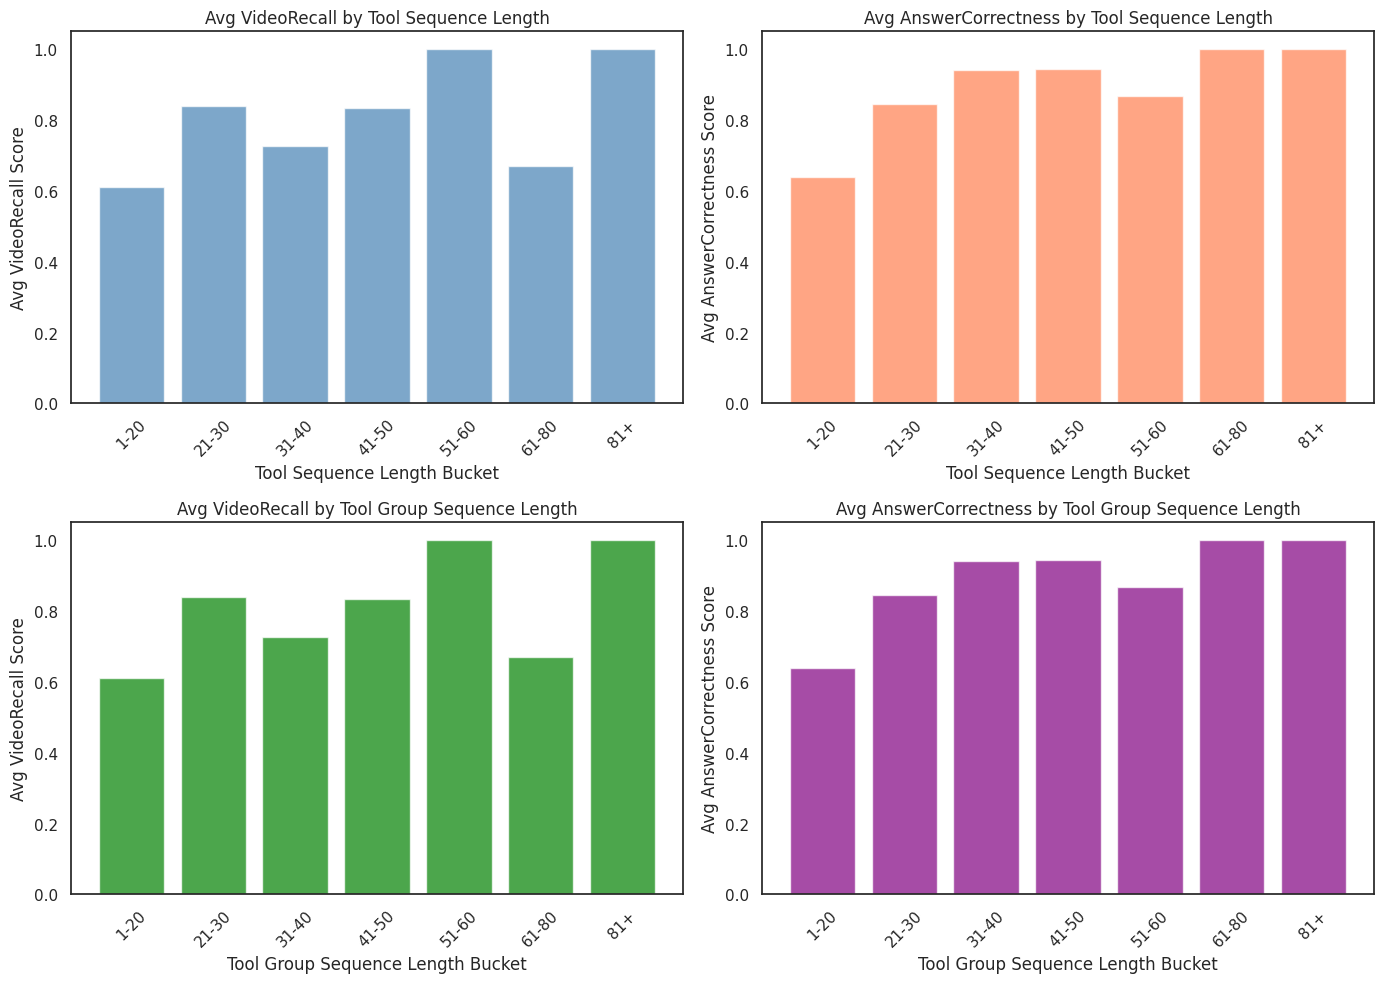

In [114]:
seq_bins = [0, 20, 30, 40, 50, 60, 80, 100]
seq_labels = ['1-20', '21-30', '31-40', '41-50', '51-60', '61-80', '81+']

trace_tool_seq_scores['seq_bucket'] = pd.cut(trace_tool_seq_scores['sequence_length'], bins=seq_bins, labels=seq_labels)
trace_toolgroup_seq_scores['group_seq_bucket'] = pd.cut(trace_toolgroup_seq_scores['group_sequence_length'], bins=seq_bins, labels=seq_labels)

seq_perf = trace_tool_seq_scores.groupby('seq_bucket').agg({
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean',
    'unique_tools': 'mean'
}).reset_index()

group_seq_perf = trace_toolgroup_seq_scores.groupby('group_seq_bucket').agg({
    'feedback_value_recall': 'mean',
    'feedback_value_answer': 'mean',
    'unique_groups': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(seq_perf['seq_bucket'], seq_perf['feedback_value_recall'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Tool Sequence Length Bucket')
axes[0, 0].set_ylabel('Avg VideoRecall Score')
axes[0, 0].set_title('Avg VideoRecall by Tool Sequence Length')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(seq_perf['seq_bucket'], seq_perf['feedback_value_answer'], color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Tool Sequence Length Bucket')
axes[0, 1].set_ylabel('Avg AnswerCorrectness Score')
axes[0, 1].set_title('Avg AnswerCorrectness by Tool Sequence Length')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].bar(group_seq_perf['group_seq_bucket'], group_seq_perf['feedback_value_recall'], color='green', alpha=0.7)
axes[1, 0].set_xlabel('Tool Group Sequence Length Bucket')
axes[1, 0].set_ylabel('Avg VideoRecall Score')
axes[1, 0].set_title('Avg VideoRecall by Tool Group Sequence Length')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(group_seq_perf['group_seq_bucket'], group_seq_perf['feedback_value_answer'], color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Tool Group Sequence Length Bucket')
axes[1, 1].set_ylabel('Avg AnswerCorrectness Score')
axes[1, 1].set_title('Avg AnswerCorrectness by Tool Group Sequence Length')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. First N Tools Pattern Analysis

In [115]:
def get_first_n_tools(sequence, n):
    return tuple(sequence[:n]) if len(sequence) >= n else None

for n in [3, 5, 7]:
    trace_tool_seq_scores[f'first_{n}_tools'] = trace_tool_seq_scores['tool_sequence'].apply(lambda x: get_first_n_tools(x, n))
    trace_toolgroup_seq_scores[f'first_{n}_groups'] = trace_toolgroup_seq_scores['toolgroup_sequence'].apply(lambda x: get_first_n_tools(x, n))

trace_tool_seq_scores.head()

,trace_id,tool_sequence,sequence_length,unique_tools,feedback_value_recall,feedback_value_answer,seq_bucket,first_3_tools,first_5_tools,first_7_tools
0,tr-01ee9f794325242fd70297e4d8ee62f1,"(search_bm25, search_communities, search_event...",28,15,0.0,0.0,21-30,"(search_bm25, search_communities, search_events)","(search_bm25, search_communities, search_event...","(search_bm25, search_communities, search_event..."
1,tr-06dd73dbdc6cf4b6ab34302c84d458b9,"(triple_hybrid_search, search_entities_semanti...",20,13,0.33,0.0,1-20,"(triple_hybrid_search, search_entities_semanti...","(triple_hybrid_search, search_entities_semanti...","(triple_hybrid_search, search_entities_semanti..."
2,tr-07b82ba9bae85eaefcc23fd665e5b0e9,"(get_segments_from_qwenvl_query, get_segments_...",39,12,0.33,1.0,31-40,"(get_segments_from_qwenvl_query, get_segments_...","(get_segments_from_qwenvl_query, get_segments_...","(get_segments_from_qwenvl_query, get_segments_..."
3,tr-102ac03e8e568186b1e7daa5775b78ea,"(multi_granularity_search, triple_hybrid_searc...",29,14,1.0,1.0,21-30,"(multi_granularity_search, triple_hybrid_searc...","(multi_granularity_search, triple_hybrid_searc...","(multi_granularity_search, triple_hybrid_searc..."
4,tr-1246f0338e5541a4dbfd6316d656ce4b,"(get_segments_from_qwenvl_query, get_segments_...",31,13,1.0,1.0,31-40,"(get_segments_from_qwenvl_query, get_segments_...","(get_segments_from_qwenvl_query, get_segments_...","(get_segments_from_qwenvl_query, get_segments_..."


In [116]:
from pprint import pprint

for idx, n in enumerate([3, 5, 7]):
    high_counts = (
        trace_tool_seq_scores[trace_tool_seq_scores['feedback_value_recall'] >= 0.7]
        [f'first_{n}_tools']
        .dropna()
        .value_counts()
    )
    
    low_counts = (
        trace_tool_seq_scores[trace_tool_seq_scores['feedback_value_recall'] < 0.5]
        [f'first_{n}_tools']
        .dropna()
        .value_counts()
    )

    print(f"\n=== First {n} Tools (High Recall) ===")
    pprint(high_counts.head(10).to_dict())
    
    if not high_counts.empty:
        print("Most common (High):", high_counts.idxmax(), "| Count:", high_counts.max())

    print(f"\n=== First {n} Tools (Low Recall) ===")
    pprint(low_counts.head(10).to_dict())
    
    if not low_counts.empty:
        print("Most common (Low):", low_counts.idxmax(), "| Count:", low_counts.max())


=== First 3 Tools (High Recall) ===
{('get_audio_from_query_hybrid', 'get_audio_from_query_dense', 'get_segments_from_event_query_mmbert'): 2,
 ('get_audio_from_query_hybrid', 'get_audio_from_query_dense', 'search_bm25'): 4,
 ('get_audio_from_query_hybrid', 'get_audio_from_query_hybrid', 'get_audio_from_query_dense'): 3,
 ('get_audio_from_query_hybrid', 'get_audio_from_query_hybrid', 'get_audio_from_query_hybrid'): 4,
 ('get_segments_from_event_query_mmbert', 'get_segments_from_qwenvl_query', 'get_images_from_caption_query_mmbert'): 2,
 ('get_segments_from_qwenvl_query', 'get_segments_from_event_query_mmbert', 'get_images_from_qwenvl_query'): 2,
 ('multi_granularity_search', 'triple_hybrid_search', 'search_entities_semantic'): 2,
 ('multi_granularity_search', 'triple_hybrid_search', 'triple_hybrid_search'): 1,
 ('triple_hybrid_search', 'get_audio_from_query_hybrid', 'get_audio_from_query_dense'): 2,
 ('triple_hybrid_search', 'search_entities_semantic', 'search_events'): 2}
Most common

## 8. Tool Group Sequence Patterns (First N Groups)

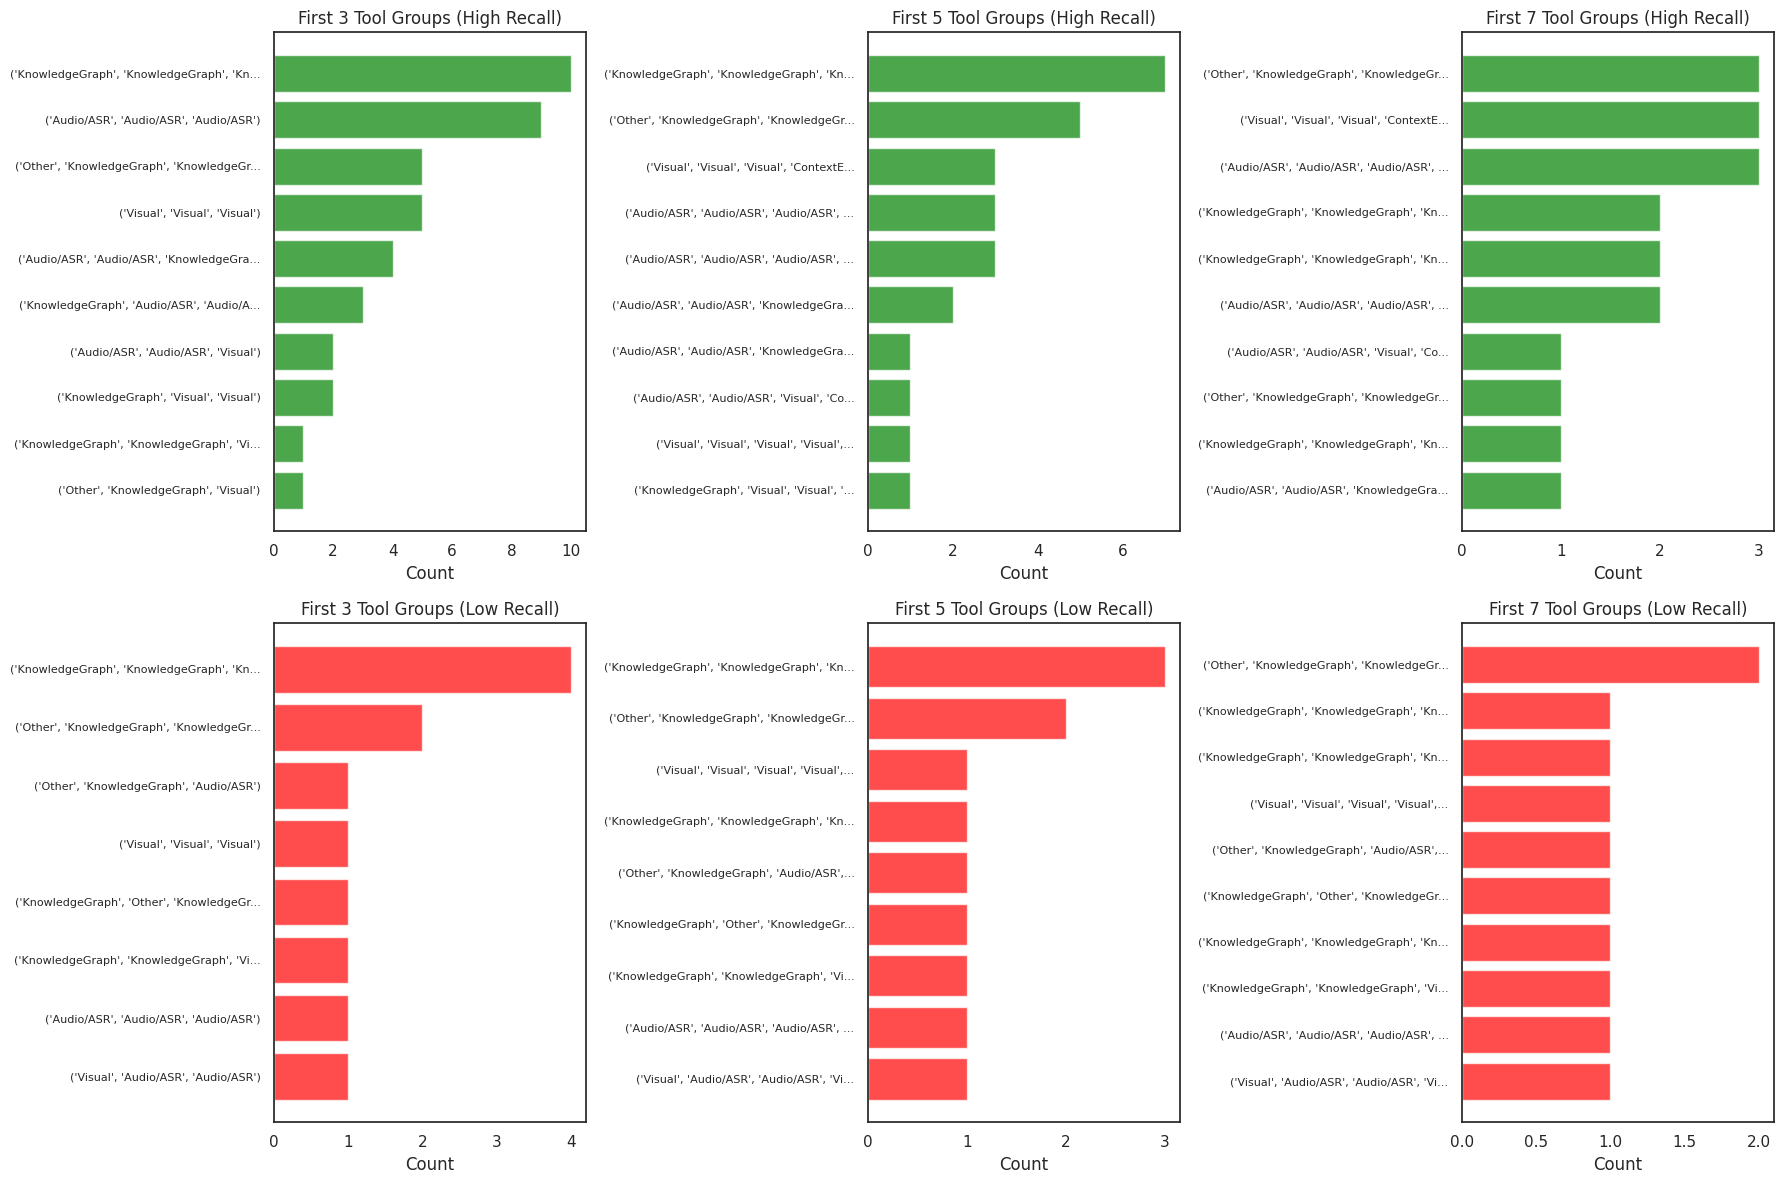

In [117]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, n in enumerate([3, 5, 7]):
    first_n_groups_high = trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['feedback_value_recall'] >= 0.7][f'first_{n}_groups'].dropna().value_counts().head(10)
    first_n_groups_low = trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['feedback_value_recall'] < 0.5][f'first_{n}_groups'].dropna().value_counts().head(10)
    
    axes[0, idx].barh(range(len(first_n_groups_high)), first_n_groups_high.values, color='green', alpha=0.7)
    axes[0, idx].set_yticks(range(len(first_n_groups_high)))
    axes[0, idx].set_yticklabels([str(seq)[:40] if len(str(seq)) <= 40 else str(seq)[:40] + '...' for seq in first_n_groups_high.index], fontsize=8)
    axes[0, idx].set_xlabel('Count')
    axes[0, idx].set_title(f'First {n} Tool Groups (High Recall)')
    axes[0, idx].invert_yaxis()
    
    axes[1, idx].barh(range(len(first_n_groups_low)), first_n_groups_low.values, color='red', alpha=0.7)
    axes[1, idx].set_yticks(range(len(first_n_groups_low)))
    axes[1, idx].set_yticklabels([str(seq)[:40] if len(str(seq)) <= 40 else str(seq)[:40] + '...' for seq in first_n_groups_low.index], fontsize=8)
    axes[1, idx].set_xlabel('Count')
    axes[1, idx].set_title(f'First {n} Tool Groups (Low Recall)')
    axes[1, idx].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Sequence Pattern Transition Analysis

In [118]:
from collections import Counter

def get_transitions(sequence):
    transitions = []
    for i in range(len(sequence) - 1):
        transitions.append((sequence[i], sequence[i+1]))
    return transitions

high_perf_traces = trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['feedback_value_recall'] >= 0.7]['trace_id']
low_perf_traces = trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['feedback_value_recall'] < 0.5]['trace_id']

high_transitions = Counter()
for seq in trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['trace_id'].isin(high_perf_traces)]['toolgroup_sequence']:
    for trans in get_transitions(seq):
        high_transitions[trans] += 1

low_transitions = Counter()
for seq in trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['trace_id'].isin(low_perf_traces)]['toolgroup_sequence']:
    for trans in get_transitions(seq):
        low_transitions[trans] += 1

high_top_transitions = high_transitions.most_common(15)
low_top_transitions = low_transitions.most_common(15)

print("Top 15 Tool Group Transitions in HIGH performance traces:")
for trans, count in high_top_transitions:
    print(f"  {trans[0]} -> {trans[1]}: {count} times")

print("\nTop 15 Tool Group Transitions in LOW performance traces:")
for trans, count in low_top_transitions:
    print(f"  {trans[0]} -> {trans[1]}: {count} times")

Top 15 Tool Group Transitions in HIGH performance traces:
  ContextExpansion -> ContextExpansion: 485 times
  KnowledgeGraph -> KnowledgeGraph: 235 times
  Visual -> Visual: 125 times
  Audio/ASR -> Audio/ASR: 91 times
  KnowledgeGraph -> ContextExpansion: 49 times
  Visual -> ContextExpansion: 41 times
  ContextExpansion -> KnowledgeGraph: 36 times
  Audio/ASR -> ContextExpansion: 32 times
  VideoMetadata -> VideoMetadata: 32 times
  KnowledgeGraph -> Other: 28 times
  Audio/ASR -> KnowledgeGraph: 27 times
  ContextExpansion -> Visual: 26 times
  ContextExpansion -> Audio/ASR: 26 times
  KnowledgeGraph -> Visual: 24 times
  Visual -> Audio/ASR: 19 times

Top 15 Tool Group Transitions in LOW performance traces:
  ContextExpansion -> ContextExpansion: 88 times
  KnowledgeGraph -> KnowledgeGraph: 58 times
  Visual -> Visual: 24 times
  Audio/ASR -> Audio/ASR: 14 times
  Visual -> ContextExpansion: 10 times
  KnowledgeGraph -> Visual: 9 times
  Audio/ASR -> Visual: 9 times
  Other -> Know

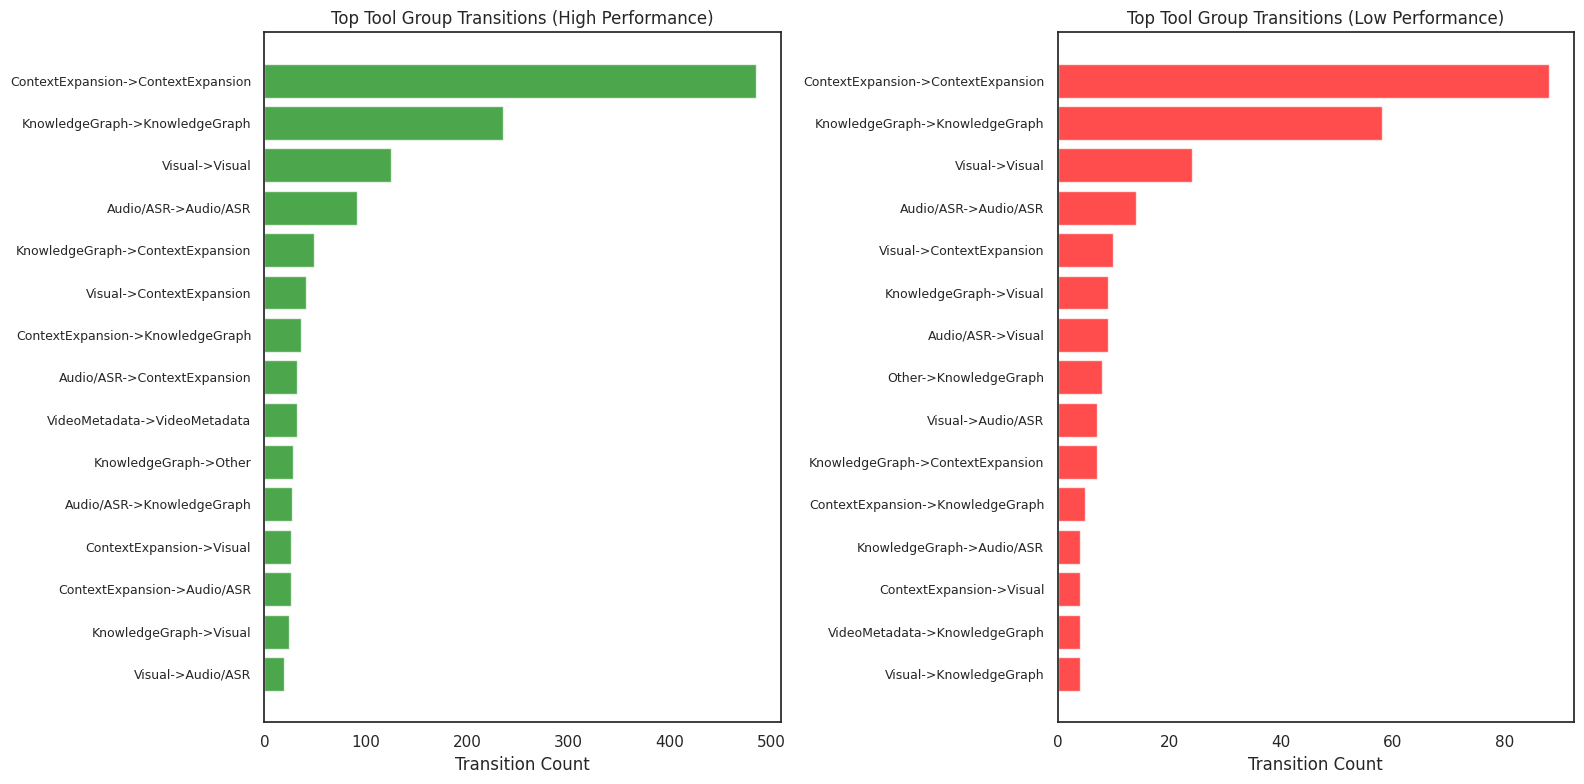

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

high_trans_labels = [f"{t[0]}->{t[1]}" for t, c in high_top_transitions]
high_trans_counts = [c for t, c in high_top_transitions]

axes[0].barh(range(len(high_trans_labels)), high_trans_counts, color='green', alpha=0.7)
axes[0].set_yticks(range(len(high_trans_labels)))
axes[0].set_yticklabels(high_trans_labels, fontsize=9)
axes[0].set_xlabel('Transition Count')
axes[0].set_title('Top Tool Group Transitions (High Performance)')
axes[0].invert_yaxis()

low_trans_labels = [f"{t[0]}->{t[1]}" for t, c in low_top_transitions]
low_trans_counts = [c for t, c in low_top_transitions]

axes[1].barh(range(len(low_trans_labels)), low_trans_counts, color='red', alpha=0.7)
axes[1].set_yticks(range(len(low_trans_labels)))
axes[1].set_yticklabels(low_trans_labels, fontsize=9)
axes[1].set_xlabel('Transition Count')
axes[1].set_title('Top Tool Group Transitions (Low Performance)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Sequence Heatmap: Tool Group Flow

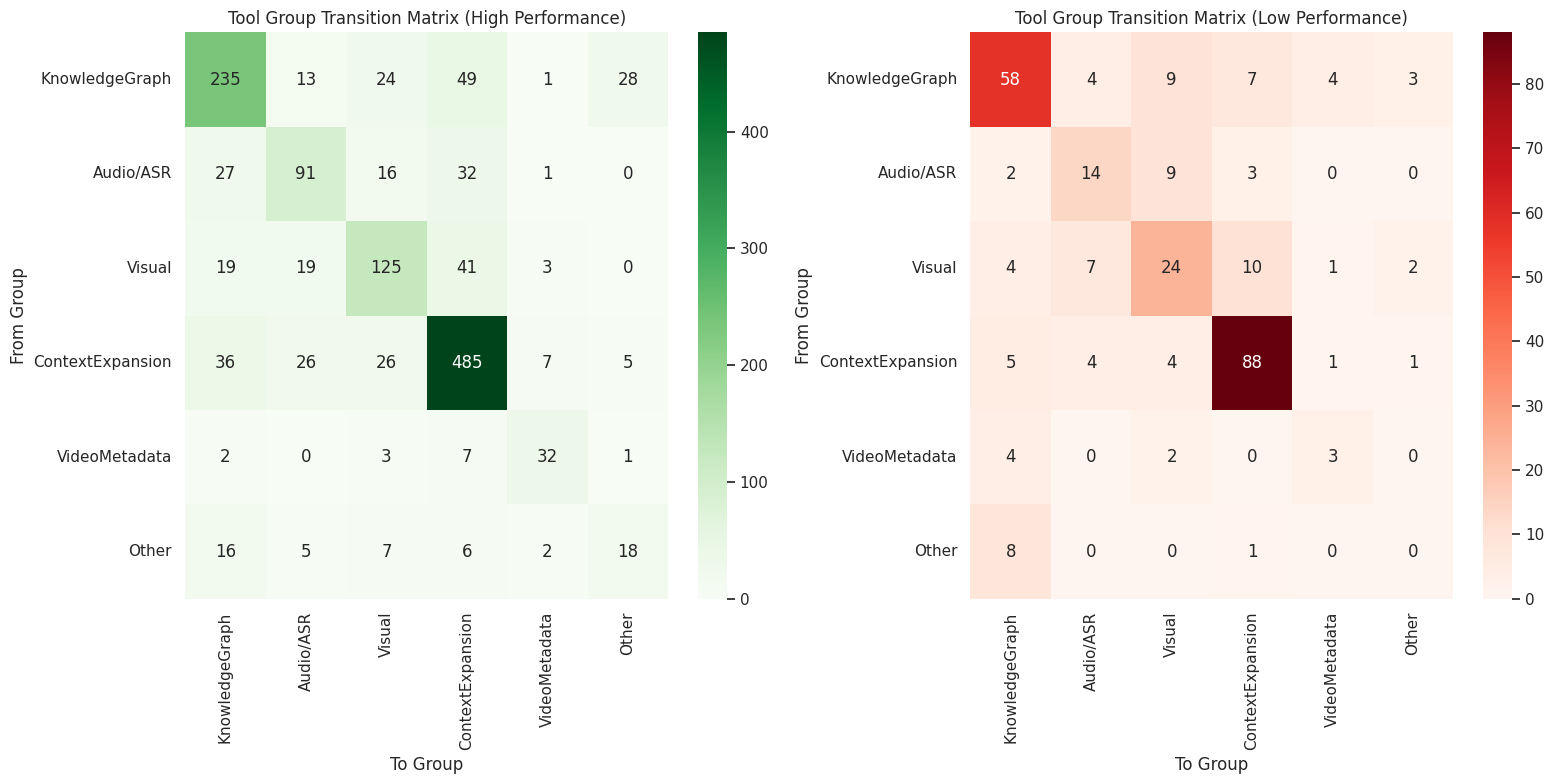

In [120]:
all_groups = ['KnowledgeGraph', 'Audio/ASR', 'Visual', 'ContextExpansion', 'VideoMetadata', 'Other']

transition_matrix_high = pd.DataFrame(0, index=all_groups, columns=all_groups)
for seq in trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['trace_id'].isin(high_perf_traces)]['toolgroup_sequence']:
    for trans in get_transitions(seq):
        if trans[0] in all_groups and trans[1] in all_groups:
            transition_matrix_high.loc[trans[0], trans[1]] += 1

transition_matrix_low = pd.DataFrame(0, index=all_groups, columns=all_groups)
for seq in trace_toolgroup_seq_scores[trace_toolgroup_seq_scores['trace_id'].isin(low_perf_traces)]['toolgroup_sequence']:
    for trans in get_transitions(seq):
        if trans[0] in all_groups and trans[1] in all_groups:
            transition_matrix_low.loc[trans[0], trans[1]] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(transition_matrix_high, annot=True, cmap='Greens', fmt='d', ax=axes[0])
axes[0].set_title('Tool Group Transition Matrix (High Performance)')
axes[0].set_xlabel('To Group')
axes[0].set_ylabel('From Group')

sns.heatmap(transition_matrix_low, annot=True, cmap='Reds', fmt='d', ax=axes[1])
axes[1].set_title('Tool Group Transition Matrix (Low Performance)')
axes[1].set_xlabel('To Group')
axes[1].set_ylabel('From Group')

plt.tight_layout()
plt.show()

## 11. Transition Ratio: High vs Low Performance

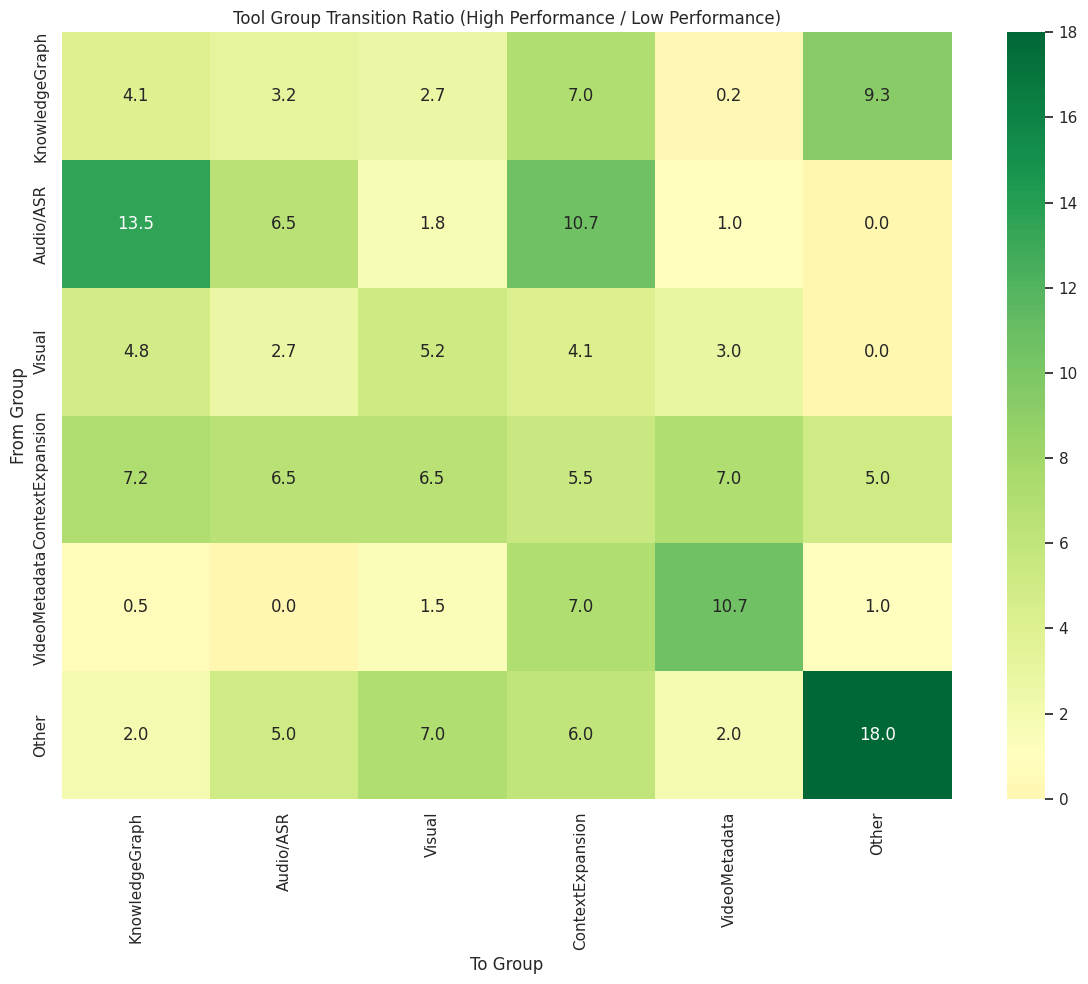

Interpretation: Values > 1 indicate transitions more common in high-performance traces


In [121]:
transition_ratio = transition_matrix_high / transition_matrix_low.replace(0, 1)

plt.figure(figsize=(12, 10))
sns.heatmap(transition_ratio, annot=True, cmap='RdYlGn', center=1, fmt='.1f')
plt.title('Tool Group Transition Ratio (High Performance / Low Performance)')
plt.xlabel('To Group')
plt.ylabel('From Group')
plt.tight_layout()
plt.show()

print("Interpretation: Values > 1 indicate transitions more common in high-performance traces")

## 12. Sequence Pattern Diversity vs Performance

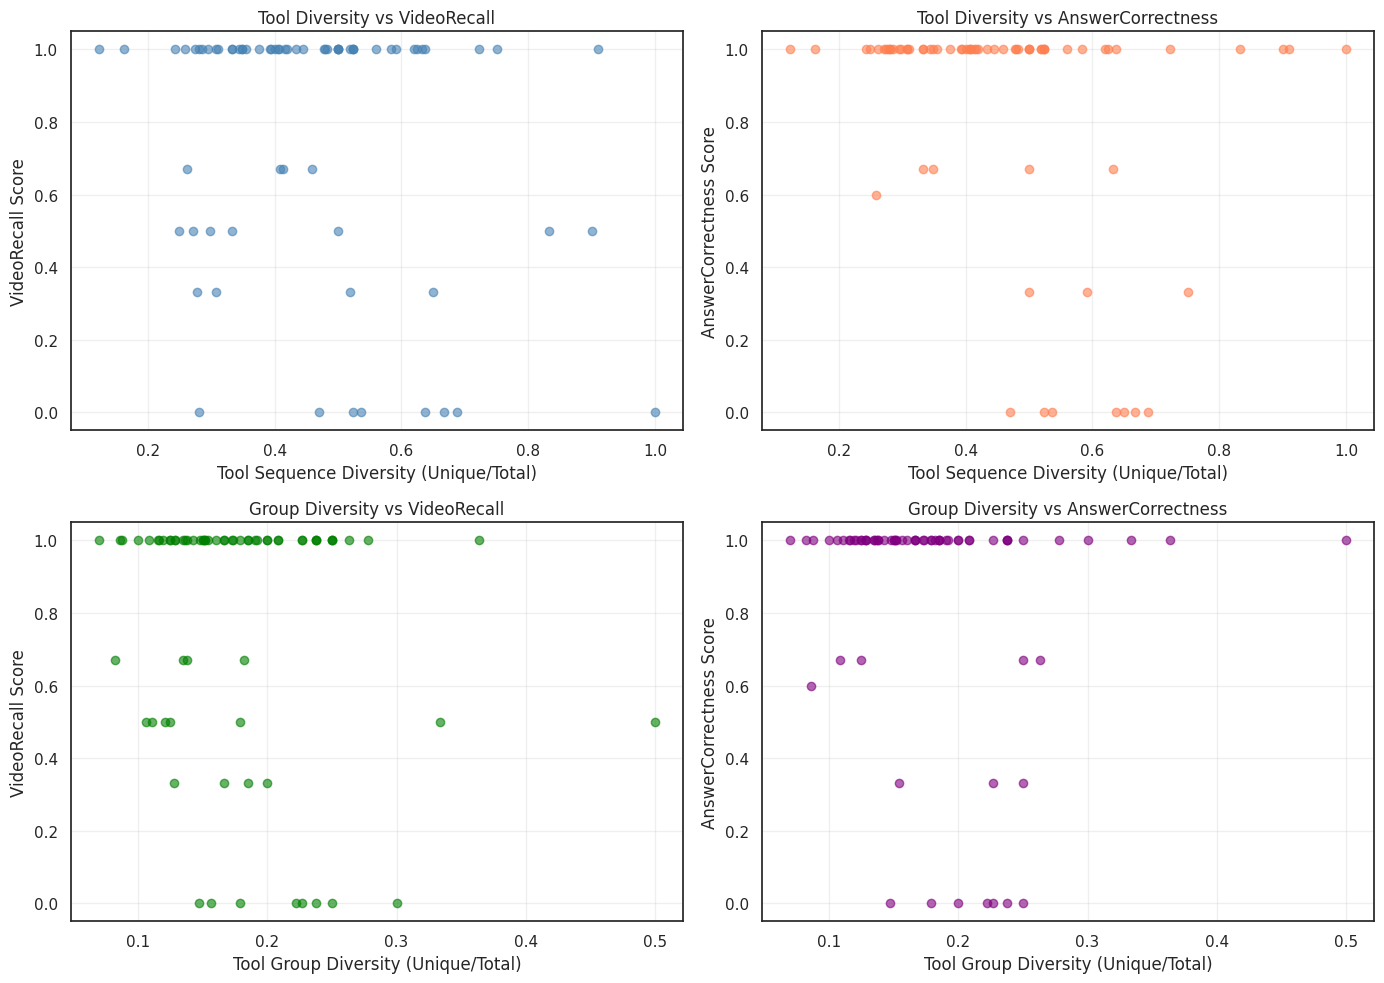

In [122]:
trace_tool_seq_scores['sequence_diversity'] = trace_tool_seq_scores['unique_tools'] / trace_tool_seq_scores['sequence_length']
trace_toolgroup_seq_scores['group_diversity'] = trace_toolgroup_seq_scores['unique_groups'] / trace_toolgroup_seq_scores['group_sequence_length']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(trace_tool_seq_scores['sequence_diversity'], trace_tool_seq_scores['feedback_value_recall'], alpha=0.6, c='steelblue')
axes[0, 0].set_xlabel('Tool Sequence Diversity (Unique/Total)')
axes[0, 0].set_ylabel('VideoRecall Score')
axes[0, 0].set_title('Tool Diversity vs VideoRecall')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(trace_tool_seq_scores['sequence_diversity'], trace_tool_seq_scores['feedback_value_answer'], alpha=0.6, c='coral')
axes[0, 1].set_xlabel('Tool Sequence Diversity (Unique/Total)')
axes[0, 1].set_ylabel('AnswerCorrectness Score')
axes[0, 1].set_title('Tool Diversity vs AnswerCorrectness')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(trace_toolgroup_seq_scores['group_diversity'], trace_toolgroup_seq_scores['feedback_value_recall'], alpha=0.6, c='green')
axes[1, 0].set_xlabel('Tool Group Diversity (Unique/Total)')
axes[1, 0].set_ylabel('VideoRecall Score')
axes[1, 0].set_title('Group Diversity vs VideoRecall')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(trace_toolgroup_seq_scores['group_diversity'], trace_toolgroup_seq_scores['feedback_value_answer'], alpha=0.6, c='purple')
axes[1, 1].set_xlabel('Tool Group Diversity (Unique/Total)')
axes[1, 1].set_ylabel('AnswerCorrectness Score')
axes[1, 1].set_title('Group Diversity vs AnswerCorrectness')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Result.json Analysis Section

In [123]:
from pathlib import Path
# Load result.json
result_file = Path('prompts/result.json')
with open(result_file, "r", encoding="utf-8") as f:
    result_data = json.load(f)
print(f"Loaded {len(result_data)} trace evaluations")

Loaded 70 trace evaluations


In [124]:
# Convert to DataFrame
records = []
for item in result_data:
    trace_id = item.get("trace_id", "")
    answer_found = item.get("answer_found", {})
    step_index = answer_found.get("step_index", -1)
    worker = answer_found.get("worker", "Unknown")
    tools = answer_found.get("tools_involved", [])
    tool_names = [t.get("tool", "") for t in tools]
    records.append({
        "trace_id": trace_id,
        "step_index": step_index,
        "worker": worker,
        "found": step_index >= 0,
        "num_tools": len(tools),
        "tools": tool_names,
    })

df_result = pd.DataFrame(records)
df_found = df_result[df_result["found"] == True]
df_failed = df_result[df_result["found"] == False]
print(f"Found: {len(df_found)} | Failed: {len(df_failed)}")

Found: 61 | Failed: 9


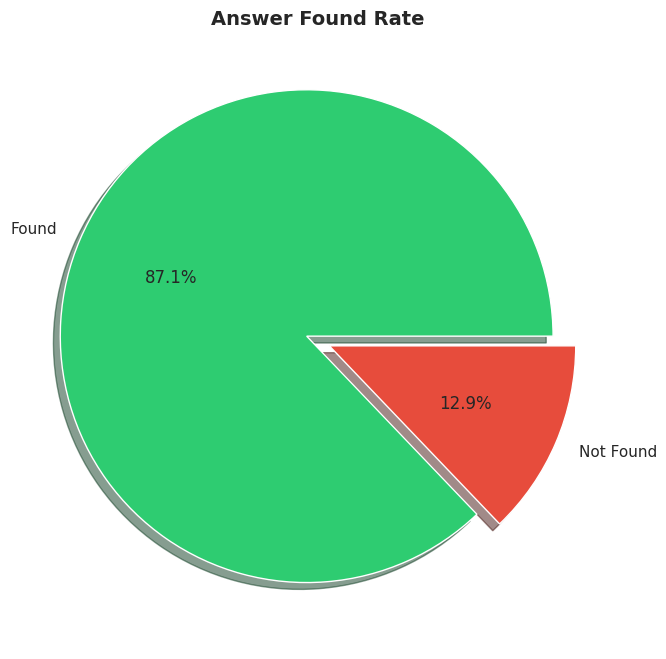

In [125]:
# Success Rate Pie Chart
fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#2ecc71", "#e74c3c"]
ax.pie([len(df_found), len(df_failed)],
        labels=["Found", "Not Found"],
        autopct="%1.1f%%",
        colors=colors,
        explode=(0.05, 0.05),
        shadow=True)
ax.set_title("Answer Found Rate", fontsize=14, fontweight="bold")
plt.show()

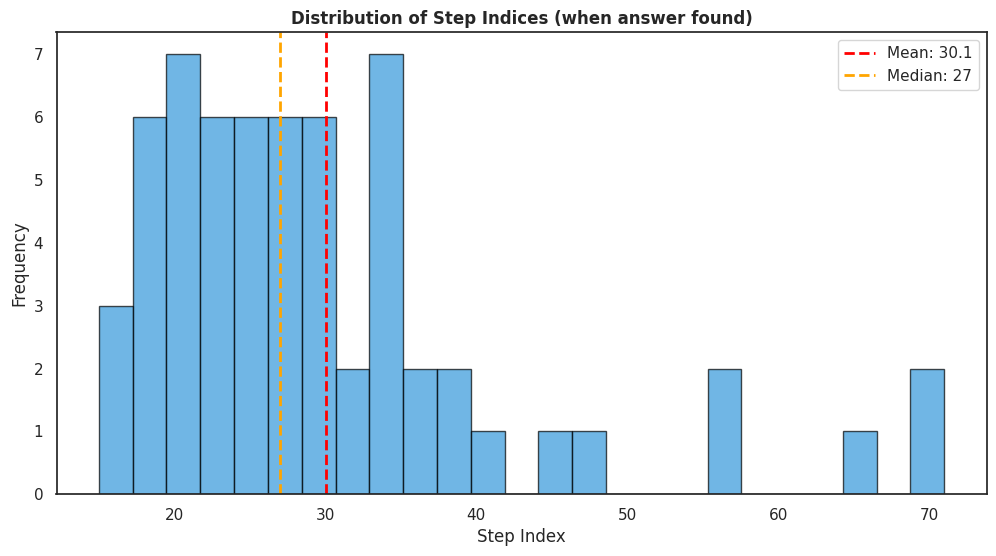

In [126]:
# Step Index Distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df_found["step_index"], bins=25, color="#3498db", edgecolor="black", alpha=0.7)
ax.axvline(df_found["step_index"].mean(), color="red", linestyle="--", linewidth=2,
          label=f"Mean: {df_found["step_index"].mean():.1f}")
ax.axvline(df_found["step_index"].median(), color="orange", linestyle="--", linewidth=2,
          label=f"Median: {df_found["step_index"].median():.0f}")
ax.set_xlabel("Step Index")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Step Indices (when answer found)", fontweight="bold")
ax.legend()
plt.show()

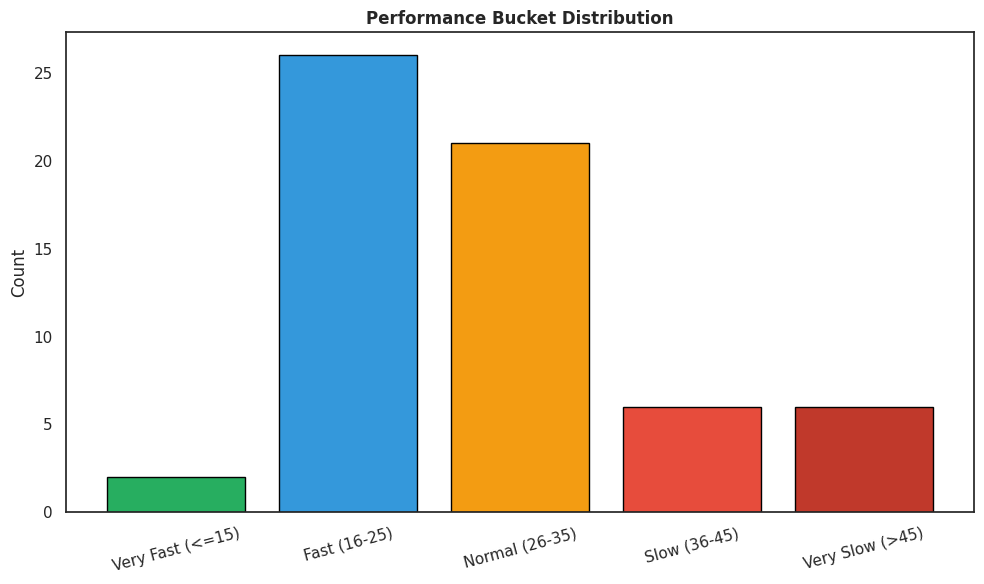

In [127]:
# Performance Buckets
buckets = {
    "Very Fast (<=15)": len([s for s in df_found["step_index"] if s <= 15]),
    "Fast (16-25)": len([s for s in df_found["step_index"] if 16 <= s <= 25]),
    "Normal (26-35)": len([s for s in df_found["step_index"] if 26 <= s <= 35]),
    "Slow (36-45)": len([s for s in df_found["step_index"] if 36 <= s <= 45]),
    "Very Slow (>45)": len([s for s in df_found["step_index"] if s > 45]),
}

fig, ax = plt.subplots(figsize=(10, 6))
bucket_colors = ["#27ae60", "#3498db", "#f39c12", "#e74c3c", "#c0392b"]
ax.bar(buckets.keys(), buckets.values(), color=bucket_colors, edgecolor="black")
ax.set_ylabel("Count")
ax.set_title("Performance Bucket Distribution", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Efficiency: Step Found vs Total Steps

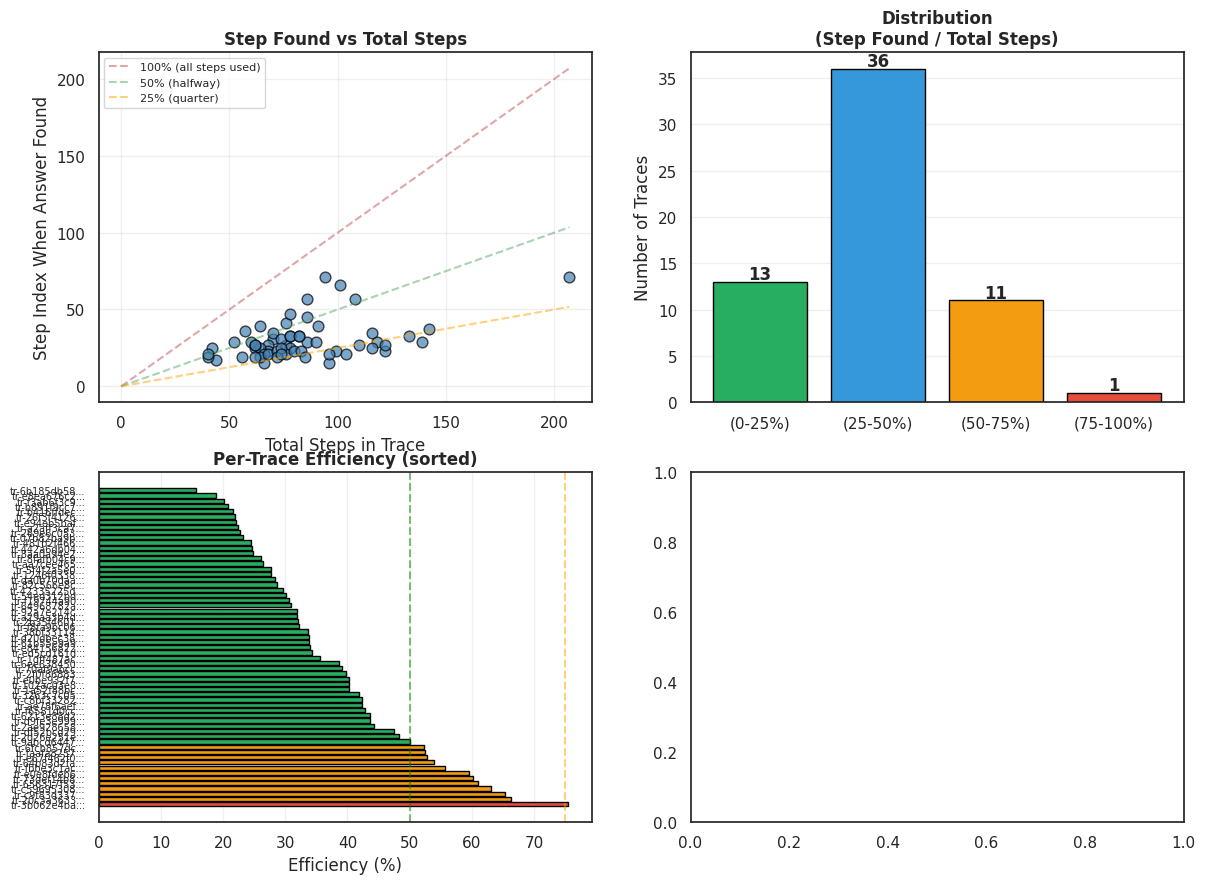

In [134]:
# Efficiency Comparison: Step Found vs Total Steps
df_trace_general_subset = df_trace_general[['trace_id', 'total_spans']].copy()
df_result_merged = df_result.merge(df_trace_general_subset, on='trace_id', how='left')
df_result_merged = df_result_merged.dropna(subset=['total_spans'])
df_result_merged['efficiency'] = df_result_merged['step_index'] / df_result_merged['total_spans']
df_found_merged = df_result_merged[df_result_merged['found'] == True]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter: Step Found vs Total Spans
axes[0, 0].scatter(df_found_merged['total_spans'], df_found_merged['step_index'], 
                   alpha=0.7, c='steelblue', edgecolors='black', s=60)
axes[0, 0].plot([0, df_found_merged['total_spans'].max()], [0, df_found_merged['total_spans'].max()], 
                'r--', alpha=0.5, label='100% (all steps used)')
axes[0, 0].plot([0, df_found_merged['total_spans'].max()], 
                [0, df_found_merged['total_spans'].max() * 0.5], 
                'g--', alpha=0.5, label='50% (halfway)')
axes[0, 0].plot([0, df_found_merged['total_spans'].max()], 
                [0, df_found_merged['total_spans'].max() * 0.25], 
                'orange', linestyle='--', alpha=0.5, label='25% (quarter)')
axes[0, 0].set_xlabel('Total Steps in Trace')
axes[0, 0].set_ylabel('Step Index When Answer Found')
axes[0, 0].set_title('Step Found vs Total Steps', fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2. Efficiency Distribution
eff_bins = [0, 0.25, 0.5, 0.75, 1.0]
eff_labels = ['(0-25%)', '(25-50%)', '(50-75%)', '(75-100%)']
eff_colors = ['#27ae60', '#3498db', '#f39c12', '#e74c3c']
eff_counts = pd.cut(df_found_merged['efficiency'], bins=eff_bins, labels=eff_labels).value_counts().sort_index()
axes[0, 1].bar(eff_counts.index, eff_counts.values, color=eff_colors, edgecolor='black')
for i, (label, count) in enumerate(eff_counts.items()):
    axes[0, 1].text(i, count + 0.3, str(count), ha='center', fontweight='bold')
axes[0, 1].set_ylabel('Number of Traces')
axes[0, 1].set_title('Distribution\n(Step Found / Total Steps)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Horizontal bar: per-trace efficiency (sorted)
df_sorted = df_found_merged.sort_values('efficiency', ascending=True).reset_index(drop=True)
colors_eff = ['#27ae60' if e <= 0.5 else '#f39c12' if e <= 0.75 else '#e74c3c' for e in df_sorted['efficiency']]
axes[1, 0].barh(range(len(df_sorted)), df_sorted['efficiency'] * 100, color=colors_eff, edgecolor='black', height=0.8)
axes[1, 0].set_yticks(range(len(df_sorted)))
axes[1, 0].set_yticklabels([f"{tid[:12]}..." for tid in df_sorted['trace_id']], fontsize=7)
axes[1, 0].set_xlabel('Efficiency (%)')
axes[1, 0].set_title('Per-Trace Efficiency (sorted)', fontweight='bold')
axes[1, 0].axvline(x=50, color='green', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=75, color='orange', linestyle='--', alpha=0.5)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')



In [133]:
df_result_merged

,trace_id,step_index,worker,found,num_tools,tools,total_spans,efficiency
0,tr-1a52f88bcda4e49aaa5b90ff458a9893,25,Worker 1,True,4,"[triple_hybrid_search, search_events, search_m...",62,0.403226
1,tr-1dff487ac1ca0134ac4624a03ce1f557,27,Worker 1,True,2,"[search_micro_events, search_events]",76,0.355263
2,tr-01ee9f794325242fd70297e4d8ee62f1,-1,Worker 1,False,0,[],76,-0.013158
3,tr-2ae928658a9074b82f2532b7713a52f5,31,asr_caption_search_worker,True,3,"[get_related_asr_from_segment, get_adjacent_se...",70,0.442857
4,tr-2b35f46018dd98383e97c207cea057a2,25,video_discovery_worker,True,1,[get_video_timeline],78,0.320513
...,...,...,...,...,...,...,...,...
65,tr-f19744a9006b6d26072fb16694ba11ac,19,Worker 1,True,1,[search_events],62,0.306452
66,tr-f922167665cc80d15f23616ce5cdf0ce,-1,none,False,0,[],151,-0.006623
67,tr-faafa8257b2d8421ab3e975b4889c6b0,21,kg_wind_abrasion_searcher,True,2,"[search_micro_events, search_events]",40,0.525000
68,tr-fb098563959006f01342ae2442f3a641,-1,transcript_search_worker,False,0,[],68,-0.014706
